# Extended 2023–2026 Underlying-Market Robustness Pipeline

I repeat the underlying retrieval, alignment, cleaning, modelling and robustness workflow on an isolated 2023-2026 dataset.

In this notebook, I combine the dissertation's existing **Massive retrieval, look-ahead-safe alignment, EDA, cleaning, strict/relaxed dataset construction, baseline modelling, hyperparameter tuning and robustness analysis** into one reproducible workflow for a longer underlying-market sample.

## Purpose

My objective is **not to replace the original RQ1–RQ5 results or optimise a new trading strategy after seeing the earlier outcomes**. Instead, I ask whether the conclusions for RQ1–RQ4 remain broadly stable when more underlying-market history is available.

## Protected date design

- Extended historical start: **2023-01-01**
- Extended development/robustness end: **2026-07-17**
- Data after 2026-07-17 are **not downloaded into this database**.
- The existing post-17-Jul-2026 fresh holdout remains separate and untouched.

## Isolation from the original project data

I write only to:

- `data_extended_2023_2026/`
- `outputs/extended_2023_2026/`

It does **not** overwrite the original `data/` or `outputs/` folders.

## Methodological continuity

I base the processing and modelling code below on the earlier notebooks in this project:

- `02_massive_database_raw_retrieve.ipynb`
- `03_aligned_eda.ipynb`
- `04_cleaning_modellingprep.ipynb`
- `05_dataset_Splitting.ipynb`
- `06_modeling_baseline.ipynb`
- `08_hyperparameters_tuning_extended_robustness.ipynb`

The existing 14:59 completed-bar feature convention, 15:59 target, backward as-of alignment, strict/relaxed session rules, feature definitions and expanding-window modelling approach are retained.

In [ ]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


## 0. Retrieval configuration and project setup

In [2]:
# I use this cell for retrieval configuration and project setup.
from pathlib import Path
from datetime import date, timedelta
import os
import sys
import json

import pandas as pd
from dotenv import load_dotenv, dotenv_values

PROJECT_ROOT = Path.cwd().resolve()
ENV_PATH = PROJECT_ROOT / "main.env"
SRC_ROOT = PROJECT_ROOT / "scripts"

EXTENDED_START_DATE = "2023-01-01"
EXTENDED_END_DATE = "2026-07-17"  # Protect the fresh post-17-Jul-2026 holdout.

DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DB_PATH = DATA_ROOT / "market.duckdb"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not ENV_PATH.exists():
    raise FileNotFoundError(f"Missing environment file: {ENV_PATH}")
if not SRC_ROOT.exists():
    raise FileNotFoundError(
        "Missing scripts directory. This workflow expects the same scripts/massive_database.py "
        "used by your original retrieval notebook."
    )

load_dotenv(ENV_PATH, override=True)
API_KEY = os.getenv("MASSIVE_API_KEY")
if not API_KEY:
    raise RuntimeError("MASSIVE_API_KEY is missing from main.env/environment.")

sys.path.insert(0, str(SRC_ROOT))

from massive_database import (
    MassiveREST,
    download_aggregate_history,
    initialize_duckdb,
)

client = MassiveREST(API_KEY)
con = initialize_duckdb(DB_PATH)

print("Project root:", PROJECT_ROOT)
print("Extended data root:", DATA_ROOT)
print("Extended database:", DB_PATH)
print("Extended output root:", OUTPUT_ROOT)
print("Requested range:", EXTENDED_START_DATE, "to", EXTENDED_END_DATE)
print("Fresh post-17-Jul-2026 holdout is excluded by construction.")

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Extended data root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026
Extended database: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\market.duckdb
Extended output root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026
Requested range: 2023-01-01 to 2026-07-17
Fresh post-17-Jul-2026 holdout is excluded by construction.


## 1. Check current access before the historical download

In [3]:
# I use this cell for check current access before the historical download.
def recent_data_sample(ticker: str, asset_class: str, lookback_days: int = 14):
    today = date.today()
    for days_back in range(1, lookback_days + 1):
        candidate = (today - timedelta(days=days_back)).isoformat()
        try:
            raw = client.aggregates(ticker, candidate, candidate)
            if raw:
                return candidate, normalize_aggregates(raw, ticker, asset_class)
        except Exception as exc:
            return None, pd.DataFrame({"ticker": [ticker], "error": [str(exc)]})
    return None, pd.DataFrame()

checks, samples = [], {}
for ticker, asset_class in [("SPY", "stock"), ("I:SPX", "index"), ("I:VIX", "index")]:
    sample_date, frame = recent_data_sample(ticker, asset_class)
    samples[ticker] = frame
    checks.append({
        "ticker": ticker,
        "asset_class": asset_class,
        "sample_date": sample_date,
        "rows": len(frame),
        "status": "ok" if sample_date else "no data or no access",
    })

access_report = pd.DataFrame(checks)
display(access_report)

,ticker,asset_class,sample_date,rows,status
0,SPY,stock,None,1,no data or no access
1,I:SPX,index,None,1,no data or no access
2,I:VIX,index,None,1,no data or no access


## 2. Download SPY, SPX and VIX minute aggregates for 2023–17 Jul 2026

In [4]:
# I use this cell for download spy, spx and vix minute aggregates for 2023–17 jul 2026.
RUN_EXTENDED_DOWNLOAD = True

UNDERLYINGS = [
    ("SPY", "stock"),
    ("I:SPX", "index"),
    ("I:VIX", "index"),
]

if RUN_EXTENDED_DOWNLOAD:
    summaries = []

    for ticker, asset_class in UNDERLYINGS:
        print(f"Downloading {ticker}: {EXTENDED_START_DATE} -> {EXTENDED_END_DATE}")

        results = download_aggregate_history(
            client=client,
            con=con,
            data_root=DATA_ROOT,
            ticker=ticker,
            asset_class=asset_class,
            start_date=EXTENDED_START_DATE,
            end_date=EXTENDED_END_DATE,
        )

        summaries.extend(r.__dict__ for r in results)

    download_summary = pd.DataFrame(summaries)
    display(
        download_summary.groupby(["ticker", "status"]).size().unstack(fill_value=0)
    )

    summary_path = OUTPUT_ROOT / "extended_download_summary.csv"
    download_summary.to_csv(summary_path, index=False)
    print("Saved:", summary_path)
else:
    print("Download disabled. Set RUN_EXTENDED_DOWNLOAD=True when ready.")

status,empty,ok
ticker,,
I:SPX,67,858
I:VIX,41,884
SPY,38,887


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\extended_download_summary.csv


## 3. Register corrected Parquet views in the extended DuckDB database

In [5]:
# I use this cell for register corrected parquet views in the extended duckdb database.
def register_parquet_views_fixed(con, data_root):
    from pathlib import Path

    data_root = Path(data_root)
    created = []

    datasets = [
        "stock_minute_1",
        "index_minute_1",
        "option_minute_1",
        "option_chain_snapshots",
        "option_contracts",
    ]

    for name in datasets:
        base = data_root / "raw" / name

        if base.exists() and any(base.rglob("*.parquet")):
            parquet_glob = str(base / "**" / "*.parquet").replace("\\", "/")

            con.execute(
                f"""
                CREATE OR REPLACE VIEW {name} AS
                SELECT *
                FROM read_parquet(
                    '{parquet_glob}',
                    union_by_name = true,
                    hive_partitioning = false
                )
                """
            )

            created.append(name)

    available_underlyings = [
        name
        for name in ["stock_minute_1", "index_minute_1"]
        if name in created
    ]

    if available_underlyings:
        union_query = " UNION ALL ".join(
            f"SELECT * FROM {name}"
            for name in available_underlyings
        )

        con.execute(
            f"""
            CREATE OR REPLACE VIEW underlying_minute_1 AS
            {union_query}
            """
        )

        con.execute(
            """
            CREATE OR REPLACE VIEW underlying_regular_session AS
            SELECT *
            FROM underlying_minute_1
            WHERE CAST(timestamp_et AS TIME) >= TIME '09:30:00'
              AND CAST(timestamp_et AS TIME) < TIME '16:00:00'
            """
        )

        con.execute(
            """
            CREATE OR REPLACE VIEW underlying_15min AS
            SELECT
                ticker,
                asset_class,
                time_bucket(
                    INTERVAL '15 minutes',
                    timestamp_utc
                ) AS timestamp_utc,

                min(timestamp_et) AS timestamp_et,
                min(session_date) AS session_date,

                arg_min(open, timestamp_utc) AS open,
                max(high) AS high,
                min(low) AS low,
                arg_max(close, timestamp_utc) AS close,

                sum(volume) AS volume,

                CASE
                    WHEN sum(volume) > 0
                    THEN
                        sum(coalesce(vwap, close) * volume)
                        / sum(volume)
                    ELSE avg(coalesce(vwap, close))
                END AS vwap,

                sum(transactions) AS transactions

            FROM underlying_regular_session

            GROUP BY
                ticker,
                asset_class,
                time_bucket(
                    INTERVAL '15 minutes',
                    timestamp_utc
                )

            ORDER BY
                ticker,
                timestamp_utc
            """
        )

    return created

In [6]:
# I use this cell for register corrected parquet views in the extended duckdb database.
created_views = register_parquet_views_fixed(con, DATA_ROOT)
print("Created views:", created_views)

coverage = con.execute(
    """
    SELECT
        ticker,
        COUNT(*) AS minute_bars,
        COUNT(DISTINCT session_date) AS sessions,
        MIN(timestamp_et) AS first_timestamp,
        MAX(timestamp_et) AS last_timestamp
    FROM underlying_regular_session
    GROUP BY ticker
    ORDER BY ticker
    """
).df()

display(coverage)
coverage.to_csv(OUTPUT_ROOT / "extended_raw_coverage.csv", index=False)

Created views: ['stock_minute_1', 'index_minute_1']


,ticker,minute_bars,sessions,first_timestamp,last_timestamp
0,I:SPX,332623,858,2023-02-14 13:22:00,2026-07-17 15:59:00
1,I:VIX,315047,883,2023-02-14 13:22:00,2026-07-17 15:59:00
2,SPY,344494,887,2023-01-03 09:30:00,2026-07-17 15:59:00


---
# Part I — Alignment, feature engineering and EDA

The following section preserves the logic of `03_aligned_eda.ipynb`. SPY remains the master minute clock, while SPX and VIX are matched backward only, with a maximum two-minute tolerance. Features use completed information before 15:00 ET and the target runs to the final completed 15:59 bar.

## 1. Environment and database connection

I locate `data_extended_2023_2026/market.duckdb` by searching the current folder and its parents.

If an import fails, run:

```python
%pip install duckdb pandas pyarrow matplotlib
```

In [7]:
# I use this cell for environment and database connection.
from pathlib import Path
from datetime import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    """Find the nearest folder containing data_extended_2023_2026/market.duckdb."""
    start = start.resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data_extended_2023_2026" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data_extended_2023_2026/market.duckdb. "
        "Place this notebook in the Massive database project folder."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"
FIGURE_ROOT = OUTPUT_ROOT / "eda_figures"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Derived data:", DERIVED_ROOT)
print("EDA figures:", FIGURE_ROOT)


def save_figure(fig, filename: str) -> Path:
    """Save a high-resolution PNG and return its path."""
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Database: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\market.duckdb
Derived data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived
EDA figures: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures


## 2. Validate the database and identify ticker names

The corrected views should contain `SPY`, `I:SPX` and `I:VIX`. I also accept the fallback aliases `I_SPX` and `I_VIX` so I can diagnose an older view definition.

In [8]:
# I use this cell for validate the database and identify ticker names.
available_relations = con.execute(
    """
    SELECT table_name, table_type
    FROM information_schema.tables
    ORDER BY table_name
    """
).df()

required_relation = "underlying_regular_session"

if required_relation not in set(available_relations["table_name"]):
    raise RuntimeError(
        "The view underlying_regular_session was not found. "
        "Run the corrected view-registration cell in the first notebook."
    )

ticker_coverage = con.execute(
    """
    SELECT
        ticker,
        COUNT(*) AS minute_bars,
        MIN(timestamp_et) AS first_timestamp,
        MAX(timestamp_et) AS last_timestamp,
        COUNT(DISTINCT session_date) AS sessions
    FROM underlying_regular_session
    GROUP BY ticker
    ORDER BY ticker
    """
).df()

display(ticker_coverage)

available_tickers = set(ticker_coverage["ticker"].astype(str))

SPY_TICKER = "SPY"
SPX_TICKER = "I:SPX" if "I:SPX" in available_tickers else "I_SPX"
VIX_TICKER = "I:VIX" if "I:VIX" in available_tickers else "I_VIX"

required_tickers = {SPY_TICKER, SPX_TICKER, VIX_TICKER}
missing_tickers = required_tickers.difference(available_tickers)

if missing_tickers:
    raise RuntimeError(
        f"Missing required tickers: {sorted(missing_tickers)}. "
        f"Available tickers: {sorted(available_tickers)}"
    )

print("Selected ticker mapping:")
print({"SPY": SPY_TICKER, "SPX": SPX_TICKER, "VIX": VIX_TICKER})

,ticker,minute_bars,first_timestamp,last_timestamp,sessions
0,I:SPX,332623,2023-02-14 13:22:00,2026-07-17 15:59:00,858
1,I:VIX,315047,2023-02-14 13:22:00,2026-07-17 15:59:00,883
2,SPY,344494,2023-01-03 09:30:00,2026-07-17 15:59:00,887


Selected ticker mapping:
{'SPY': 'SPY', 'SPX': 'I:SPX', 'VIX': 'I:VIX'}


## 3. Load the regular-session data

SPY supplies the canonical minute clock. Duplicate timestamps are reported and removed before alignment.

In [9]:
# I use this cell for load the regular-session data.
spy = con.execute(
    """
    SELECT
        timestamp_utc,
        timestamp_et,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS spy_open,
        high AS spy_high,
        low AS spy_low,
        close AS spy_close,
        volume AS spy_volume,
        vwap AS spy_vwap,
        transactions AS spy_transactions
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [SPY_TICKER],
).df()

spx = con.execute(
    """
    SELECT
        timestamp_utc AS spx_timestamp_utc,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS spx_open,
        high AS spx_high,
        low AS spx_low,
        close AS spx_close
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [SPX_TICKER],
).df()

vix = con.execute(
    """
    SELECT
        timestamp_utc AS vix_timestamp_utc,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS vix_open,
        high AS vix_high,
        low AS vix_low,
        close AS vix_close
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [VIX_TICKER],
).df()

spy["timestamp_utc"] = pd.to_datetime(spy["timestamp_utc"], utc=True)
spy["timestamp_et"] = pd.to_datetime(spy["timestamp_et"])

spx["spx_timestamp_utc"] = pd.to_datetime(spx["spx_timestamp_utc"], utc=True)
vix["vix_timestamp_utc"] = pd.to_datetime(vix["vix_timestamp_utc"], utc=True)

duplicate_report = pd.DataFrame(
    {
        "dataset": ["SPY", "SPX", "VIX"],
        "duplicate_timestamps": [
            spy.duplicated(["timestamp_utc"]).sum(),
            spx.duplicated(["spx_timestamp_utc"]).sum(),
            vix.duplicated(["vix_timestamp_utc"]).sum(),
        ],
        "rows_before_deduplication": [len(spy), len(spx), len(vix)],
    }
)

display(duplicate_report)

spy = (
    spy.drop_duplicates(["timestamp_utc"], keep="last")
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

spx = (
    spx.drop_duplicates(["spx_timestamp_utc"], keep="last")
    .sort_values("spx_timestamp_utc")
    .reset_index(drop=True)
)

vix = (
    vix.drop_duplicates(["vix_timestamp_utc"], keep="last")
    .sort_values("vix_timestamp_utc")
    .reset_index(drop=True)
)

print("Rows after deduplication:")
print({"SPY": len(spy), "SPX": len(spx), "VIX": len(vix)})

,dataset,duplicate_timestamps,rows_before_deduplication
0,SPY,0,344494
1,SPX,0,332623
2,VIX,0,315047


Rows after deduplication:
{'SPY': 344494, 'SPX': 332623, 'VIX': 315047}


## 4. Perform backward as-of alignment

A two-minute tolerance prevents stale values from being carried forward indefinitely. Unmatched observations remain missing and are included in the quality audit.

In [10]:
# I use this cell for perform backward as-of alignment.
MATCH_TOLERANCE = pd.Timedelta("2 minutes")

aligned = pd.merge_asof(
    left=spy.sort_values("timestamp_utc"),
    right=spx.sort_values("spx_timestamp_utc"),
    left_on="timestamp_utc",
    right_on="spx_timestamp_utc",
    by="session_date",
    direction="backward",
    tolerance=MATCH_TOLERANCE,
)

aligned = pd.merge_asof(
    left=aligned.sort_values("timestamp_utc"),
    right=vix.sort_values("vix_timestamp_utc"),
    left_on="timestamp_utc",
    right_on="vix_timestamp_utc",
    by="session_date",
    direction="backward",
    tolerance=MATCH_TOLERANCE,
)

aligned["spx_staleness_seconds"] = (
    aligned["timestamp_utc"] - aligned["spx_timestamp_utc"]
).dt.total_seconds()

aligned["vix_staleness_seconds"] = (
    aligned["timestamp_utc"] - aligned["vix_timestamp_utc"]
).dt.total_seconds()

aligned["clock_minute"] = (
    aligned["timestamp_et"].dt.hour * 60
    + aligned["timestamp_et"].dt.minute
)

future_spx_matches = (
    aligned["spx_timestamp_utc"].notna()
    & (aligned["spx_timestamp_utc"] > aligned["timestamp_utc"])
).sum()

future_vix_matches = (
    aligned["vix_timestamp_utc"].notna()
    & (aligned["vix_timestamp_utc"] > aligned["timestamp_utc"])
).sum()

alignment_summary = pd.DataFrame(
    {
        "metric": [
            "aligned rows",
            "missing SPX matches",
            "missing VIX matches",
            "future SPX matches",
            "future VIX matches",
            "maximum SPX staleness (seconds)",
            "maximum VIX staleness (seconds)",
        ],
        "value": [
            len(aligned),
            aligned["spx_close"].isna().sum(),
            aligned["vix_close"].isna().sum(),
            future_spx_matches,
            future_vix_matches,
            aligned["spx_staleness_seconds"].max(),
            aligned["vix_staleness_seconds"].max(),
        ],
    }
)

display(alignment_summary)
display(aligned.head())

assert future_spx_matches == 0, "A future SPX observation was matched."
assert future_vix_matches == 0, "A future VIX observation was matched."
assert aligned["spx_staleness_seconds"].dropna().le(120).all()
assert aligned["vix_staleness_seconds"].dropna().le(120).all()

,metric,value
0,aligned rows,"344,494.000000"
1,missing SPX matches,"11,884.000000"
2,missing VIX matches,"13,977.000000"
3,future SPX matches,0.000000
4,future VIX matches,0.000000
5,maximum SPX staleness (seconds),120.000000
6,maximum VIX staleness (seconds),120.000000


,timestamp_utc,timestamp_et,session_date,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_vwap,spy_transactions,spx_timestamp_utc,spx_open,spx_high,spx_low,spx_close,vix_timestamp_utc,vix_open,vix_high,vix_low,vix_close,spx_staleness_seconds,vix_staleness_seconds,clock_minute
0,2023-01-03 14:30:00+00:00,2023-01-03 09:30:00,2023-01-03,384.370000,384.460000,383.970000,384.130000,"644,288.000000",384.329500,9988,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,570
1,2023-01-03 14:31:00+00:00,2023-01-03 09:31:00,2023-01-03,384.130000,384.130000,383.590000,383.960000,"329,484.000000",383.830700,2728,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,571
2,2023-01-03 14:32:00+00:00,2023-01-03 09:32:00,2023-01-03,383.990000,384.420000,383.990000,384.154500,"339,697.000000",384.174700,3024,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,572
3,2023-01-03 14:33:00+00:00,2023-01-03 09:33:00,2023-01-03,384.160000,385.080000,384.150000,385.070000,"370,878.000000",384.641900,3584,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,573
4,2023-01-03 14:34:00+00:00,2023-01-03 09:34:00,2023-01-03,385.060000,385.120000,384.470000,384.510000,"289,337.000000",384.864700,2875,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,574


## 5. Session-level data-quality audit

A full US cash session normally contains 390 SPY minute bars from 09:30 through 15:59 ET. Early-close sessions generally contain fewer bars and cannot provide the normal 15:00-to-16:00 prediction target.

The aligned raw table retains every session. The daily modelling table created later requires valid 14:59 and 15:59 anchor rows.

In [11]:
# I use this cell for session-level data-quality audit.
session_audit = (
    aligned.groupby("session_date", as_index=False)
    .agg(
        rows=("timestamp_utc", "size"),
        first_timestamp=("timestamp_et", "min"),
        last_timestamp=("timestamp_et", "max"),
        missing_spx=("spx_close", lambda values: values.isna().sum()),
        missing_vix=("vix_close", lambda values: values.isna().sum()),
        max_spx_staleness=("spx_staleness_seconds", "max"),
        max_vix_staleness=("vix_staleness_seconds", "max"),
    )
)

session_audit["missing_spx_pct"] = (
    session_audit["missing_spx"] / session_audit["rows"]
)
session_audit["missing_vix_pct"] = (
    session_audit["missing_vix"] / session_audit["rows"]
)

session_audit["first_clock"] = session_audit["first_timestamp"].dt.strftime("%H:%M")
session_audit["last_clock"] = session_audit["last_timestamp"].dt.strftime("%H:%M")

session_audit["has_1459_anchor"] = (
    session_audit["last_timestamp"].dt.time >= time(14, 59)
)
session_audit["has_1559_anchor"] = (
    session_audit["last_timestamp"].dt.time >= time(15, 59)
)

session_audit["session_type"] = np.select(
    [
        session_audit["rows"].eq(390),
        session_audit["rows"].between(200, 220),
    ],
    [
        "Normal full session",
        "Likely early close",
    ],
    default="Other / inspect",
)

display(session_audit.head())
display(
    session_audit.groupby(["session_type", "rows"])
    .size()
    .reset_index(name="number_of_sessions")
    .sort_values(["session_type", "rows"])
)

problem_sessions = session_audit[
    session_audit["session_type"].eq("Other / inspect")
    | session_audit["missing_spx"].gt(0)
    | session_audit["missing_vix"].gt(0)
    | ~session_audit["has_1559_anchor"]
].copy()

print("Sessions requiring inspection:", len(problem_sessions))
display(problem_sessions.head(30))

,session_date,rows,first_timestamp,last_timestamp,missing_spx,missing_vix,max_spx_staleness,max_vix_staleness,missing_spx_pct,missing_vix_pct,first_clock,last_clock,has_1459_anchor,has_1559_anchor,session_type
0,2023-01-03,390,2023-01-03 09:30:00,2023-01-03 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
1,2023-01-04,390,2023-01-04 09:30:00,2023-01-04 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
2,2023-01-05,390,2023-01-05 09:30:00,2023-01-05 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
3,2023-01-06,390,2023-01-06 09:30:00,2023-01-06 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
4,2023-01-09,390,2023-01-09 09:30:00,2023-01-09 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session


,session_type,rows,number_of_sessions
0,Likely early close,211,8
1,Normal full session,390,878
2,Other / inspect,386,1


Sessions requiring inspection: 887


,session_date,rows,first_timestamp,last_timestamp,missing_spx,missing_vix,max_spx_staleness,max_vix_staleness,missing_spx_pct,missing_vix_pct,first_clock,last_clock,has_1459_anchor,has_1559_anchor,session_type
0,2023-01-03,390,2023-01-03 09:30:00,2023-01-03 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
1,2023-01-04,390,2023-01-04 09:30:00,2023-01-04 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
2,2023-01-05,390,2023-01-05 09:30:00,2023-01-05 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
3,2023-01-06,390,2023-01-06 09:30:00,2023-01-06 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
4,2023-01-09,390,2023-01-09 09:30:00,2023-01-09 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
5,2023-01-10,390,2023-01-10 09:30:00,2023-01-10 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
6,2023-01-11,390,2023-01-11 09:30:00,2023-01-11 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
7,2023-01-12,390,2023-01-12 09:30:00,2023-01-12 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
8,2023-01-13,390,2023-01-13 09:30:00,2023-01-13 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session
9,2023-01-17,390,2023-01-17 09:30:00,2023-01-17 15:59:00,390,390,NaN,NaN,1.000000,1.000000,09:30,15:59,True,True,Normal full session


### Graph: number of minute bars per session

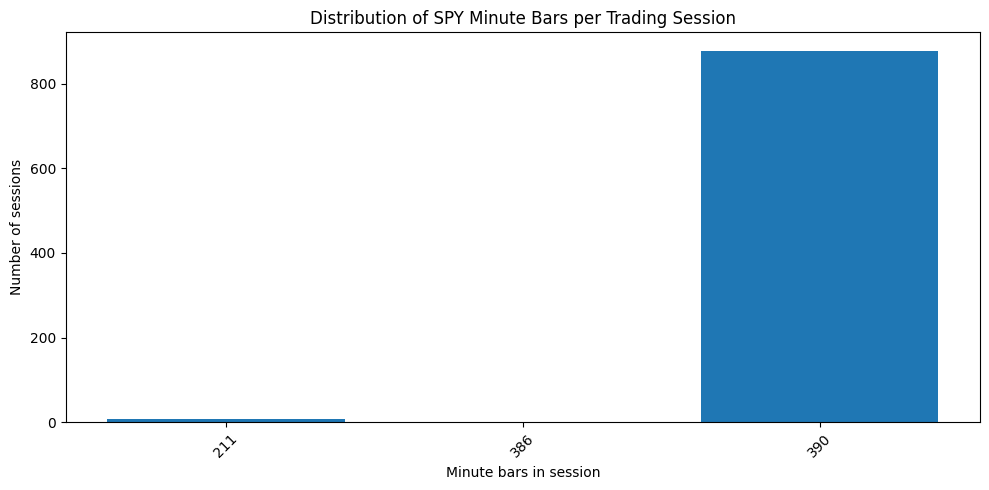

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\01_session_bar_count_distribution.png


In [12]:
# I use this cell for graph: number of minute bars per session.
bar_count_frequency = (
    session_audit["rows"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bar_count_frequency.index.astype(str), bar_count_frequency.values)
ax.set_title("Distribution of SPY Minute Bars per Trading Session")
ax.set_xlabel("Minute bars in session")
ax.set_ylabel("Number of sessions")
ax.tick_params(axis="x", rotation=45)
path = save_figure(fig, "01_session_bar_count_distribution.png")
plt.show()
print("Saved:", path)

### Graphs: SPX and VIX match staleness

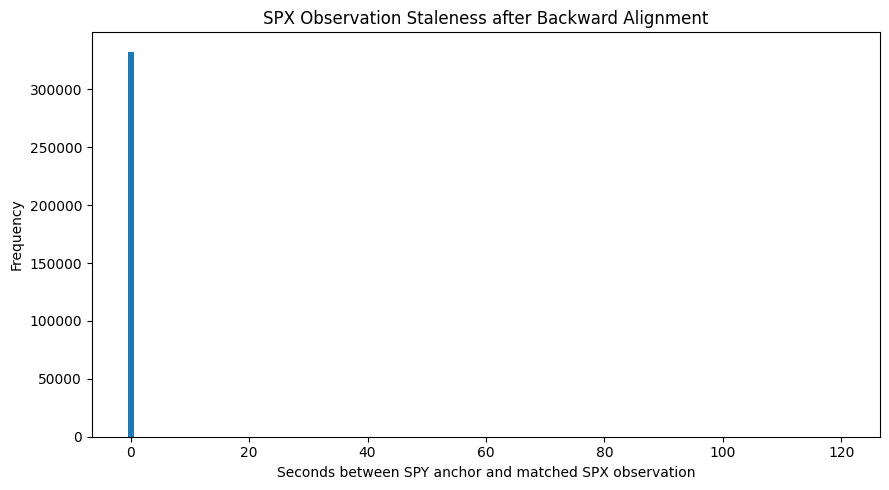

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\02_spx_alignment_staleness.png


In [13]:
# I use this cell for graphs: spx and vix match staleness.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    aligned["spx_staleness_seconds"].dropna(),
    bins=np.arange(-0.5, 121.5, 1),
)
ax.set_title("SPX Observation Staleness after Backward Alignment")
ax.set_xlabel("Seconds between SPY anchor and matched SPX observation")
ax.set_ylabel("Frequency")
path = save_figure(fig, "02_spx_alignment_staleness.png")
plt.show()
print("Saved:", path)

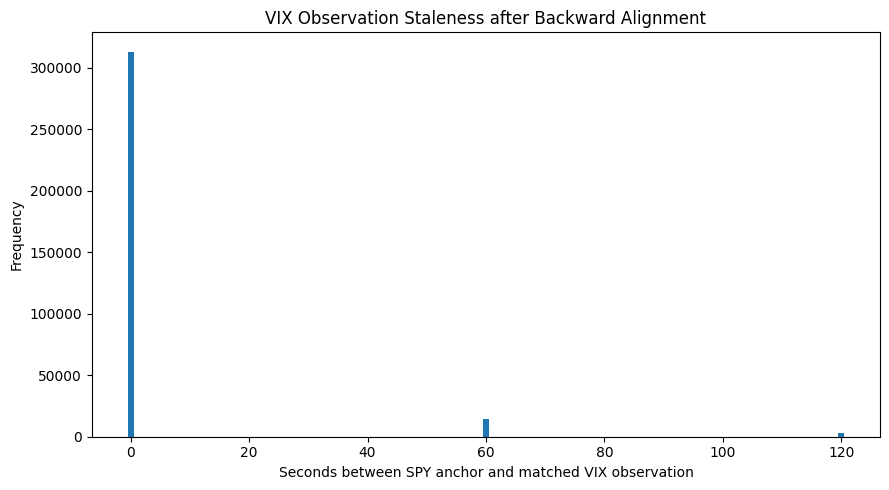

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\03_vix_alignment_staleness.png


In [14]:
# I use this cell for graphs: spx and vix match staleness.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    aligned["vix_staleness_seconds"].dropna(),
    bins=np.arange(-0.5, 121.5, 1),
)
ax.set_title("VIX Observation Staleness after Backward Alignment")
ax.set_xlabel("Seconds between SPY anchor and matched VIX observation")
ax.set_ylabel("Frequency")
path = save_figure(fig, "03_vix_alignment_staleness.png")
plt.show()
print("Saved:", path)

### Graph: missing aligned values by session

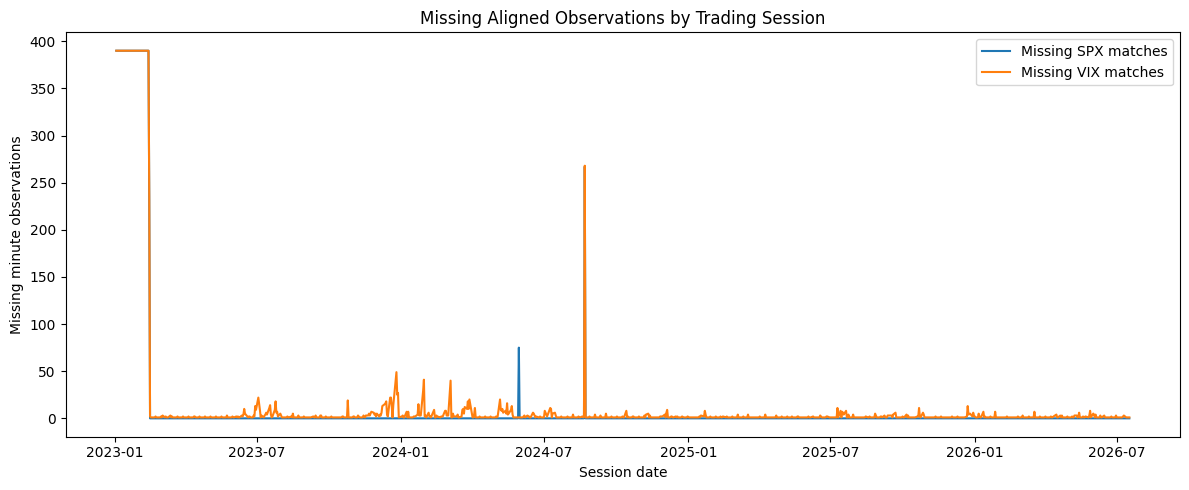

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\04_missing_matches_by_session.png


In [15]:
# I use this cell for graph: missing aligned values by session.
audit_dates = pd.to_datetime(session_audit["session_date"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(audit_dates, session_audit["missing_spx"], label="Missing SPX matches")
ax.plot(audit_dates, session_audit["missing_vix"], label="Missing VIX matches")
ax.set_title("Missing Aligned Observations by Trading Session")
ax.set_xlabel("Session date")
ax.set_ylabel("Missing minute observations")
ax.legend()
path = save_figure(fig, "04_missing_matches_by_session.png")
plt.show()
print("Saved:", path)

## 6. Save the aligned dataset and audit table

The Parquet files are portable research artifacts. The DuckDB tables allow subsequent notebooks to query the data directly.

In [16]:
# I use this cell for save the aligned dataset and audit table.
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
AUDIT_PATH = DERIVED_ROOT / "underlying_session_audit.parquet"

aligned.to_parquet(ALIGNED_PATH, index=False)
session_audit.to_parquet(AUDIT_PATH, index=False)

con.register("aligned_dataframe", aligned)
con.execute(
    """
    CREATE OR REPLACE TABLE aligned_underlyings_1min AS
    SELECT * FROM aligned_dataframe
    """
)
con.unregister("aligned_dataframe")

con.register("session_audit_dataframe", session_audit)
con.execute(
    """
    CREATE OR REPLACE TABLE underlying_session_audit AS
    SELECT * FROM session_audit_dataframe
    """
)
con.unregister("session_audit_dataframe")

print("Saved aligned data:", ALIGNED_PATH)
print("Saved audit data:", AUDIT_PATH)

display(
    con.execute(
        """
        SELECT
            MIN(session_date) AS first_date,
            MAX(session_date) AS last_date,
            COUNT(*) AS minute_rows,
            COUNT(DISTINCT session_date) AS sessions
        FROM aligned_underlyings_1min
        """
    ).df()
)

Saved aligned data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\aligned_underlyings_1min.parquet
Saved audit data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\underlying_session_audit.parquet


,first_date,last_date,minute_rows,sessions
0,2023-01-03,2026-07-17,344494,887


## 7. Construct a daily look-ahead-safe modelling dataset

The feature window ends with the 14:59 ET bar. Sessions without both a 14:59 anchor and a 15:59 anchor are excluded from the daily target dataset.

`NEUTRAL_THRESHOLD` controls the target classes:

- `0.0` gives Up/Down and uses Flat only for an exact zero return;
- a positive value, such as `0.001`, creates a neutral band of ±0.10%.

Keep this setting consistent with the target definition used in the dissertation.

In [17]:
# I use this cell for construct a daily look-ahead-safe modelling dataset.
NEUTRAL_THRESHOLD = 0.0


def last_value_at_or_before(
    frame: pd.DataFrame,
    value_column: str,
    target_timestamp: pd.Timestamp,
):
    values = frame.loc[
        frame["timestamp_utc"].le(target_timestamp),
        ["timestamp_utc", value_column],
    ].dropna(subset=[value_column])

    if values.empty:
        return np.nan

    return values.iloc[-1][value_column]


def return_over_minutes(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    minutes: int,
):
    end_value = last_value_at_or_before(frame, value_column, end_timestamp)
    start_value = last_value_at_or_before(
        frame,
        value_column,
        end_timestamp - pd.Timedelta(minutes=minutes),
    )

    if pd.isna(end_value) or pd.isna(start_value) or start_value == 0:
        return np.nan

    return end_value / start_value - 1


def realized_volatility(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    minutes: int,
):
    start_timestamp = end_timestamp - pd.Timedelta(minutes=minutes)

    values = (
        frame.loc[
            frame["timestamp_utc"].between(start_timestamp, end_timestamp),
            ["timestamp_utc", value_column],
        ]
        .dropna(subset=[value_column])
        .drop_duplicates("timestamp_utc")
        .sort_values("timestamp_utc")
    )

    if len(values) < 3:
        return np.nan

    log_returns = np.log(values[value_column]).diff().dropna()
    return float(np.sqrt(np.square(log_returns).sum()))


def prior_window_return(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    recent_minutes: int,
):
    recent_start = end_timestamp - pd.Timedelta(minutes=recent_minutes)
    prior_start = end_timestamp - pd.Timedelta(minutes=2 * recent_minutes)

    recent_start_value = last_value_at_or_before(
        frame, value_column, recent_start
    )
    prior_start_value = last_value_at_or_before(
        frame, value_column, prior_start
    )

    if (
        pd.isna(recent_start_value)
        or pd.isna(prior_start_value)
        or prior_start_value == 0
    ):
        return np.nan

    return recent_start_value / prior_start_value - 1


def create_daily_record(session_date: str, group: pd.DataFrame):
    group = group.sort_values("timestamp_utc").copy()

    feature_window = group[group["clock_minute"] < 15 * 60]
    close_window = group[group["clock_minute"] < 16 * 60]

    if feature_window.empty or close_window.empty:
        return None

    if feature_window["clock_minute"].max() < (14 * 60 + 59):
        return None

    if close_window["clock_minute"].max() < (15 * 60 + 59):
        return None

    end_timestamp = feature_window["timestamp_utc"].max()

    spx_features = feature_window.dropna(subset=["spx_close"])
    vix_features = feature_window.dropna(subset=["vix_close"])
    spy_features = feature_window.dropna(subset=["spy_close"])
    spx_close_window = close_window.dropna(subset=["spx_close"])

    if (
        spx_features.empty
        or vix_features.empty
        or spy_features.empty
        or spx_close_window.empty
    ):
        return None

    spx_at_1500 = float(spx_features.iloc[-1]["spx_close"])
    spx_at_close = float(spx_close_window.iloc[-1]["spx_close"])
    vix_at_1500 = float(vix_features.iloc[-1]["vix_close"])
    spy_at_1500 = float(spy_features.iloc[-1]["spy_close"])

    spx_open_values = spx_features["spx_open"].dropna()
    spy_open_values = spy_features["spy_open"].dropna()

    if spx_open_values.empty or spy_open_values.empty:
        return None

    spx_open = float(spx_open_values.iloc[0])
    spy_open = float(spy_open_values.iloc[0])

    spx_high = float(spx_features["spx_high"].max())
    spx_low = float(spx_features["spx_low"].min())
    intraday_range = spx_high - spx_low

    spy_volume = pd.to_numeric(
        feature_window["spy_volume"], errors="coerce"
    ).fillna(0)

    spy_vwap_values = pd.to_numeric(
        feature_window["spy_vwap"], errors="coerce"
    )

    valid_vwap = spy_vwap_values.notna() & spy_volume.gt(0)

    if valid_vwap.any():
        cumulative_spy_vwap = float(
            np.average(
                spy_vwap_values[valid_vwap],
                weights=spy_volume[valid_vwap],
            )
        )
    else:
        cumulative_spy_vwap = np.nan

    last_30 = feature_window[
        feature_window["timestamp_utc"].gt(
            end_timestamp - pd.Timedelta(minutes=30)
        )
    ]

    last_60 = feature_window[
        feature_window["timestamp_utc"].gt(
            end_timestamp - pd.Timedelta(minutes=60)
        )
    ]

    earlier_volume = feature_window[
        feature_window["timestamp_utc"].le(
            end_timestamp - pd.Timedelta(minutes=60)
        )
    ]["spy_volume"]

    expected_last_60_volume = (
        pd.to_numeric(earlier_volume, errors="coerce").mean() * 60
        if len(earlier_volume)
        else np.nan
    )

    last_60_volume = pd.to_numeric(
        last_60["spy_volume"], errors="coerce"
    ).sum()

    volume_acceleration = (
        last_60_volume / expected_last_60_volume - 1
        if pd.notna(expected_last_60_volume)
        and expected_last_60_volume > 0
        else np.nan
    )

    previous_close = spx_features["spx_close"].shift(1)
    true_range = pd.concat(
        [
            spx_features["spx_high"] - spx_features["spx_low"],
            (spx_features["spx_high"] - previous_close).abs(),
            (spx_features["spx_low"] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)

    ret_last_60m = return_over_minutes(
        feature_window, "spx_close", end_timestamp, 60
    )
    ret_prior_60m = prior_window_return(
        feature_window, "spx_close", end_timestamp, 60
    )

    final_hour_return = (
        spx_at_close / spx_at_1500 - 1
        if spx_at_1500 != 0
        else np.nan
    )

    if final_hour_return > NEUTRAL_THRESHOLD:
        target_class = "Up"
    elif final_hour_return < -NEUTRAL_THRESHOLD:
        target_class = "Down"
    else:
        target_class = "Flat"

    return {
        "session_date": session_date,
        "feature_cutoff_timestamp_utc": end_timestamp,
        "spx_at_1500": spx_at_1500,
        "spx_at_close": spx_at_close,
        "vix_level_1500": vix_at_1500,
        "spy_at_1500": spy_at_1500,
        "final_hour_return": final_hour_return,
        "final_hour_direction": target_class,
        "ret_open_to_1500": spx_at_1500 / spx_open - 1,
        "ret_last_15m": return_over_minutes(
            feature_window, "spx_close", end_timestamp, 15
        ),
        "ret_last_30m": return_over_minutes(
            feature_window, "spx_close", end_timestamp, 30
        ),
        "ret_last_60m": ret_last_60m,
        "vix_ret_last_15m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 15
        ),
        "vix_ret_last_30m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 30
        ),
        "vix_ret_last_60m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 60
        ),
        "realized_vol_30m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 30
        ),
        "realized_vol_60m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 60
        ),
        "realized_vol_120m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 120
        ),
        "rv_open_to_1500": realized_volatility(
            feature_window,
            "spx_close",
            end_timestamp,
            int(
                (
                    end_timestamp
                    - feature_window["timestamp_utc"].min()
                ).total_seconds()
                // 60
            ),
        ),
        "spy_ret_open_to_1500": spy_at_1500 / spy_open - 1,
        "spy_volume_last_30m": pd.to_numeric(
            last_30["spy_volume"], errors="coerce"
        ).sum(),
        "spy_volume_last_60m": last_60_volume,
        "spy_cum_volume_to_1500": spy_volume.sum(),
        "spy_volume_accel_60m_vs_avg": volume_acceleration,
        "spy_dist_from_vwap_pct": (
            spy_at_1500 / cumulative_spy_vwap - 1
            if pd.notna(cumulative_spy_vwap)
            and cumulative_spy_vwap != 0
            else np.nan
        ),
        "position_in_day_range": (
            (spx_at_1500 - spx_low) / intraday_range
            if intraday_range > 0
            else np.nan
        ),
        "dist_from_day_high_pct": spx_at_1500 / spx_high - 1,
        "dist_from_day_low_pct": spx_at_1500 / spx_low - 1,
        "dist_from_open_pct": spx_at_1500 / spx_open - 1,
        "momentum_accel_60m_vs_prior": (
            ret_last_60m - ret_prior_60m
            if pd.notna(ret_last_60m)
            and pd.notna(ret_prior_60m)
            else np.nan
        ),
        "atr_open_to_1500": float(true_range.mean()),
        "observations_before_1500": len(feature_window),
        "missing_spx_before_1500": int(
            feature_window["spx_close"].isna().sum()
        ),
        "missing_vix_before_1500": int(
            feature_window["vix_close"].isna().sum()
        ),
    }


daily_records = []

for session_date, group in aligned.groupby("session_date"):
    record = create_daily_record(session_date, group)
    if record is not None:
        daily_records.append(record)

daily_model = pd.DataFrame(daily_records)
daily_model["session_date"] = pd.to_datetime(daily_model["session_date"])
daily_model["day_of_week"] = daily_model["session_date"].dt.day_name()
daily_model["month"] = daily_model["session_date"].dt.to_period("M").astype(str)
daily_model = daily_model.sort_values("session_date").reset_index(drop=True)

if daily_model.empty:
    raise RuntimeError(
        "No valid daily modelling rows were created. "
        "Inspect the session audit and ticker data."
    )

display(daily_model.head())
print("Daily modelling sessions:", len(daily_model))
print(
    "Date range:",
    daily_model["session_date"].min().date(),
    "to",
    daily_model["session_date"].max().date(),
)

,session_date,feature_cutoff_timestamp_utc,spx_at_1500,spx_at_close,vix_level_1500,spy_at_1500,final_hour_return,final_hour_direction,ret_open_to_1500,ret_last_15m,ret_last_30m,ret_last_60m,vix_ret_last_15m,vix_ret_last_30m,vix_ret_last_60m,realized_vol_30m,realized_vol_60m,realized_vol_120m,rv_open_to_1500,spy_ret_open_to_1500,spy_volume_last_30m,spy_volume_last_60m,spy_cum_volume_to_1500,spy_volume_accel_60m_vs_avg,spy_dist_from_vwap_pct,position_in_day_range,dist_from_day_high_pct,dist_from_day_low_pct,dist_from_open_pct,momentum_accel_60m_vs_prior,atr_open_to_1500,observations_before_1500,missing_spx_before_1500,missing_vix_before_1500,day_of_week,month
0,2023-02-14,2023-02-14 19:59:00+00:00,"4,140.810000","4,136.030000",18.720000,413.160000,-0.001154,Down,0.000657,-0.000514,0.001589,0.001708,-0.000534,-0.006369,-0.005313,0.001752,0.003339,0.004254,0.004254,0.004669,"3,479,445.000000","6,958,992.000000","58,311,068.000000",-0.390181,0.003522,0.797391,-0.001124,0.004449,0.000657,NaN,1.947959,330,232,232,Tuesday,2023-02
1,2023-02-15,2023-02-15 19:59:00+00:00,"4,132.230000","4,147.480000",18.310000,412.430000,0.003691,Up,0.003090,-0.002417,-0.001927,-0.001322,0.003838,0.002189,0.006044,0.001350,0.001771,0.002480,0.006770,0.005069,"2,883,294.000000","6,877,371.000000","40,864,767.000000",-0.089422,0.001620,0.719745,-0.002655,0.006884,0.003090,-0.004839,1.773273,330,0,2,Wednesday,2023-02
2,2023-02-16,2023-02-16 19:59:00+00:00,"4,129.870000","4,090.270000",18.540000,412.180000,-0.009589,Down,0.003675,-0.000363,-0.000767,0.000170,0.000540,0.001080,-0.008026,0.001206,0.001927,0.002946,0.006563,0.008293,"2,431,714.000000","4,861,469.000000","44,440,371.000000",-0.447266,0.002862,0.853310,-0.001612,0.009484,0.003675,0.000143,1.921545,330,0,1,Thursday,2023-02
3,2023-02-17,2023-02-17 19:59:00+00:00,"4,077.900000","4,078.980000",19.920000,407.089000,0.000265,Up,0.000125,0.002168,0.002522,0.004815,-0.013861,-0.011905,-0.030185,0.001815,0.002561,0.003320,0.006619,0.002534,"4,407,741.000000","9,250,946.000000","55,514,084.000000",-0.100164,0.003823,0.960552,-0.000302,0.007399,0.000125,0.003149,1.832636,330,0,1,Friday,2023-02
4,2023-02-21,2023-02-21 19:59:00+00:00,"4,003.700000","3,997.240000",22.780000,399.700000,-0.001614,Down,-0.012005,-0.000454,0.001008,0.000137,-0.006108,-0.014280,-0.008703,0.001994,0.002361,0.002867,0.006083,-0.008336,"4,674,200.000000","10,089,988.000000","53,681,498.000000",0.041601,-0.004743,0.148880,-0.012005,0.002130,-0.012005,0.003315,1.649030,330,0,1,Tuesday,2023-02


Daily modelling sessions: 850
Date range: 2023-02-14 to 2026-07-17


## 8. Save the daily modelling dataset

This table is the appropriate starting point for feature EDA, feature selection and time-series model validation.

In [18]:
# I use this cell for save the daily modelling dataset.
DAILY_MODEL_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"

daily_model.to_parquet(DAILY_MODEL_PATH, index=False)

con.register("daily_model_dataframe", daily_model)
con.execute(
    """
    CREATE OR REPLACE TABLE daily_underlying_model_dataset AS
    SELECT * FROM daily_model_dataframe
    """
)
con.unregister("daily_model_dataframe")

print("Saved daily modelling data:", DAILY_MODEL_PATH)

display(
    con.execute(
        """
        SELECT
            MIN(session_date) AS first_date,
            MAX(session_date) AS last_date,
            COUNT(*) AS sessions
        FROM daily_underlying_model_dataset
        """
    ).df()
)

Saved daily modelling data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset.parquet


,first_date,last_date,sessions
0,2023-02-14,2026-07-17,850


# Exploratory Data Analysis

The following section examines coverage, missingness, distributions, relationships and time variation. Each figure is saved automatically as a high-resolution PNG.

## 9. Descriptive statistics and missingness

In [19]:
# I use this cell for descriptive statistics and missingness.
eda_columns = [
    "final_hour_return",
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_ret_open_to_1500",
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "momentum_accel_60m_vs_prior",
    "atr_open_to_1500",
]

descriptive_statistics = daily_model[eda_columns].describe().T
descriptive_statistics["skewness"] = daily_model[eda_columns].skew()
descriptive_statistics["kurtosis"] = daily_model[eda_columns].kurtosis()

display(descriptive_statistics)

missingness = pd.DataFrame(
    {
        "missing_values": daily_model[eda_columns].isna().sum(),
        "missing_pct": daily_model[eda_columns].isna().mean() * 100,
    }
).sort_values("missing_pct", ascending=False)

display(missingness)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
final_hour_return,850.000000,-0.000074,0.002833,-0.016814,-0.001225,-0.000014,0.001300,0.023114,-0.019258,9.782442
ret_open_to_1500,850.000000,0.000344,0.006906,-0.037053,-0.003040,0.000412,0.004391,0.073142,0.846223,15.833468
ret_last_15m,850.000000,-0.000055,0.001208,-0.007059,-0.000486,0.000027,0.000536,0.005142,-1.216506,6.629537
ret_last_30m,850.000000,0.000026,0.001677,-0.013975,-0.000642,0.000088,0.000874,0.008143,-0.804124,8.449524
ret_last_60m,850.000000,0.000021,0.002559,-0.015158,-0.001035,0.000121,0.001166,0.013302,-0.317483,6.004133
vix_level_1500,850.000000,17.399212,4.268823,11.840000,14.630000,16.650000,19.037500,50.170000,2.490376,11.491539
vix_ret_last_15m,850.000000,-0.001026,0.010803,-0.057051,-0.005902,-0.001440,0.002361,0.096736,1.493736,13.561080
vix_ret_last_30m,850.000000,-0.001705,0.014615,-0.074870,-0.008315,-0.002591,0.003536,0.116616,1.181978,9.024955
vix_ret_last_60m,850.000000,-0.002231,0.023302,-0.123903,-0.011020,-0.003974,0.005560,0.218997,1.689994,15.596347
realized_vol_30m,849.000000,0.001396,0.001007,0.000286,0.000802,0.001121,0.001639,0.009994,3.385115,18.156656


,missing_values,missing_pct
momentum_accel_60m_vs_prior,1,0.117647
realized_vol_30m,1,0.117647
realized_vol_60m,1,0.117647
realized_vol_120m,1,0.117647
final_hour_return,0,0.000000
spy_volume_last_30m,0,0.000000
dist_from_day_low_pct,0,0.000000
dist_from_day_high_pct,0,0.000000
position_in_day_range,0,0.000000
spy_dist_from_vwap_pct,0,0.000000


## 10. Target distribution and class balance

In [20]:
# I use this cell for target distribution and class balance.
target_summary = daily_model["final_hour_return"].describe().to_frame(
    "final_hour_return"
)
display(target_summary)

class_distribution = (
    daily_model["final_hour_direction"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="sessions")
)

class_distribution["percentage"] = (
    class_distribution["sessions"] / len(daily_model) * 100
)

display(class_distribution)

,final_hour_return
count,850.000000
mean,-0.000074
std,0.002833
min,-0.016814
25%,-0.001225
50%,-0.000014
75%,0.001300
max,0.023114


,class,sessions,percentage
0,Down,428,50.352941
1,Up,420,49.411765
2,Flat,2,0.235294


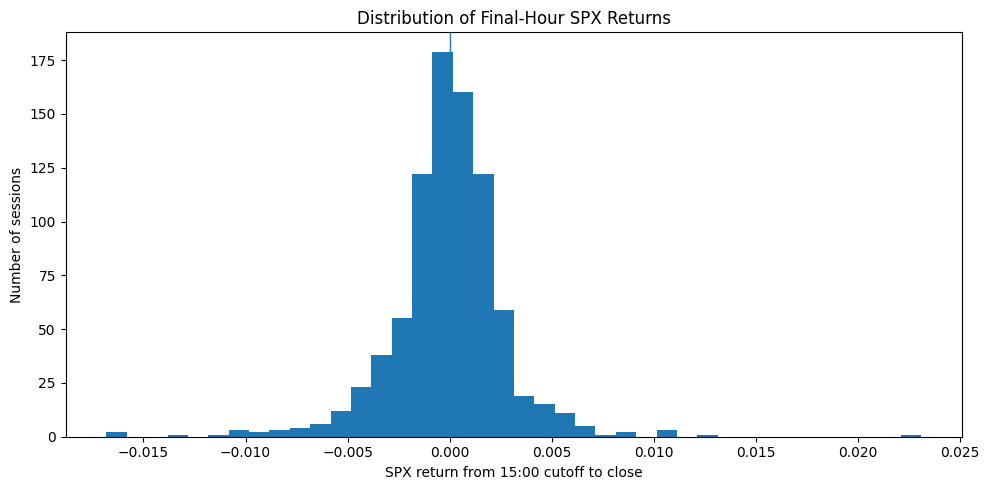

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\05_final_hour_return_distribution.png


In [21]:
# I use this cell for target distribution and class balance.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(daily_model["final_hour_return"].dropna(), bins=40)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of Final-Hour SPX Returns")
ax.set_xlabel("SPX return from 15:00 cutoff to close")
ax.set_ylabel("Number of sessions")
path = save_figure(fig, "05_final_hour_return_distribution.png")
plt.show()
print("Saved:", path)

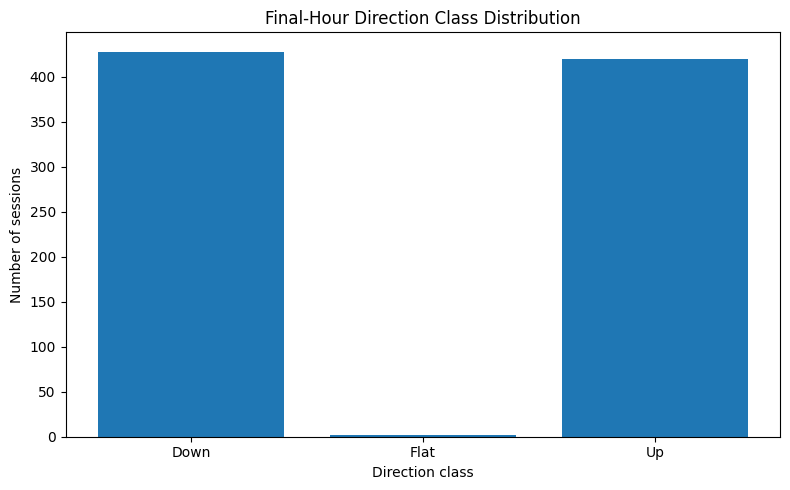

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\06_direction_class_distribution.png


In [22]:
# I use this cell for target distribution and class balance.
class_counts = (
    daily_model["final_hour_direction"]
    .value_counts()
    .reindex(["Down", "Flat", "Up"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values)
ax.set_title("Final-Hour Direction Class Distribution")
ax.set_xlabel("Direction class")
ax.set_ylabel("Number of sessions")
path = save_figure(fig, "06_direction_class_distribution.png")
plt.show()
print("Saved:", path)

## 11. Market levels and target behaviour through time

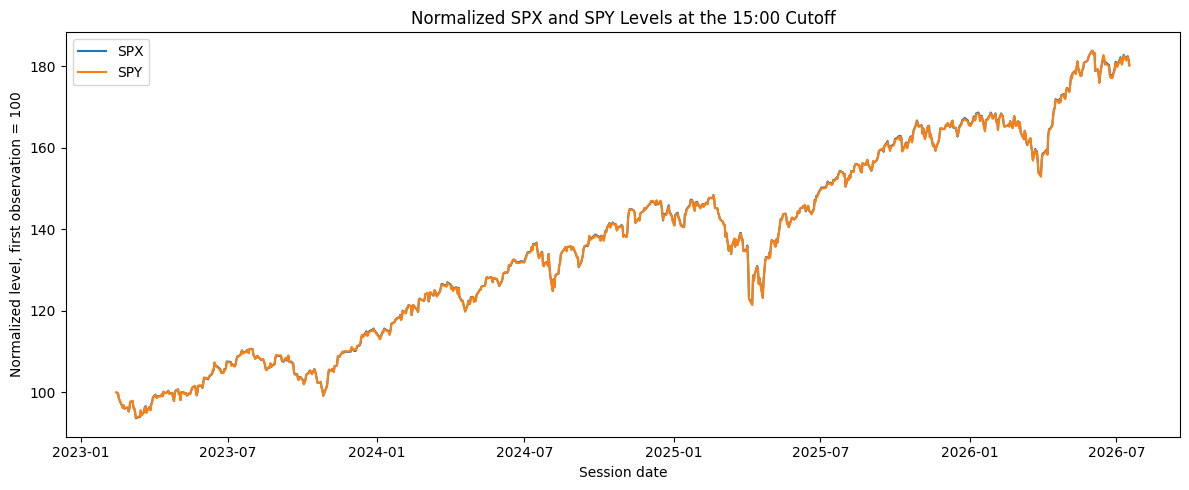

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\07_normalized_spx_spy_levels.png


In [23]:
# I use this cell for market levels and target behaviour through time.
levels = daily_model[
    ["session_date", "spx_at_1500", "spy_at_1500"]
].dropna().copy()

levels["SPX normalized"] = (
    levels["spx_at_1500"] / levels["spx_at_1500"].iloc[0] * 100
)
levels["SPY normalized"] = (
    levels["spy_at_1500"] / levels["spy_at_1500"].iloc[0] * 100
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(levels["session_date"], levels["SPX normalized"], label="SPX")
ax.plot(levels["session_date"], levels["SPY normalized"], label="SPY")
ax.set_title("Normalized SPX and SPY Levels at the 15:00 Cutoff")
ax.set_xlabel("Session date")
ax.set_ylabel("Normalized level, first observation = 100")
ax.legend()
path = save_figure(fig, "07_normalized_spx_spy_levels.png")
plt.show()
print("Saved:", path)

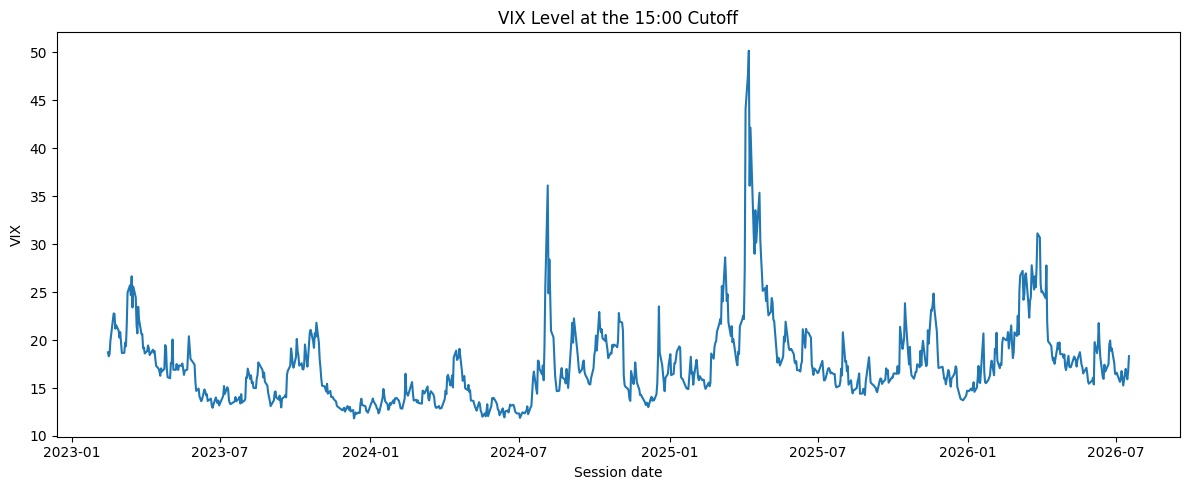

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\08_vix_level_over_time.png


In [24]:
# I use this cell for market levels and target behaviour through time.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_model["session_date"], daily_model["vix_level_1500"])
ax.set_title("VIX Level at the 15:00 Cutoff")
ax.set_xlabel("Session date")
ax.set_ylabel("VIX")
path = save_figure(fig, "08_vix_level_over_time.png")
plt.show()
print("Saved:", path)

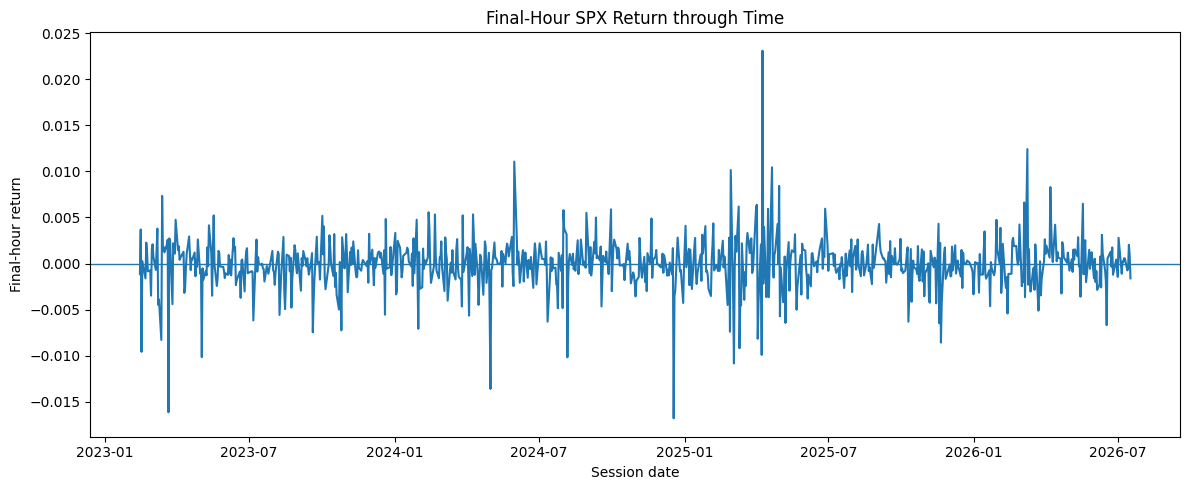

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\09_final_hour_return_over_time.png


In [25]:
# I use this cell for market levels and target behaviour through time.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    daily_model["session_date"],
    daily_model["final_hour_return"],
)
ax.axhline(0, linewidth=1)
ax.set_title("Final-Hour SPX Return through Time")
ax.set_xlabel("Session date")
ax.set_ylabel("Final-hour return")
path = save_figure(fig, "09_final_hour_return_over_time.png")
plt.show()
print("Saved:", path)

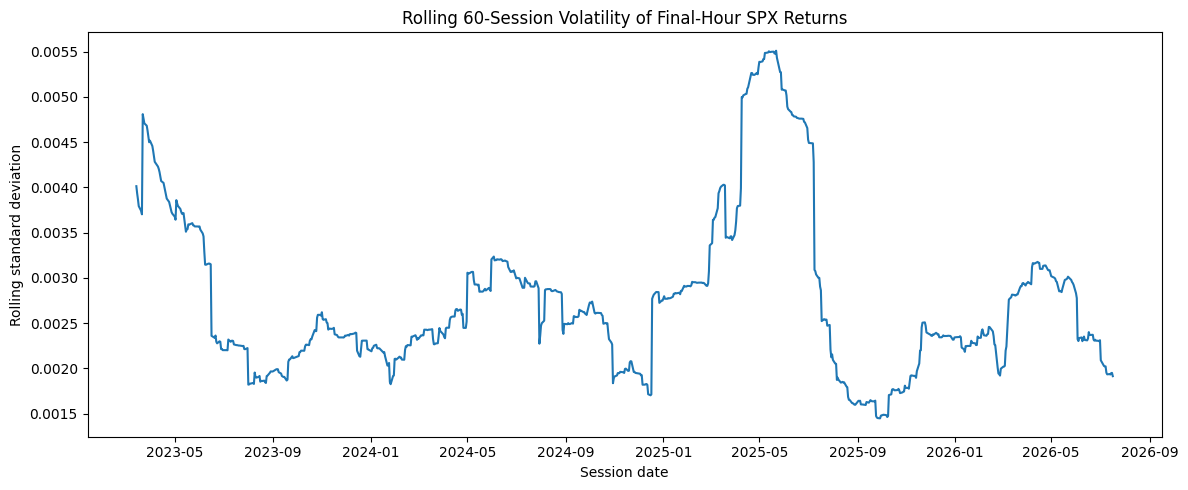

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\10_rolling_final_hour_volatility.png


In [26]:
# I use this cell for market levels and target behaviour through time.
rolling_window = 60

rolling_target_volatility = (
    daily_model["final_hour_return"]
    .rolling(rolling_window, min_periods=20)
    .std()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    daily_model["session_date"],
    rolling_target_volatility,
)
ax.set_title(
    f"Rolling {rolling_window}-Session Volatility of Final-Hour SPX Returns"
)
ax.set_xlabel("Session date")
ax.set_ylabel("Rolling standard deviation")
path = save_figure(fig, "10_rolling_final_hour_volatility.png")
plt.show()
print("Saved:", path)

## 12. Weekday analysis

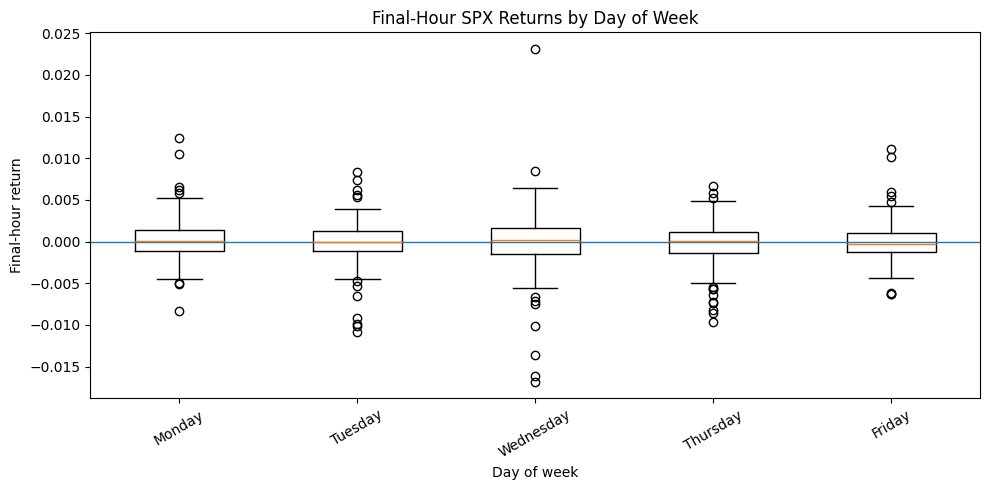

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\11_final_hour_return_by_weekday.png


,count,mean,median,std
day_of_week,,,,
Monday,160,0.000270,0.000029,0.002590
Tuesday,177,-0.000088,-0.000010,0.002578
Wednesday,174,-0.000067,0.000177,0.003767
Thursday,170,-0.000334,0.000126,0.002639
Friday,169,-0.000130,-0.000312,0.002335


In [27]:
# I use this cell for weekday analysis.
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
]

weekday_values = [
    daily_model.loc[
        daily_model["day_of_week"].eq(day),
        "final_hour_return",
    ].dropna()
    for day in weekday_order
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(weekday_values, labels=weekday_order, showfliers=True)
ax.axhline(0, linewidth=1)
ax.set_title("Final-Hour SPX Returns by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Final-hour return")
ax.tick_params(axis="x", rotation=30)
path = save_figure(fig, "11_final_hour_return_by_weekday.png")
plt.show()
print("Saved:", path)

display(
    daily_model.groupby("day_of_week")["final_hour_return"]
    .agg(["count", "mean", "median", "std"])
    .reindex(weekday_order)
)

## 13. Relationships with volatility and earlier momentum

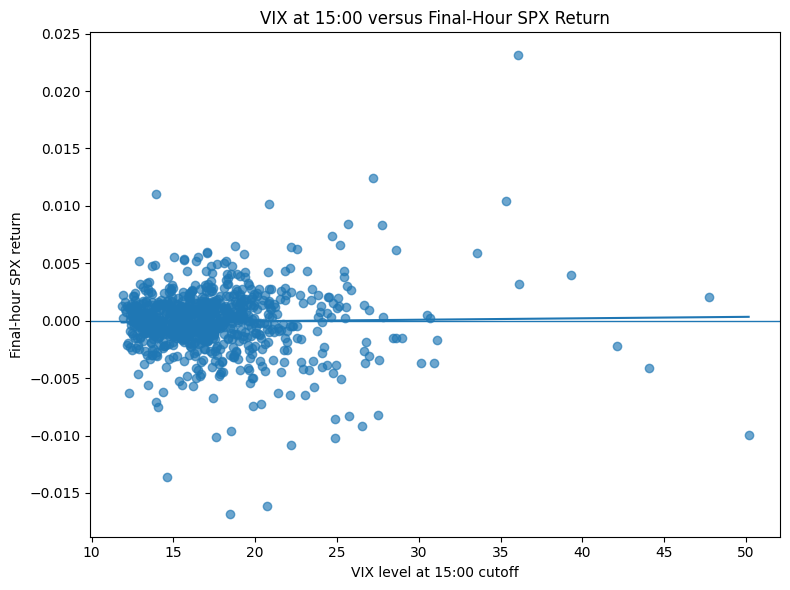

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\12_vix_vs_final_hour_return.png


In [28]:
# I use this cell for relationships with volatility and earlier momentum.
scatter_data = daily_model[
    ["vix_level_1500", "final_hour_return"]
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    scatter_data["vix_level_1500"],
    scatter_data["final_hour_return"],
    alpha=0.65,
)

if len(scatter_data) >= 2:
    slope, intercept = np.polyfit(
        scatter_data["vix_level_1500"],
        scatter_data["final_hour_return"],
        1,
    )
    x_line = np.linspace(
        scatter_data["vix_level_1500"].min(),
        scatter_data["vix_level_1500"].max(),
        100,
    )
    ax.plot(x_line, slope * x_line + intercept)

ax.axhline(0, linewidth=1)
ax.set_title("VIX at 15:00 versus Final-Hour SPX Return")
ax.set_xlabel("VIX level at 15:00 cutoff")
ax.set_ylabel("Final-hour SPX return")
path = save_figure(fig, "12_vix_vs_final_hour_return.png")
plt.show()
print("Saved:", path)

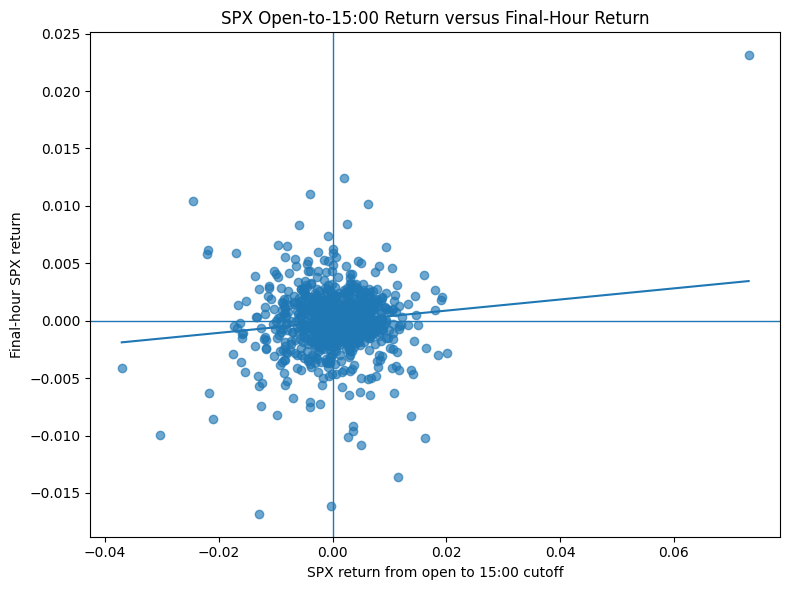

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\13_open_to_1500_vs_final_hour_return.png


In [29]:
# I use this cell for relationships with volatility and earlier momentum.
scatter_data = daily_model[
    ["ret_open_to_1500", "final_hour_return"]
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    scatter_data["ret_open_to_1500"],
    scatter_data["final_hour_return"],
    alpha=0.65,
)

if len(scatter_data) >= 2:
    slope, intercept = np.polyfit(
        scatter_data["ret_open_to_1500"],
        scatter_data["final_hour_return"],
        1,
    )
    x_line = np.linspace(
        scatter_data["ret_open_to_1500"].min(),
        scatter_data["ret_open_to_1500"].max(),
        100,
    )
    ax.plot(x_line, slope * x_line + intercept)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_title("SPX Open-to-15:00 Return versus Final-Hour Return")
ax.set_xlabel("SPX return from open to 15:00 cutoff")
ax.set_ylabel("Final-hour SPX return")
path = save_figure(fig, "13_open_to_1500_vs_final_hour_return.png")
plt.show()
print("Saved:", path)

## 14. Feature correlations

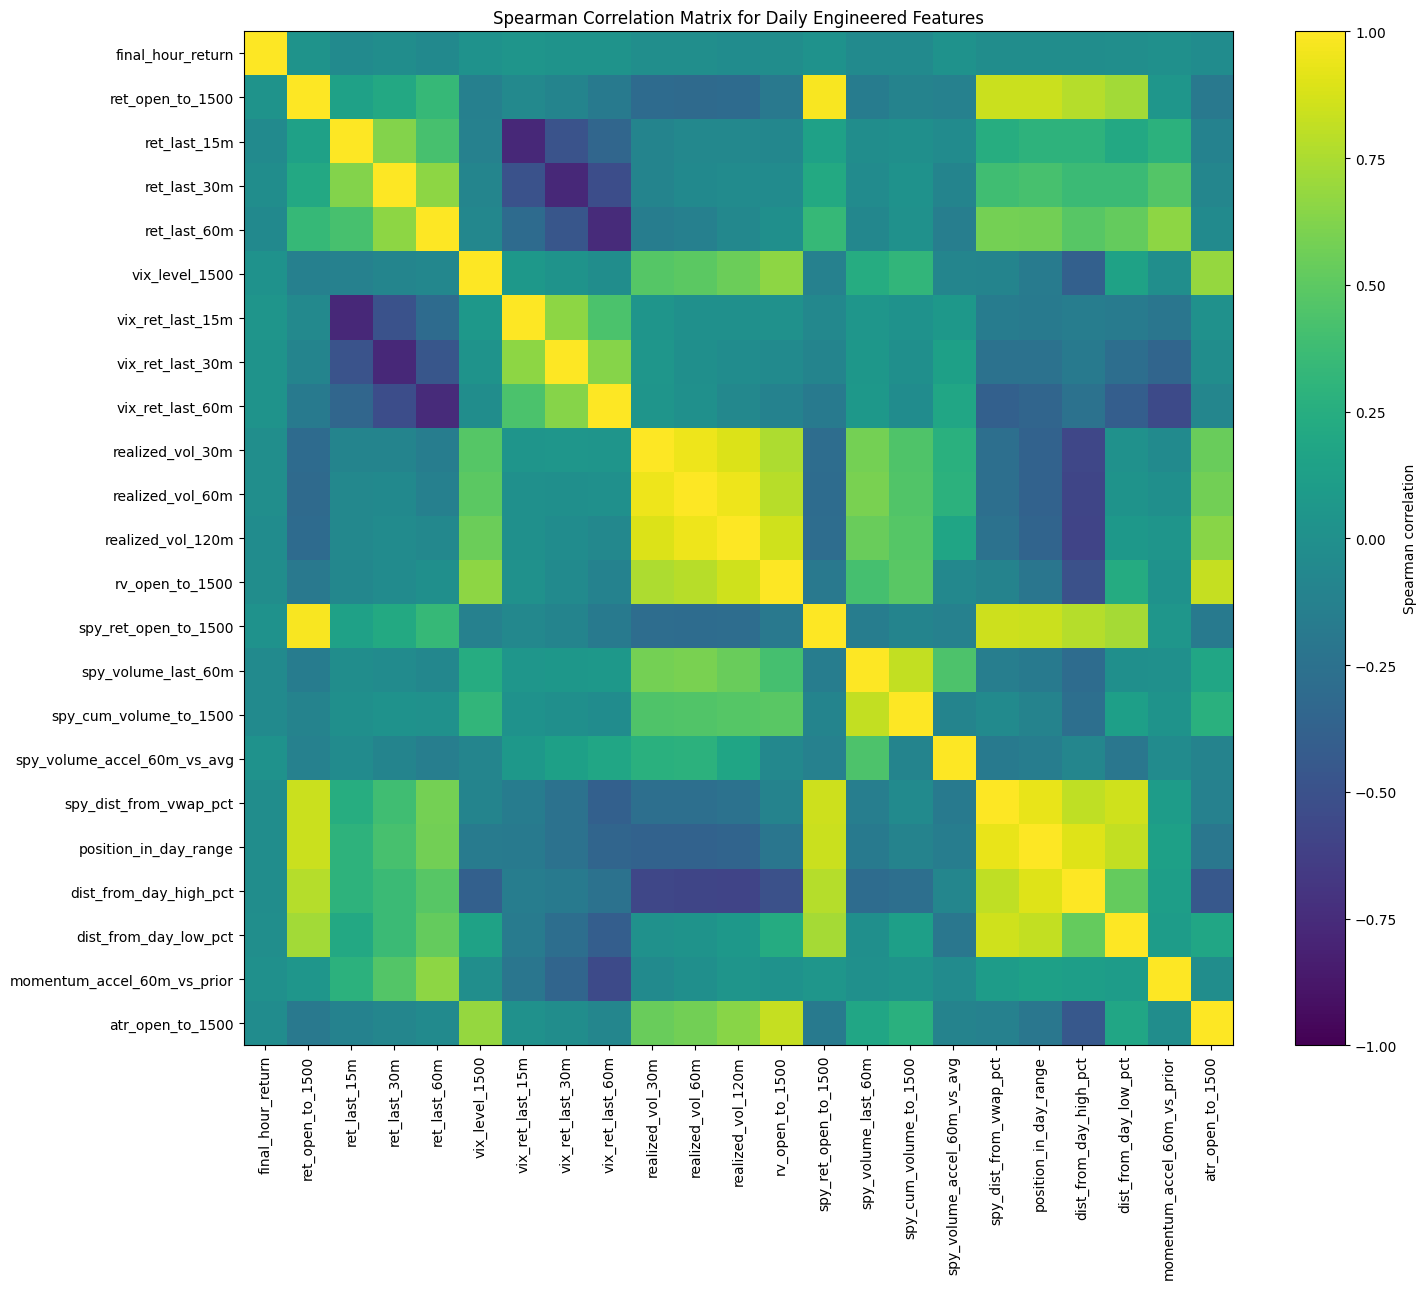

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\14_feature_correlation_matrix.png


In [30]:
# I use this cell for feature correlations.
correlation_columns = [
    "final_hour_return",
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_ret_open_to_1500",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "momentum_accel_60m_vs_prior",
    "atr_open_to_1500",
]

correlation_matrix = daily_model[correlation_columns].corr(
    method="spearman"
)

fig, ax = plt.subplots(figsize=(15, 13))
image = ax.imshow(
    correlation_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=90)
ax.set_yticklabels(correlation_columns)
ax.set_title("Spearman Correlation Matrix for Daily Engineered Features")
fig.colorbar(image, ax=ax, label="Spearman correlation")
path = save_figure(fig, "14_feature_correlation_matrix.png")
plt.show()
print("Saved:", path)

,spearman_correlation_with_final_hour_return
ret_last_60m,-0.050608
ret_last_15m,-0.046249
spy_volume_last_60m,-0.040895
spy_cum_volume_to_1500,-0.040063
atr_open_to_1500,-0.027632
realized_vol_120m,-0.026486
rv_open_to_1500,-0.021964
dist_from_day_high_pct,-0.020223
ret_last_30m,-0.019208
spy_dist_from_vwap_pct,-0.018627


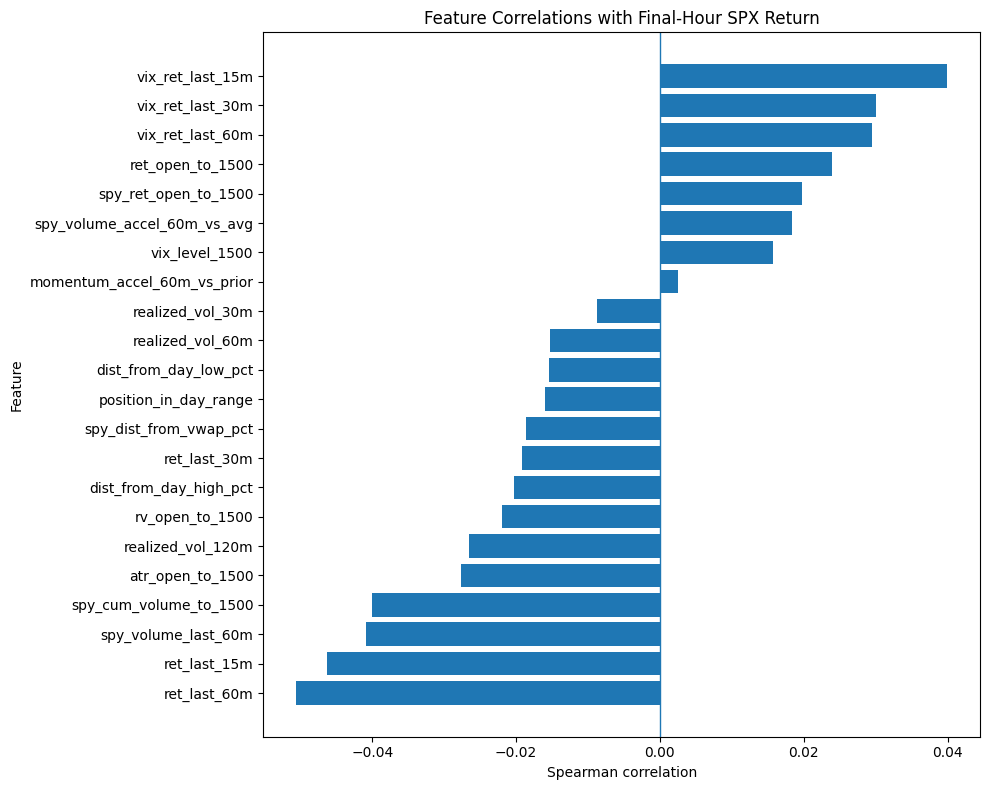

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\eda_figures\15_feature_target_correlations.png


In [31]:
# I use this cell for feature correlations.
target_correlations = (
    correlation_matrix["final_hour_return"]
    .drop("final_hour_return")
    .sort_values()
)

display(
    target_correlations.to_frame(
        "spearman_correlation_with_final_hour_return"
    )
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(target_correlations.index, target_correlations.values)
ax.axvline(0, linewidth=1)
ax.set_title("Feature Correlations with Final-Hour SPX Return")
ax.set_xlabel("Spearman correlation")
ax.set_ylabel("Feature")
path = save_figure(fig, "15_feature_target_correlations.png")
plt.show()
print("Saved:", path)

## 15. EDA outputs and my next decision

Before modelling:

1. inspect every row in `problem_sessions`;
2. verify that the daily dataset excludes early-close and partial sessions;
3. decide whether the target needs a neutral threshold;
4. compare these reconstructed features with the original project definitions;
5. use chronological train/validation/test splits rather than random splits.

After these checks, proceed to the controlled SPX option-history notebook.

---
# Part II — Cleaning and pre-modelling audits

This retains the integrity checks, problem-session review, neutral-threshold sensitivity and feature-definition reconciliation from `04_cleaning_modellingprep.ipynb`. The strict/relaxed dataset notebook below remains the authoritative source for the modelling variants and common chronological split boundaries, so the duplicate split/preprocessing portion of the cleaning notebook is intentionally not repeated here.

## 1. Environment and project discovery

I search the current folder and its parents for `data_extended_2023_2026/market.duckdb`. I use the extended EDA Parquet files when present and fall back to DuckDB tables when needed.

In [32]:
# I use this cell for environment and project discovery.
from pathlib import Path
import json
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data_extended_2023_2026" / "market.duckdb").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data_extended_2023_2026/market.duckdb. Place this notebook inside the Massive project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"
CLEANING_ROOT = OUTPUT_ROOT / "cleaning"
FIGURE_ROOT = CLEANING_ROOT / "figures"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
CLEANING_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


print("Project root:", PROJECT_ROOT)
print("Cleaning output:", CLEANING_ROOT)

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Cleaning output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning


## 2. Load the EDA outputs

In [33]:
# I use this cell for load the eda outputs.
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
AUDIT_PATH = DERIVED_ROOT / "underlying_session_audit.parquet"
DAILY_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"


def load_parquet_or_table(path: Path, table_name: str) -> pd.DataFrame:
    if path.exists():
        print("Loading", path)
        return pd.read_parquet(path)

    tables = set(
        con.execute(
            "SELECT table_name FROM information_schema.tables"
        ).df()["table_name"]
    )
    if table_name in tables:
        print("Loading DuckDB table", table_name)
        return con.execute(f"SELECT * FROM {table_name}").df()

    raise FileNotFoundError(f"Missing {path} and DuckDB table {table_name}.")


aligned = load_parquet_or_table(ALIGNED_PATH, "aligned_underlyings_1min")
session_audit = load_parquet_or_table(AUDIT_PATH, "underlying_session_audit")
daily_model = load_parquet_or_table(DAILY_PATH, "daily_underlying_model_dataset")

aligned["timestamp_utc"] = pd.to_datetime(aligned["timestamp_utc"], utc=True)
aligned["timestamp_et"] = pd.to_datetime(aligned["timestamp_et"])
aligned["session_date"] = aligned["session_date"].astype(str)
for column in ["spx_timestamp_utc", "vix_timestamp_utc"]:
    if column in aligned.columns:
        aligned[column] = pd.to_datetime(aligned[column], utc=True)

session_audit["session_date"] = session_audit["session_date"].astype(str)
daily_model["session_date"] = pd.to_datetime(daily_model["session_date"])
if "feature_cutoff_timestamp_utc" in daily_model.columns:
    daily_model["feature_cutoff_timestamp_utc"] = pd.to_datetime(
        daily_model["feature_cutoff_timestamp_utc"], utc=True
    )

print("Aligned rows:", len(aligned))
print("Audit sessions:", len(session_audit))
print("Daily rows:", len(daily_model))

Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\aligned_underlyings_1min.parquet
Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\underlying_session_audit.parquet
Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset.parquet
Aligned rows: 344494
Audit sessions: 887
Daily rows: 850


## 3. Basic integrity cleaning

Duplicate timestamps and duplicate daily dates are removed deterministically. Infinite values are converted to missing values so that they cannot silently enter a model.

In [34]:
# I use this cell for basic integrity cleaning.
integrity_before = pd.DataFrame(
    {
        "check": [
            "Duplicate aligned timestamps",
            "Duplicate daily session dates",
            "Missing target values",
            "Non-finite target values",
        ],
        "value": [
            int(aligned.duplicated(["session_date", "timestamp_utc"]).sum()),
            int(daily_model.duplicated(["session_date"]).sum()),
            int(daily_model["final_hour_return"].isna().sum()),
            int((~np.isfinite(pd.to_numeric(daily_model["final_hour_return"], errors="coerce"))).sum()),
        ],
    }
)
display(integrity_before)

aligned = (
    aligned.drop_duplicates(["session_date", "timestamp_utc"], keep="last")
    .sort_values(["session_date", "timestamp_utc"])
    .reset_index(drop=True)
)
daily_model = (
    daily_model.drop_duplicates(["session_date"], keep="last")
    .sort_values("session_date")
    .reset_index(drop=True)
)

numeric_columns = daily_model.select_dtypes(include=[np.number]).columns
daily_model[numeric_columns] = daily_model[numeric_columns].replace([np.inf, -np.inf], np.nan)

,check,value
0,Duplicate aligned timestamps,0
1,Duplicate daily session dates,0
2,Missing target values,0
3,Non-finite target values,0


## 4. Review and classify problem sessions

A strict full session must contain 390 SPY minute bars, exact SPX observations at 14:59 and 15:59 ET, and no missing SPX or VIX values in the final 120-minute feature window from 13:00 through 14:59 ET.

In [35]:
# I use this cell for review and classify problem sessions.
if "clock_minute" not in aligned.columns:
    aligned["clock_minute"] = aligned["timestamp_et"].dt.hour * 60 + aligned["timestamp_et"].dt.minute


def exact_spx_anchor(group: pd.DataFrame, minute_of_day: int) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]
    if anchor.empty or "spx_timestamp_utc" not in anchor.columns:
        return False
    return bool(
        anchor["spx_close"].notna().any()
        and anchor["spx_timestamp_utc"].eq(anchor["timestamp_utc"]).any()
    )


strict_rows = []
for session_date, group in aligned.groupby("session_date"):
    group = group.sort_values("timestamp_utc")
    final_120m = group[group["clock_minute"].between(13 * 60, 14 * 60 + 59)]
    strict_rows.append(
        {
            "session_date": session_date,
            "aligned_rows": len(group),
            "exact_spx_1459": exact_spx_anchor(group, 14 * 60 + 59),
            "exact_spx_1559": exact_spx_anchor(group, 15 * 60 + 59),
            "missing_spx_final_120m": int(final_120m["spx_close"].isna().sum()),
            "missing_vix_final_120m": int(final_120m["vix_close"].isna().sum()),
        }
    )

anchor_audit = pd.DataFrame(strict_rows)
eligibility = session_audit.merge(anchor_audit, on="session_date", how="outer")
eligibility["rows"] = pd.to_numeric(eligibility["rows"], errors="coerce")

eligibility["strictly_eligible"] = (
    eligibility["rows"].eq(390)
    & eligibility["has_1459_anchor"].fillna(False)
    & eligibility["has_1559_anchor"].fillna(False)
    & eligibility["exact_spx_1459"].fillna(False)
    & eligibility["exact_spx_1559"].fillna(False)
    & eligibility["missing_spx_final_120m"].fillna(999).eq(0)
    & eligibility["missing_vix_final_120m"].fillna(999).eq(0)
)


def exclusion_reason(row) -> str:
    reasons = []
    if row.get("rows") != 390:
        reasons.append(f"non-standard session length ({row.get('rows')})")
    if not bool(row.get("has_1459_anchor", False)):
        reasons.append("missing 14:59 session anchor")
    if not bool(row.get("has_1559_anchor", False)):
        reasons.append("missing 15:59 session anchor")
    if not bool(row.get("exact_spx_1459", False)):
        reasons.append("no exact SPX observation at 14:59")
    if not bool(row.get("exact_spx_1559", False)):
        reasons.append("no exact SPX observation at 15:59")
    if row.get("missing_spx_final_120m", 0) > 0:
        reasons.append(f"{int(row['missing_spx_final_120m'])} missing SPX observations in final 120m")
    if row.get("missing_vix_final_120m", 0) > 0:
        reasons.append(f"{int(row['missing_vix_final_120m'])} missing VIX observations in final 120m")
    return "; ".join(reasons) if reasons else "eligible"


eligibility["exclusion_reason"] = eligibility.apply(exclusion_reason, axis=1)
excluded_sessions = eligibility[~eligibility["strictly_eligible"]].copy()
eligible_dates = set(
    eligibility.loc[eligibility["strictly_eligible"], "session_date"].astype(str)
)

display(eligibility.groupby("strictly_eligible").size().rename("sessions").reset_index())
display(
    excluded_sessions[
        [
            "session_date", "rows", "first_clock", "last_clock",
            "missing_spx", "missing_vix", "missing_spx_final_120m",
            "missing_vix_final_120m", "exact_spx_1459", "exact_spx_1559",
            "exclusion_reason",
        ]
    ].sort_values("session_date")
)

ELIGIBILITY_PATH = CLEANING_ROOT / "session_eligibility_review.csv"
eligibility.to_csv(ELIGIBILITY_PATH, index=False)
print("Saved:", ELIGIBILITY_PATH)

,strictly_eligible,sessions
0,False,206
1,True,681


,session_date,rows,first_clock,last_clock,missing_spx,missing_vix,missing_spx_final_120m,missing_vix_final_120m,exact_spx_1459,exact_spx_1559,exclusion_reason
0,2023-01-03,390,09:30,15:59,390,390,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
1,2023-01-04,390,09:30,15:59,390,390,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
2,2023-01-05,390,09:30,15:59,390,390,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
3,2023-01-06,390,09:30,15:59,390,390,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
4,2023-01-09,390,09:30,15:59,390,390,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
...,...,...,...,...,...,...,...,...,...,...,...
855,2026-06-02,390,09:30,15:59,0,4,0,2,True,True,2 missing VIX observations in final 120m
857,2026-06-04,390,09:30,15:59,0,4,0,2,True,True,2 missing VIX observations in final 120m
864,2026-06-15,390,09:30,15:59,0,3,0,2,True,True,2 missing VIX observations in final 120m
880,2026-07-09,390,09:30,15:59,0,2,0,1,True,True,1 missing VIX observations in final 120m


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning\session_eligibility_review.csv


## 5. Construct the clean binary dataset

The primary target remains binary because the EDA showed nearly balanced Up and Down classes. Exact zero-return sessions are removed rather than treated as a meaningful third class.

In [36]:
# I use this cell for construct the clean binary dataset.
clean_daily = daily_model[
    daily_model["session_date"].dt.strftime("%Y-%m-%d").isin(eligible_dates)
].copy()

cleaning_counts = {"source_daily_rows": len(daily_model), "strict_session_rows": len(clean_daily)}
clean_daily = clean_daily[clean_daily["final_hour_return"].notna()].copy()
clean_daily = clean_daily[np.isfinite(clean_daily["final_hour_return"])].copy()
cleaning_counts["valid_target_rows"] = len(clean_daily)

zero_rows = clean_daily[clean_daily["final_hour_return"].eq(0)][
    ["session_date", "final_hour_return"]
].copy()
clean_daily = clean_daily[~clean_daily["final_hour_return"].eq(0)].copy()
clean_daily["target_up"] = (clean_daily["final_hour_return"] > 0).astype("int8")
clean_daily["final_hour_direction_binary"] = np.where(clean_daily["target_up"].eq(1), "Up", "Down")
clean_daily = clean_daily.sort_values("session_date").reset_index(drop=True)

cleaning_counts["binary_target_rows"] = len(clean_daily)
cleaning_counts["removed_exact_zero_rows"] = len(zero_rows)

display(pd.DataFrame(cleaning_counts.items(), columns=["stage", "rows"]))
display(zero_rows)

class_balance = clean_daily["final_hour_direction_binary"].value_counts().rename_axis("class").reset_index(name="sessions")
class_balance["percentage"] = class_balance["sessions"] / len(clean_daily) * 100
display(class_balance)

CLEAN_DATASET_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_clean.parquet"
clean_daily.to_parquet(CLEAN_DATASET_PATH, index=False)
print("Saved:", CLEAN_DATASET_PATH)

,stage,rows
0,source_daily_rows,850
1,strict_session_rows,681
2,valid_target_rows,681
3,binary_target_rows,680
4,removed_exact_zero_rows,1


,session_date,final_hour_return
154,2023-09-27,0.000000


,class,sessions,percentage
0,Up,341,50.147059
1,Down,339,49.852941


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_clean.parquet


## 6. Missingness, constant-feature and range audit

This stage reports feature problems but does not globally impute values or delete genuine market outliers.

In [37]:
# I use this cell for missingness, constant-feature and range audit.
identifier_columns = {
    "session_date", "feature_cutoff_timestamp_utc", "final_hour_direction",
    "final_hour_direction_binary", "target_up", "day_of_week", "month",
}
target_columns = {"final_hour_return", "spx_at_close"}
feature_columns = [
    c for c in clean_daily.columns
    if c not in identifier_columns
    and c not in target_columns
    and pd.api.types.is_numeric_dtype(clean_daily[c])
]

feature_audit_rows = []
for feature in feature_columns:
    series = pd.to_numeric(clean_daily[feature], errors="coerce")
    feature_audit_rows.append(
        {
            "feature": feature,
            "missing_values": int(series.isna().sum()),
            "missing_pct": float(series.isna().mean() * 100),
            "unique_values": int(series.nunique(dropna=True)),
            "minimum": series.min(),
            "p01": series.quantile(0.01),
            "median": series.median(),
            "p99": series.quantile(0.99),
            "maximum": series.max(),
            "standard_deviation": series.std(),
        }
    )

feature_audit = pd.DataFrame(feature_audit_rows)
feature_audit["constant"] = feature_audit["unique_values"].le(1)
feature_audit["near_constant"] = feature_audit["unique_values"].le(3)
display(feature_audit.sort_values(["missing_pct", "constant"], ascending=[False, False]))

FEATURE_AUDIT_PATH = CLEANING_ROOT / "clean_feature_audit.csv"
feature_audit.to_csv(FEATURE_AUDIT_PATH, index=False)
constant_features = feature_audit.loc[feature_audit["constant"], "feature"].tolist()
print("Constant features:", constant_features)
print("Saved:", FEATURE_AUDIT_PATH)

,feature,missing_values,missing_pct,unique_values,minimum,p01,median,p99,maximum,standard_deviation,constant,near_constant
26,observations_before_1500,0,0.000000,1,330.000000,330.000000,330.000000,330.000000,330.000000,0.000000,True,True
0,spx_at_1500,0,0.000000,680,"3,876.790000","3,941.450300","5,724.995000","7,526.027800","7,572.050000","1,024.819157",False,False
1,vix_level_1500,0,0.000000,511,11.940000,12.415300,17.215000,35.513300,50.170000,4.379176,False,False
2,spy_at_1500,0,0.000000,673,387.440000,393.278800,570.600500,750.351800,755.583000,102.110649,False,False
3,ret_open_to_1500,0,0.000000,680,-0.037053,-0.018206,-0.000259,0.016649,0.073142,0.007378,False,False
4,ret_last_15m,0,0.000000,679,-0.007059,-0.005237,-0.000002,0.002983,0.005142,0.001281,False,False
5,ret_last_30m,0,0.000000,680,-0.013975,-0.004615,0.000083,0.005229,0.008143,0.001747,False,False
6,ret_last_60m,0,0.000000,680,-0.015158,-0.007360,0.000105,0.007166,0.013302,0.002660,False,False
7,vix_ret_last_15m,0,0.000000,660,-0.057051,-0.029461,-0.001549,0.033789,0.096736,0.011657,False,False
8,vix_ret_last_30m,0,0.000000,655,-0.074870,-0.041367,-0.003103,0.044722,0.116616,0.015614,False,False


Constant features: ['observations_before_1500']
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning\clean_feature_audit.csv


## 7. Neutral-threshold sensitivity

This is a secondary trade/no-trade analysis. The zero-threshold binary target remains the primary statistical target unless transaction-cost analysis justifies a neutral band.

,threshold_return,threshold_basis_points,Down,Neutral,Up,directional_sessions,directional_pct,directional_majority_baseline_pct
0,0.000000,0.000000,339,0,341,680,100.000000,50.147059
1,0.000250,2.500000,307,58,315,622,91.470588,50.643087
2,0.000500,5.000000,273,128,279,552,81.176471,50.543478
3,0.000750,7.500000,244,181,255,499,73.382353,51.102204
4,0.001000,10.000000,208,245,227,435,63.970588,52.183908
5,0.001500,15.000000,155,374,151,306,45.000000,50.653595
6,0.002000,20.000000,124,446,110,234,34.411765,52.991453


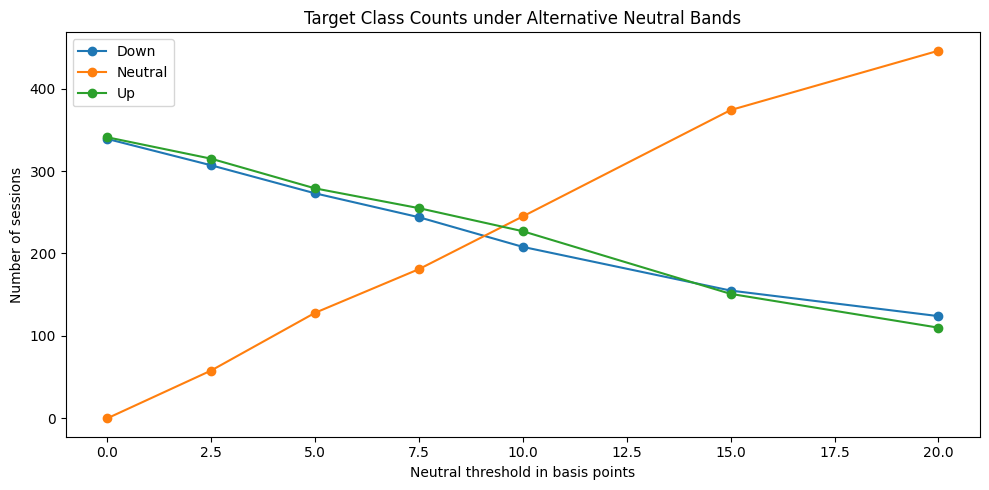

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning\neutral_threshold_sensitivity.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning\figures\neutral_threshold_sensitivity.png


In [38]:
# I use this cell for neutral-threshold sensitivity.
thresholds = [0.0, 0.00025, 0.00050, 0.00075, 0.00100, 0.00150, 0.00200]
rows = []
for threshold in thresholds:
    labels = np.select(
        [clean_daily["final_hour_return"] > threshold, clean_daily["final_hour_return"] < -threshold],
        ["Up", "Down"],
        default="Neutral",
    )
    counts = pd.Series(labels).value_counts()
    up = int(counts.get("Up", 0))
    down = int(counts.get("Down", 0))
    neutral = int(counts.get("Neutral", 0))
    directional = up + down
    rows.append(
        {
            "threshold_return": threshold,
            "threshold_basis_points": threshold * 10_000,
            "Down": down,
            "Neutral": neutral,
            "Up": up,
            "directional_sessions": directional,
            "directional_pct": directional / len(clean_daily) * 100,
            "directional_majority_baseline_pct": max(up, down) / directional * 100 if directional else np.nan,
        }
    )

threshold_sensitivity = pd.DataFrame(rows)
display(threshold_sensitivity)

fig, ax = plt.subplots(figsize=(10, 5))
for label in ["Down", "Neutral", "Up"]:
    ax.plot(threshold_sensitivity["threshold_basis_points"], threshold_sensitivity[label], marker="o", label=label)
ax.set_title("Target Class Counts under Alternative Neutral Bands")
ax.set_xlabel("Neutral threshold in basis points")
ax.set_ylabel("Number of sessions")
ax.legend()
figure_path = save_figure(fig, "neutral_threshold_sensitivity.png")
plt.show()

THRESHOLD_PATH = CLEANING_ROOT / "neutral_threshold_sensitivity.csv"
threshold_sensitivity.to_csv(THRESHOLD_PATH, index=False)
print("Saved:", THRESHOLD_PATH)
print("Saved:", figure_path)

## 8. Feature-definition reconciliation

The following table records the definitions most likely to differ from the original project. Freeze these formulas before comparing new and old model results.

In [39]:
# I use this cell for feature-definition reconciliation.
feature_definition_review = pd.DataFrame(
    [
        ["final_hour_return", "14:59 SPX close to 15:59 SPX close", "Confirm original timestamp convention", "Retain completed-bar convention"],
        ["ret_open_to_1500", "First regular-session SPX open to 14:59 close", "Confirm original cutoff", "Retain current definition"],
        ["ret_last_15m/30m/60m", "Timestamp-window returns ending at 14:59", "Original may use row offsets or 15-minute candles", "Prefer timestamp windows"],
        ["vix_ret_last_15m/30m/60m", "Backward-aligned VIX returns ending at 14:59", "Original may forward-fill", "Retain backward matching"],
        ["realized_volatility", "Square root of sum of squared one-minute log returns", "Check annualisation/scaling", "Document units and freeze definition"],
        ["spy_volume_accel_60m_vs_avg", "Last-60m volume versus earlier-session average minute volume scaled to 60m", "Likely formula difference", "Confirm or rename"],
        ["spy_dist_from_vwap_pct", "14:59 SPY close versus minute-VWAP weighted cumulative VWAP", "Check original VWAP construction", "Validate on sample dates"],
        ["momentum_accel_60m_vs_prior", "Recent 60m return minus preceding 60m return", "Check whether original used slope or ratio", "Retain only with explicit formula"],
        ["atr_open_to_1500", "Mean one-minute true range from open through 14:59", "Not conventional 14-period ATR", "Rename or reproduce original ATR"],
    ],
    columns=["feature", "current_definition", "comparison_issue", "recommended_action"],
)
display(feature_definition_review)
FEATURE_DEFINITION_PATH = CLEANING_ROOT / "feature_definition_review.csv"
feature_definition_review.to_csv(FEATURE_DEFINITION_PATH, index=False)
print("Saved:", FEATURE_DEFINITION_PATH)

,feature,current_definition,comparison_issue,recommended_action
0,final_hour_return,14:59 SPX close to 15:59 SPX close,Confirm original timestamp convention,Retain completed-bar convention
1,ret_open_to_1500,First regular-session SPX open to 14:59 close,Confirm original cutoff,Retain current definition
2,ret_last_15m/30m/60m,Timestamp-window returns ending at 14:59,Original may use row offsets or 15-minute candles,Prefer timestamp windows
3,vix_ret_last_15m/30m/60m,Backward-aligned VIX returns ending at 14:59,Original may forward-fill,Retain backward matching
4,realized_volatility,Square root of sum of squared one-minute log r...,Check annualisation/scaling,Document units and freeze definition
5,spy_volume_accel_60m_vs_avg,Last-60m volume versus earlier-session average...,Likely formula difference,Confirm or rename
6,spy_dist_from_vwap_pct,14:59 SPY close versus minute-VWAP weighted cu...,Check original VWAP construction,Validate on sample dates
7,momentum_accel_60m_vs_prior,Recent 60m return minus preceding 60m return,Check whether original used slope or ratio,Retain only with explicit formula
8,atr_open_to_1500,Mean one-minute true range from open through 1...,Not conventional 14-period ATR,Rename or reproduce original ATR


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\cleaning\feature_definition_review.csv


---
# Part III — Strict and relaxed modelling datasets

The strict and relaxed session-quality rules and chronological split procedure are reproduced from `05_dataset_Splitting.ipynb`.

**Important:** the `Test` label produced inside this extended database is an internal extended-sample robustness segment. It is **not** the protected post-17-Jul-2026 fresh holdout.

## 1. Environment and project discovery

I use the outputs produced by the EDA and cleaning notebooks.

In [40]:
# I use this cell for environment and project discovery.
from pathlib import Path
import json
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data_extended_2023_2026" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data_extended_2023_2026/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"
VARIANT_ROOT = OUTPUT_ROOT / "dataset_variants"
FIGURE_ROOT = VARIANT_ROOT / "figures"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
VARIANT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Variant outputs:", VARIANT_ROOT)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Database: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\market.duckdb
Variant outputs: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants


## 2. Load the aligned and daily datasets

In [41]:
# I use this cell for load the aligned and daily datasets.
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
DAILY_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"


def load_parquet_or_table(path: Path, table_name: str) -> pd.DataFrame:
    if path.exists():
        print("Loading:", path)
        return pd.read_parquet(path)

    available_tables = set(
        con.execute(
            """
            SELECT table_name
            FROM information_schema.tables
            """
        ).df()["table_name"]
    )

    if table_name in available_tables:
        print("Loading DuckDB table:", table_name)
        return con.execute(
            f"SELECT * FROM {table_name}"
        ).df()

    raise FileNotFoundError(
        f"Neither {path} nor DuckDB table {table_name} exists."
    )


aligned = load_parquet_or_table(
    ALIGNED_PATH,
    "aligned_underlyings_1min",
)

daily_model = load_parquet_or_table(
    DAILY_PATH,
    "daily_underlying_model_dataset",
)

aligned["timestamp_utc"] = pd.to_datetime(
    aligned["timestamp_utc"],
    utc=True,
)
aligned["timestamp_et"] = pd.to_datetime(
    aligned["timestamp_et"],
)
aligned["session_date"] = aligned["session_date"].astype(str)

for column in ["spx_timestamp_utc", "vix_timestamp_utc"]:
    if column in aligned.columns:
        aligned[column] = pd.to_datetime(
            aligned[column],
            utc=True,
        )

daily_model["session_date"] = pd.to_datetime(
    daily_model["session_date"],
)

if "feature_cutoff_timestamp_utc" in daily_model.columns:
    daily_model["feature_cutoff_timestamp_utc"] = pd.to_datetime(
        daily_model["feature_cutoff_timestamp_utc"],
        utc=True,
    )

aligned = (
    aligned.drop_duplicates(
        ["session_date", "timestamp_utc"],
        keep="last",
    )
    .sort_values(
        ["session_date", "timestamp_utc"]
    )
    .reset_index(drop=True)
)

daily_model = (
    daily_model.drop_duplicates(
        ["session_date"],
        keep="last",
    )
    .sort_values("session_date")
    .reset_index(drop=True)
)

numeric_columns = daily_model.select_dtypes(
    include=[np.number]
).columns

daily_model[numeric_columns] = daily_model[
    numeric_columns
].replace([np.inf, -np.inf], np.nan)

if "clock_minute" not in aligned.columns:
    aligned["clock_minute"] = (
        aligned["timestamp_et"].dt.hour * 60
        + aligned["timestamp_et"].dt.minute
    )

print("Aligned minute rows:", len(aligned))
print("Aligned sessions:", aligned["session_date"].nunique())
print("Daily rows:", len(daily_model))

Loading: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\aligned_underlyings_1min.parquet
Loading: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset.parquet
Aligned minute rows: 344494
Aligned sessions: 887
Daily rows: 850


## 3. Construct the session-quality audit

The VIX feature endpoints are:

- 13:59 for the 60-minute starting value;
- 14:29 for the 30-minute starting value;
- 14:44 for the 15-minute starting value;
- 14:59 for the common ending value.

At each endpoint, the matched VIX value must come from the same timestamp or an earlier timestamp no more than 120 seconds old.

In [42]:
# I use this cell for construct the session-quality audit.
FULL_SESSION_ROWS = 390
MAX_RELAXED_VIX_GAPS = 5
MAX_VIX_STALENESS_SECONDS = 120

VIX_REQUIRED_ANCHORS = {
    "vix_1359_valid": 13 * 60 + 59,
    "vix_1429_valid": 14 * 60 + 29,
    "vix_1444_valid": 14 * 60 + 44,
    "vix_1459_valid": 14 * 60 + 59,
}


def exact_spx_anchor(
    group: pd.DataFrame,
    minute_of_day: int,
) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]

    if anchor.empty:
        return False

    exact_match = anchor["spx_timestamp_utc"].eq(
        anchor["timestamp_utc"]
    )

    return bool(
        anchor["spx_close"].notna().any()
        and exact_match.any()
    )


def valid_vix_anchor(
    group: pd.DataFrame,
    minute_of_day: int,
) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]

    if anchor.empty:
        return False

    valid_rows = anchor[
        anchor["vix_close"].notna()
        & anchor["vix_timestamp_utc"].notna()
    ].copy()

    if valid_rows.empty:
        return False

    staleness = (
        valid_rows["timestamp_utc"]
        - valid_rows["vix_timestamp_utc"]
    ).dt.total_seconds()

    return bool(
        staleness.ge(0).all()
        and staleness.le(
            MAX_VIX_STALENESS_SECONDS
        ).all()
    )


quality_rows = []

for session_date, group in aligned.groupby("session_date"):
    group = group.sort_values("timestamp_utc")

    final_120m = group[
        group["clock_minute"].between(
            13 * 60,
            14 * 60 + 59,
        )
    ]

    row = {
        "session_date": session_date,
        "rows": len(group),
        "first_time_et": (
            group["timestamp_et"]
            .min()
            .strftime("%H:%M:%S")
        ),
        "last_time_et": (
            group["timestamp_et"]
            .max()
            .strftime("%H:%M:%S")
        ),
        "exact_spx_1459": exact_spx_anchor(
            group,
            14 * 60 + 59,
        ),
        "exact_spx_1559": exact_spx_anchor(
            group,
            15 * 60 + 59,
        ),
        "missing_spx_final_120m": int(
            final_120m["spx_close"].isna().sum()
        ),
        "missing_vix_final_120m": int(
            final_120m["vix_close"].isna().sum()
        ),
        "max_vix_staleness_final_120m": (
            final_120m["vix_staleness_seconds"].max()
        ),
    }

    for column_name, minute_of_day in VIX_REQUIRED_ANCHORS.items():
        row[column_name] = valid_vix_anchor(
            group,
            minute_of_day,
        )

    quality_rows.append(row)

session_quality = pd.DataFrame(quality_rows)

session_quality["strict_eligible"] = (
    session_quality["rows"].eq(FULL_SESSION_ROWS)
    & session_quality["exact_spx_1459"]
    & session_quality["exact_spx_1559"]
    & session_quality["missing_spx_final_120m"].eq(0)
    & session_quality["missing_vix_final_120m"].eq(0)
)

required_vix_columns = list(
    VIX_REQUIRED_ANCHORS.keys()
)

session_quality["relaxed_eligible"] = (
    session_quality["rows"].eq(FULL_SESSION_ROWS)
    & session_quality["exact_spx_1459"]
    & session_quality["exact_spx_1559"]
    & session_quality["missing_spx_final_120m"].eq(0)
    & session_quality["missing_vix_final_120m"].le(
        MAX_RELAXED_VIX_GAPS
    )
    & session_quality[
        required_vix_columns
    ].all(axis=1)
)

assert not (
    session_quality["strict_eligible"]
    & ~session_quality["relaxed_eligible"]
).any(), (
    "Every strict session should also satisfy the relaxed rule."
)

display(
    session_quality[
        [
            "strict_eligible",
            "relaxed_eligible",
        ]
    ]
    .value_counts()
    .rename("sessions")
    .reset_index()
)

SESSION_QUALITY_PATH = (
    VARIANT_ROOT
    / "strict_relaxed_session_quality.csv"
)

session_quality.to_csv(
    SESSION_QUALITY_PATH,
    index=False,
)

print("Saved:", SESSION_QUALITY_PATH)

,strict_eligible,relaxed_eligible,sessions
0,True,True,681
1,False,True,130
2,False,False,76


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\strict_relaxed_session_quality.csv


## 4. Explain exclusion reasons

This table makes every inclusion and exclusion reproducible.

In [43]:
# I use this cell for explain exclusion reasons.
def strict_exclusion_reason(row) -> str:
    reasons = []

    if row["rows"] != FULL_SESSION_ROWS:
        reasons.append(
            f"session length {int(row['rows'])}"
        )

    if not row["exact_spx_1459"]:
        reasons.append("no exact SPX 14:59")

    if not row["exact_spx_1559"]:
        reasons.append("no exact SPX 15:59")

    if row["missing_spx_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_spx_final_120m'])} "
            "missing SPX observations in final 120m"
        )

    if row["missing_vix_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_vix_final_120m'])} "
            "missing VIX observations in final 120m"
        )

    return "; ".join(reasons) if reasons else "eligible"


def relaxed_exclusion_reason(row) -> str:
    reasons = []

    if row["rows"] != FULL_SESSION_ROWS:
        reasons.append(
            f"session length {int(row['rows'])}"
        )

    if not row["exact_spx_1459"]:
        reasons.append("no exact SPX 14:59")

    if not row["exact_spx_1559"]:
        reasons.append("no exact SPX 15:59")

    if row["missing_spx_final_120m"] > 0:
        reasons.append(
            f"{int(row['missing_spx_final_120m'])} "
            "missing SPX observations in final 120m"
        )

    if (
        row["missing_vix_final_120m"]
        > MAX_RELAXED_VIX_GAPS
    ):
        reasons.append(
            f"{int(row['missing_vix_final_120m'])} "
            "missing VIX observations exceeds relaxed limit"
        )

    invalid_anchors = [
        column
        for column in required_vix_columns
        if not bool(row[column])
    ]

    if invalid_anchors:
        reasons.append(
            "invalid VIX feature endpoints: "
            + ", ".join(invalid_anchors)
        )

    return "; ".join(reasons) if reasons else "eligible"


session_quality["strict_reason"] = session_quality.apply(
    strict_exclusion_reason,
    axis=1,
)

session_quality["relaxed_reason"] = session_quality.apply(
    relaxed_exclusion_reason,
    axis=1,
)

relaxed_only_sessions = session_quality[
    session_quality["relaxed_eligible"]
    & ~session_quality["strict_eligible"]
].copy()

excluded_from_both = session_quality[
    ~session_quality["relaxed_eligible"]
].copy()

print("Relaxed-only sessions:", len(relaxed_only_sessions))
display(
    relaxed_only_sessions[
        [
            "session_date",
            "missing_vix_final_120m",
            "max_vix_staleness_final_120m",
            *required_vix_columns,
            "strict_reason",
        ]
    ].sort_values("session_date")
)

print("Excluded from both variants:", len(excluded_from_both))
display(
    excluded_from_both[
        [
            "session_date",
            "rows",
            "missing_spx_final_120m",
            "missing_vix_final_120m",
            "exact_spx_1459",
            "exact_spx_1559",
            "relaxed_reason",
        ]
    ].sort_values("session_date")
)

RELAXED_ONLY_PATH = (
    VARIANT_ROOT
    / "relaxed_only_sessions.csv"
)

EXCLUDED_BOTH_PATH = (
    VARIANT_ROOT
    / "excluded_from_both_variants.csv"
)

relaxed_only_sessions.to_csv(
    RELAXED_ONLY_PATH,
    index=False,
)

excluded_from_both.to_csv(
    EXCLUDED_BOTH_PATH,
    index=False,
)

print("Saved:", RELAXED_ONLY_PATH)
print("Saved:", EXCLUDED_BOTH_PATH)

Relaxed-only sessions: 130


,session_date,missing_vix_final_120m,max_vix_staleness_final_120m,vix_1359_valid,vix_1429_valid,vix_1444_valid,vix_1459_valid,strict_reason
69,2023-04-13,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
110,2023-06-12,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
111,2023-06-13,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m
123,2023-06-30,4,120.000000,True,True,True,True,4 missing VIX observations in final 120m
125,2023-07-05,4,120.000000,True,True,True,True,4 missing VIX observations in final 120m
...,...,...,...,...,...,...,...,...
855,2026-06-02,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
857,2026-06-04,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
864,2026-06-15,2,120.000000,True,True,True,True,2 missing VIX observations in final 120m
880,2026-07-09,1,120.000000,True,True,True,True,1 missing VIX observations in final 120m


Excluded from both variants: 76


,session_date,rows,missing_spx_final_120m,missing_vix_final_120m,exact_spx_1459,exact_spx_1559,relaxed_reason
0,2023-01-03,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
1,2023-01-04,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
2,2023-01-05,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
3,2023-01-06,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
4,2023-01-09,390,120,120,False,False,no exact SPX 14:59; no exact SPX 15:59; 120 mi...
...,...,...,...,...,...,...,...
703,2025-10-22,390,0,7,True,True,7 missing VIX observations exceeds relaxed limit
706,2025-10-27,390,0,3,True,True,invalid VIX feature endpoints: vix_1359_valid
729,2025-11-28,211,0,0,False,False,session length 211; no exact SPX 14:59; no exa...
746,2025-12-23,390,0,5,True,True,invalid VIX feature endpoints: vix_1429_valid


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\relaxed_only_sessions.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\excluded_from_both_variants.csv


## 5. Build the two daily datasets

Both datasets:

- remove missing and non-finite targets;
- remove exact zero-return sessions from the binary target;
- use `target_up = 1` for Up and `target_up = 0` for Down;
- retain the original untransformed feature values.

In [44]:
# I use this cell for build the two daily datasets.
def build_variant(
    source: pd.DataFrame,
    eligible_dates: set[str],
    variant_name: str,
) -> pd.DataFrame:
    frame = source[
        source["session_date"]
        .dt.strftime("%Y-%m-%d")
        .isin(eligible_dates)
    ].copy()

    frame = frame[
        frame["final_hour_return"].notna()
    ].copy()

    frame = frame[
        np.isfinite(
            frame["final_hour_return"]
        )
    ].copy()

    frame = frame[
        ~frame["final_hour_return"].eq(0)
    ].copy()

    frame["target_up"] = (
        frame["final_hour_return"] > 0
    ).astype("int8")

    frame["final_hour_direction_binary"] = np.where(
        frame["target_up"].eq(1),
        "Up",
        "Down",
    )

    frame["dataset_variant"] = variant_name

    return (
        frame.sort_values("session_date")
        .reset_index(drop=True)
    )


strict_dates = set(
    session_quality.loc[
        session_quality["strict_eligible"],
        "session_date",
    ]
)

relaxed_dates = set(
    session_quality.loc[
        session_quality["relaxed_eligible"],
        "session_date",
    ]
)

strict_dataset = build_variant(
    daily_model,
    strict_dates,
    "strict",
)

relaxed_dataset = build_variant(
    daily_model,
    relaxed_dates,
    "relaxed",
)

strict_session_dates = set(
    strict_dataset["session_date"]
)

relaxed_session_dates = set(
    relaxed_dataset["session_date"]
)

assert strict_session_dates.issubset(
    relaxed_session_dates
)

variant_summary = pd.DataFrame(
    [
        {
            "dataset_variant": "strict",
            "rows": len(strict_dataset),
            "first_date": strict_dataset["session_date"].min(),
            "last_date": strict_dataset["session_date"].max(),
            "up_sessions": int(
                strict_dataset["target_up"].sum()
            ),
            "down_sessions": int(
                strict_dataset["target_up"].eq(0).sum()
            ),
        },
        {
            "dataset_variant": "relaxed",
            "rows": len(relaxed_dataset),
            "first_date": relaxed_dataset["session_date"].min(),
            "last_date": relaxed_dataset["session_date"].max(),
            "up_sessions": int(
                relaxed_dataset["target_up"].sum()
            ),
            "down_sessions": int(
                relaxed_dataset["target_up"].eq(0).sum()
            ),
        },
    ]
)

variant_summary["additional_rows_vs_strict"] = (
    variant_summary["rows"]
    - len(strict_dataset)
)

display(variant_summary)

STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed.parquet"
)

strict_dataset.to_parquet(
    STRICT_PATH,
    index=False,
)

relaxed_dataset.to_parquet(
    RELAXED_PATH,
    index=False,
)

VARIANT_SUMMARY_PATH = (
    VARIANT_ROOT
    / "variant_summary.csv"
)

variant_summary.to_csv(
    VARIANT_SUMMARY_PATH,
    index=False,
)

print("Saved:", STRICT_PATH)
print("Saved:", RELAXED_PATH)
print("Saved:", VARIANT_SUMMARY_PATH)

,dataset_variant,rows,first_date,last_date,up_sessions,down_sessions,additional_rows_vs_strict
0,strict,680,2023-02-15,2026-07-17,341,339,0
1,relaxed,810,2023-02-15,2026-07-17,402,408,130


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_strict.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_relaxed.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\variant_summary.csv


## 6. Compare target balance and missingness

A relaxed dataset should add observations without creating new missing daily feature values.

,dataset_variant,rows,feature_missing_values,up_pct,down_pct,mean_final_hour_return,final_hour_return_std
0,strict,680,0,50.147059,49.852941,-0.000087,0.003039
1,relaxed,810,0,49.629630,50.370370,-0.000082,0.002873


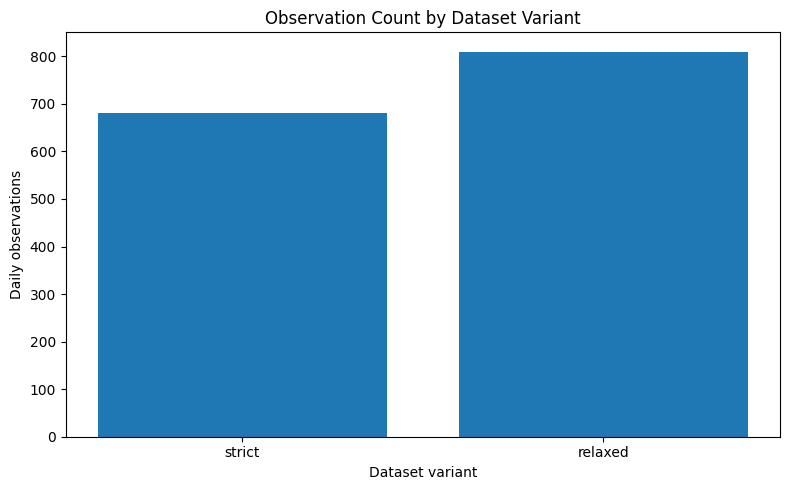

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\variant_target_and_missingness_comparison.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\figures\strict_relaxed_observation_counts.png


In [45]:
# I use this cell for compare target balance and missingness.
identifier_columns = {
    "session_date",
    "feature_cutoff_timestamp_utc",
    "final_hour_direction",
    "final_hour_direction_binary",
    "target_up",
    "day_of_week", 
    "month",
    "dataset_variant",
}

target_columns = {
    "final_hour_return",
    "spx_at_close",
}

feature_columns = [
    column
    for column in strict_dataset.columns
    if column not in identifier_columns
    and column not in target_columns
    and pd.api.types.is_numeric_dtype(
        strict_dataset[column]
    )
]

comparison_rows = []

for name, frame in [
    ("strict", strict_dataset),
    ("relaxed", relaxed_dataset),
]:
    comparison_rows.append(
        {
            "dataset_variant": name,
            "rows": len(frame),
            "feature_missing_values": int(
                frame[feature_columns]
                .isna()
                .sum()
                .sum()
            ),
            "up_pct": float(
                frame["target_up"].mean() * 100
            ),
            "down_pct": float(
                frame["target_up"].eq(0).mean() * 100
            ),
            "mean_final_hour_return": float(
                frame["final_hour_return"].mean()
            ),
            "final_hour_return_std": float(
                frame["final_hour_return"].std()
            ),
        }
    )

variant_comparison = pd.DataFrame(
    comparison_rows
)

display(variant_comparison)

VARIANT_COMPARISON_PATH = (
    VARIANT_ROOT
    / "variant_target_and_missingness_comparison.csv"
)

variant_comparison.to_csv(
    VARIANT_COMPARISON_PATH,
    index=False,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    variant_summary["dataset_variant"],
    variant_summary["rows"],
)
ax.set_title("Observation Count by Dataset Variant")
ax.set_xlabel("Dataset variant")
ax.set_ylabel("Daily observations")
figure_path = save_figure(
    fig,
    "strict_relaxed_observation_counts.png",
)
plt.show()

print("Saved:", VARIANT_COMPARISON_PATH)
print("Saved:", figure_path)

## 7. Create common chronological split boundaries

The strict dataset determines the calendar cutoffs. Those exact dates are then applied to both variants.

This prevents the relaxed dataset from receiving later training or validation dates merely because it contains more observations.

In [46]:
# I use this cell for create common chronological split boundaries.
TRAIN_PROPORTION = 0.70
VALIDATION_PROPORTION = 0.15

strict_sorted = strict_dataset.sort_values(
    "session_date"
).reset_index(drop=True)

strict_rows = len(strict_sorted)

strict_train_end = int(
    np.floor(
        strict_rows * TRAIN_PROPORTION
    )
)

strict_validation_end = int(
    np.floor(
        strict_rows
        * (
            TRAIN_PROPORTION
            + VALIDATION_PROPORTION
        )
    )
)

if (
    strict_train_end < 1
    or strict_validation_end <= strict_train_end
    or strict_validation_end >= strict_rows
):
    raise RuntimeError(
        "The strict dataset is too small for the requested split."
    )

TRAIN_END_DATE = strict_sorted.loc[
    strict_train_end - 1,
    "session_date",
]

VALIDATION_END_DATE = strict_sorted.loc[
    strict_validation_end - 1,
    "session_date",
]

print("Common train end date:", TRAIN_END_DATE.date())
print(
    "Common validation end date:",
    VALIDATION_END_DATE.date(),
)


def apply_common_split(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    result = frame.copy()

    result["data_split"] = np.select(
        [
            result["session_date"].le(
                TRAIN_END_DATE
            ),
            result["session_date"].le(
                VALIDATION_END_DATE
            ),
        ],
        [
            "Train",
            "Validation",
        ],
        default="Test",
    )

    return result


strict_split = apply_common_split(
    strict_dataset
)

relaxed_split = apply_common_split(
    relaxed_dataset
)

split_rows = []

for variant_name, frame in [
    ("strict", strict_split),
    ("relaxed", relaxed_split),
]:
    for split_name in [
        "Train",
        "Validation",
        "Test",
    ]:
        subset = frame[
            frame["data_split"].eq(
                split_name
            )
        ]

        split_rows.append(
            {
                "dataset_variant": variant_name,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": (
                    subset["session_date"].min()
                    if len(subset)
                    else pd.NaT
                ),
                "last_date": (
                    subset["session_date"].max()
                    if len(subset)
                    else pd.NaT
                ),
                "up_sessions": int(
                    subset["target_up"].sum()
                ),
                "down_sessions": int(
                    subset["target_up"].eq(0).sum()
                ),
                "mean_final_hour_return": (
                    subset["final_hour_return"].mean()
                ),
                "final_hour_return_std": (
                    subset["final_hour_return"].std()
                ),
            }
        )

split_summary = pd.DataFrame(split_rows)

display(split_summary)

for frame in [strict_split, relaxed_split]:
    assert (
        frame.loc[
            frame["data_split"].eq("Train"),
            "session_date",
        ].max()
        <
        frame.loc[
            frame["data_split"].eq("Validation"),
            "session_date",
        ].min()
    )

    assert (
        frame.loc[
            frame["data_split"].eq("Validation"),
            "session_date",
        ].max()
        <
        frame.loc[
            frame["data_split"].eq("Test"),
            "session_date",
        ].min()
    )

STRICT_SPLIT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_SPLIT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

SPLIT_SUMMARY_PATH = (
    VARIANT_ROOT
    / "common_calendar_split_summary.csv"
)

strict_split.to_parquet(
    STRICT_SPLIT_PATH,
    index=False,
)

relaxed_split.to_parquet(
    RELAXED_SPLIT_PATH,
    index=False,
)

split_summary.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False,
)

print("Saved:", STRICT_SPLIT_PATH)
print("Saved:", RELAXED_SPLIT_PATH)
print("Saved:", SPLIT_SUMMARY_PATH)

Common train end date: 2025-07-25
Common validation end date: 2026-01-28


,dataset_variant,data_split,sessions,first_date,last_date,up_sessions,down_sessions,mean_final_hour_return,final_hour_return_std
0,strict,Train,475,2023-02-15,2025-07-25,237,238,-0.000108,0.003249
1,strict,Validation,103,2025-07-28,2026-01-28,47,56,-0.000280,0.002208
2,strict,Test,102,2026-01-29,2026-07-17,57,45,0.000206,0.002738
3,relaxed,Train,571,2023-02-15,2025-07-25,281,290,-0.000104,0.003063
4,relaxed,Validation,122,2025-07-28,2026-01-28,54,68,-0.000292,0.002067
5,relaxed,Test,117,2026-01-29,2026-07-17,67,50,0.000248,0.002618


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_strict_split.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_relaxed_split.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\dataset_variants\common_calendar_split_summary.csv


## 8. Verify look-ahead safety and feature completeness

Both datasets must preserve the 14:59 ET feature cutoff and the original target formula.

In [47]:
# I use this cell for verify look-ahead safety and feature completeness.
def verify_variant(
    frame: pd.DataFrame,
    variant_name: str,
) -> None:
    assert not frame.duplicated(
        ["session_date"]
    ).any()

    if "feature_cutoff_timestamp_utc" in frame.columns:
        cutoff_et = (
            frame["feature_cutoff_timestamp_utc"]
            .dt.tz_convert(
                "America/New_York"
            )
            .dt.strftime("%H:%M:%S")
        )

        assert set(cutoff_et) == {
            "14:59:00"
        }

    target_check = np.isclose(
        frame["final_hour_return"],
        (
            frame["spx_at_close"]
            / frame["spx_at_1500"]
            - 1
        ),
    )

    assert target_check.all()

    missing_features = int(
        frame[feature_columns]
        .isna()
        .sum()
        .sum()
    )

    non_finite_features = int(
        (
            ~np.isfinite(
                frame[feature_columns]
                .to_numpy(dtype=float)
            )
        ).sum()
    )

    print(
        variant_name,
        {
            "rows": len(frame),
            "missing_features": missing_features,
            "non_finite_features": non_finite_features,
        },
    )

    assert missing_features == 0
    assert non_finite_features == 0


verify_variant(
    strict_split,
    "strict",
)

verify_variant(
    relaxed_split,
    "relaxed",
)

print("All variant checks passed.")

strict {'rows': 680, 'missing_features': 0, 'non_finite_features': 0}
relaxed {'rows': 810, 'missing_features': 0, 'non_finite_features': 0}
All variant checks passed.


## 9. Export the variant manifest

The manifest freezes the two eligibility rules and common split boundaries before modelling begins.

In [48]:
# I use this cell for export the variant manifest.
variant_manifest = {
    "strict_rule": {
        "regular_session_rows": FULL_SESSION_ROWS,
        "exact_spx_1459": True,
        "exact_spx_1559": True,
        "maximum_missing_spx_final_120m": 0,
        "maximum_missing_vix_final_120m": 0,
    },
    "relaxed_rule": {
        "regular_session_rows": FULL_SESSION_ROWS,
        "exact_spx_1459": True,
        "exact_spx_1559": True,
        "maximum_missing_spx_final_120m": 0,
        "maximum_missing_vix_final_120m": (
            MAX_RELAXED_VIX_GAPS
        ),
        "required_vix_anchor_times_et": [
            "13:59:00",
            "14:29:00",
            "14:44:00",
            "14:59:00",
        ],
        "maximum_vix_anchor_staleness_seconds": (
            MAX_VIX_STALENESS_SECONDS
        ),
    },
    "target": (
        "Binary Up/Down based on sign of "
        "14:59-to-15:59 SPX return"
    ),
    "common_split_dates": {
        "train_end_date": (
            TRAIN_END_DATE.strftime("%Y-%m-%d")
        ),
        "validation_end_date": (
            VALIDATION_END_DATE.strftime("%Y-%m-%d")
        ),
        "test_start_date": (
            (
                VALIDATION_END_DATE
                + pd.Timedelta(days=1)
            ).strftime("%Y-%m-%d")
        ),
    },
    "strict_rows": int(
        len(strict_split)
    ),
    "relaxed_rows": int(
        len(relaxed_split)
    ),
    "relaxed_additional_rows": int(
        len(relaxed_split)
        - len(strict_split)
    ),
    "preprocessing_applied": False,
    "strict_split_path": str(
        STRICT_SPLIT_PATH
    ),
    "relaxed_split_path": str(
        RELAXED_SPLIT_PATH
    ),
}

MANIFEST_PATH = (
    VARIANT_ROOT
    / "dataset_variant_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        variant_manifest,
        manifest_file,
        indent=2,
    )

print(
    json.dumps(
        variant_manifest,
        indent=2,
    )
)

print("Saved:", MANIFEST_PATH)

{
  "strict_rule": {
    "regular_session_rows": 390,
    "exact_spx_1459": true,
    "exact_spx_1559": true,
    "maximum_missing_spx_final_120m": 0,
    "maximum_missing_vix_final_120m": 0
  },
  "relaxed_rule": {
    "regular_session_rows": 390,
    "exact_spx_1459": true,
    "exact_spx_1559": true,
    "maximum_missing_spx_final_120m": 0,
    "maximum_missing_vix_final_120m": 5,
    "required_vix_anchor_times_et": [
      "13:59:00",
      "14:29:00",
      "14:44:00",
      "14:59:00"
    ],
    "maximum_vix_anchor_staleness_seconds": 120
  },
  "target": "Binary Up/Down based on sign of 14:59-to-15:59 SPX return",
  "common_split_dates": {
    "train_end_date": "2025-07-25",
    "validation_end_date": "2026-01-28",
    "test_start_date": "2026-01-29"
  },
  "strict_rows": 680,
  "relaxed_rows": 810,
  "relaxed_additional_rows": 130,
  "preprocessing_applied": false,
  "strict_split_path": "C:\\Users\\hkhat\\OneDrive\\Desktop\\Project\\Dissertation\\data_extended_2023_2026\\deriv

## 10. Decision before modelling

Next, I move to:

```text
notebooks/06_modeling_baseline.ipynb
```

It should run the **same models, features, preprocessing pipeline, cross-validation procedure and probability threshold** on both dataset variants.

The preferred dataset variant must be chosen using training and validation results only. The test period must not determine whether the strict or relaxed cleaning rule is selected.

Recommended comparison criteria:

- expanding-window validation accuracy and balanced accuracy;
- ROC-AUC and log loss;
- stability across validation folds;
- calibration;
- coefficient or feature-importance stability;
- sensitivity of conclusions to the added relaxed sessions.

If the relaxed dataset improves sample size without materially reducing validation stability, it can become the primary dataset and the strict sample can serve as a robustness check. If the relaxed observations weaken results substantially or create unstable estimates, the strict sample should remain primary.

---
# Part IV — Baseline RQ1–RQ3 modelling on the longer sample

The baseline model library and validation comparisons are reproduced from `06_modeling_baseline.ipynb`.

The original notebook's final-test evaluation section is deliberately **omitted** here. This combined notebook stops after development/validation conclusions so that it cannot silently convert the extended robustness exercise into another test-set optimisation loop.

## 1. Environment and project discovery

I use scikit-learn models only so this stage remains portable.

In [49]:
# I use this cell for environment and project discovery.
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data_extended_2023_2026" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data_extended_2023_2026/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"
MODEL_ROOT = OUTPUT_ROOT / "baseline_models"
FIGURE_ROOT = MODEL_ROOT / "figures"
TABLE_ROOT = MODEL_ROOT / "tables"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model output:", MODEL_ROOT)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Model output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models


## 2. Load strict and relaxed split datasets

In [50]:
# I use this cell for load strict and relaxed split datasets.
STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

if not STRICT_PATH.exists() or not RELAXED_PATH.exists():
    raise FileNotFoundError(
        "Run notebooks/05_dataset_Splitting.ipynb first."
    )


def load_variant(path: Path, expected_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "data_split",
        "final_hour_return",
        "target_up",
    }

    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"{expected_name} is missing columns: {sorted(missing)}"
        )

    return frame


strict_data = load_variant(STRICT_PATH, "strict")
relaxed_data = load_variant(RELAXED_PATH, "relaxed")

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

coverage_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        coverage_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": subset["session_date"].min(),
                "last_date": subset["session_date"].max(),
                "up_sessions": int(subset["target_up"].sum()),
                "down_sessions": int(subset["target_up"].eq(0).sum()),
            }
        )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

assert (
    strict_data.loc[
        strict_data["data_split"].eq("Train"),
        "session_date",
    ].max()
    ==
    relaxed_data.loc[
        relaxed_data["data_split"].eq("Train"),
        "session_date",
    ].max()
)

assert (
    strict_data.loc[
        strict_data["data_split"].eq("Validation"),
        "session_date",
    ].max()
    ==
    relaxed_data.loc[
        relaxed_data["data_split"].eq("Validation"),
        "session_date",
    ].max()
)

print("Common calendar boundaries verified.")

,dataset_variant,data_split,sessions,first_date,last_date,up_sessions,down_sessions
0,Strict,Train,475,2023-02-15,2025-07-25,237,238
1,Strict,Validation,103,2025-07-28,2026-01-28,47,56
2,Strict,Test,102,2026-01-29,2026-07-17,57,45
3,Relaxed,Train,571,2023-02-15,2025-07-25,281,290
4,Relaxed,Validation,122,2025-07-28,2026-01-28,54,68
5,Relaxed,Test,117,2026-01-29,2026-07-17,67,50


Common calendar boundaries verified.


## 3. Freeze the feature set

The modelling features exclude:

- target-construction variables such as `spx_at_close`;
- raw market levels such as `spx_at_1500` and `spy_at_1500`;
- data-quality counters;
- the exact duplicate `dist_from_open_pct`;
- the highly redundant `spy_ret_open_to_1500`.

ATR is converted from index points to a percentage of SPX at the cutoff.

The same features are used for both dataset variants and all three research questions.

In [51]:
BASE_FEATURES = [
    # SPX momentum
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",

    # VIX state and movement
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",

    # Realised volatility
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",

    # SPY volume and VWAP
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",

    # Intraday price positioning
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",

    # Derived percentage ATR
    "atr_pct_open_to_1500",
]

FEATURE_GROUPS = {
    "Momentum": [
        "ret_open_to_1500",
        "ret_last_15m",
        "ret_last_30m",
        "ret_last_60m",
        "momentum_accel_60m_vs_prior",
    ],
    "VIX": [
        "vix_level_1500",
        "vix_ret_last_15m",
        "vix_ret_last_30m",
        "vix_ret_last_60m",
    ],
    "Volatility": [
        "realized_vol_30m",
        "realized_vol_60m",
        "realized_vol_120m",
        "rv_open_to_1500",
        "atr_pct_open_to_1500",
    ],
    "Volume and VWAP": [
        "spy_volume_last_30m",
        "spy_volume_last_60m",
        "spy_cum_volume_to_1500",
        "spy_volume_accel_60m_vs_avg",
        "spy_dist_from_vwap_pct",
    ],
    "Price positioning": [
        "position_in_day_range",
        "dist_from_day_high_pct",
        "dist_from_day_low_pct",
    ],
}


def prepare_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()

    result["atr_pct_open_to_1500"] = (
        result["atr_open_to_1500"]
        / result["spx_at_1500"]
    )

    missing = set(BASE_FEATURES).difference(result.columns)

    if missing:
        raise ValueError(
            f"Missing modelling features: {sorted(missing)}"
        )

    result[BASE_FEATURES] = result[
        BASE_FEATURES
    ].replace([np.inf, -np.inf], np.nan)

    return result


datasets = {
    variant: prepare_features(frame)
    for variant, frame in datasets.items()
}

feature_audit = pd.DataFrame(
    {
        "feature": BASE_FEATURES,
        "strict_missing": [
            int(strict_data.get(feature, pd.Series(dtype=float)).isna().sum())
            if feature in strict_data.columns
            else np.nan
            for feature in BASE_FEATURES
        ],
        "feature_group": [
            next(
                group
                for group, group_features in FEATURE_GROUPS.items()
                if feature in group_features
            )
            for feature in BASE_FEATURES
        ],
    }
)

display(feature_audit)
print("Number of features:", len(BASE_FEATURES))

,feature,strict_missing,feature_group
0,ret_open_to_1500,0.000000,Momentum
1,ret_last_15m,0.000000,Momentum
2,ret_last_30m,0.000000,Momentum
3,ret_last_60m,0.000000,Momentum
4,momentum_accel_60m_vs_prior,0.000000,Momentum
5,vix_level_1500,0.000000,VIX
6,vix_ret_last_15m,0.000000,VIX
7,vix_ret_last_30m,0.000000,VIX
8,vix_ret_last_60m,0.000000,VIX
9,realized_vol_30m,0.000000,Volatility


Number of features: 22


## 4. Define the three targets

### RQ1 target

`target_up`: 1 for Up and 0 for Down.

### RQ2 target

Absolute final-hour return expressed in basis points.

### RQ3 target

A large movement is an absolute final-hour return at or above the 75th percentile of the strict training period. This threshold is frozen and applied to every split and both dataset variants.

In [52]:
# I use this cell for define the three targets.
LARGE_MOVE_QUANTILE = 0.75

strict_train_returns = strict_data.loc[
    strict_data["data_split"].eq("Train"),
    "final_hour_return",
].abs()

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_train_returns.quantile(
        LARGE_MOVE_QUANTILE
    )
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

for variant, frame in datasets.items():
    frame["target_magnitude_bps"] = (
        frame["final_hour_return"].abs() * 10_000
    )

    frame["target_large_move"] = (
        frame["final_hour_return"].abs()
        >= LARGE_MOVE_THRESHOLD_RETURN
    ).astype("int8")

target_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        target_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "up_pct": subset["target_up"].mean() * 100,
                "mean_magnitude_bps": subset[
                    "target_magnitude_bps"
                ].mean(),
                "large_move_sessions": int(
                    subset["target_large_move"].sum()
                ),
                "large_move_pct": (
                    subset["target_large_move"].mean() * 100
                ),
            }
        )

target_summary = pd.DataFrame(target_rows)

print(
    f"Large-movement threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.2f} basis points"
)
display(target_summary)

Large-movement threshold: 27.58 basis points


,dataset_variant,data_split,sessions,up_pct,mean_magnitude_bps,large_move_sessions,large_move_pct
0,Strict,Train,475,49.894737,21.470158,119,25.052632
1,Strict,Validation,103,45.631068,15.831260,17,16.504854
2,Strict,Test,102,55.882353,19.687294,23,22.549020
3,Relaxed,Train,571,49.211909,20.145064,129,22.591944
4,Relaxed,Validation,122,44.262295,14.706285,17,13.934426
5,Relaxed,Test,117,57.264957,18.788756,24,20.512821


## 5. Model libraries

The model set deliberately spans several modelling assumptions:

- naive baselines;
- linear and regularised models;
- distance-based models;
- kernel methods;
- probabilistic models;
- single trees;
- bagging ensembles;
- boosting ensembles;
- a small neural network.

Hyperparameters are deliberately modest because this is a baseline comparison rather than an exhaustive search.

In [53]:
# I use this cell for model libraries.
def scaled_classifier(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_classifier(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


def scaled_regressor(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_regressor(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


CLASSIFICATION_MODELS = {
    "Dummy Majority": unscaled_classifier(
        DummyClassifier(strategy="most_frequent")
    ),
    "Logistic L1": scaled_classifier(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Logistic L2": scaled_classifier(
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Logistic ElasticNet": scaled_classifier(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.5,
            class_weight="balanced",
            max_iter=4_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Gaussian Naive Bayes": scaled_classifier(
        GaussianNB()
    ),
    "K-Nearest Neighbours": scaled_classifier(
        KNeighborsClassifier(
            n_neighbors=15,
            weights="distance",
        )
    ),
    "RBF SVC": scaled_classifier(
        SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "Decision Tree": unscaled_classifier(
        DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": unscaled_classifier(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Extra Trees": unscaled_classifier(
        ExtraTreesClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "AdaBoost": unscaled_classifier(
        AdaBoostClassifier(
            n_estimators=150,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    ),
    "Gradient Boosting": unscaled_classifier(
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=8,
            random_state=RANDOM_STATE,
        )
    ),
    "Histogram Gradient Boosting": unscaled_classifier(
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=12,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
    ),
    "MLP Neural Network": scaled_classifier(
        MLPClassifier(
            hidden_layer_sizes=(24, 12),
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=1_500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )
    ),
}


REGRESSION_MODELS = {
    "Dummy Median": unscaled_regressor(
        DummyRegressor(strategy="median")
    ),
    "Ridge Regression": scaled_regressor(
        Ridge(alpha=10.0)
    ),
    "Lasso Regression": scaled_regressor(
        Lasso(
            alpha=0.05,
            max_iter=10_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Elastic Net": scaled_regressor(
        ElasticNet(
            alpha=0.05,
            l1_ratio=0.5,
            max_iter=10_000,
            random_state=RANDOM_STATE,
        )
    ),
    "RBF SVR": scaled_regressor(
        SVR(
            C=10.0,
            epsilon=1.0,
            kernel="rbf",
            gamma="scale",
        )
    ),
    "K-Nearest Neighbours": scaled_regressor(
        KNeighborsRegressor(
            n_neighbors=15,
            weights="distance",
        )
    ),
    "Decision Tree": unscaled_regressor(
        DecisionTreeRegressor(
            max_depth=4,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": unscaled_regressor(
        RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Extra Trees": unscaled_regressor(
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Gradient Boosting": unscaled_regressor(
        GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=8,
            loss="huber",
            random_state=RANDOM_STATE,
        )
    ),
    "Histogram Gradient Boosting": unscaled_regressor(
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=12,
            l2_regularization=1.0,
            loss="absolute_error",
            random_state=RANDOM_STATE,
        )
    ),
}

print("Classification models:", len(CLASSIFICATION_MODELS))
print("Regression models:", len(REGRESSION_MODELS))

Classification models: 14
Regression models: 11


## 6. Evaluation functions

Training performance is estimated using five expanding folds. Each model is then refitted on the complete training period and evaluated on the fixed validation period.

In [54]:
# I use this cell for evaluation functions.
N_TIME_SERIES_SPLITS = 5


def probability_predictions(model, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)
        return probabilities[:, 1]

    if hasattr(model, "decision_function"):
        return expit(model.decision_function(X))

    return model.predict(X).astype(float)


def safe_auc(y_true, y_probability) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        roc_auc_score(y_true, y_probability)
    )


def safe_average_precision(y_true, y_probability) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        average_precision_score(
            y_true,
            y_probability,
        )
    )


def classification_metrics(
    y_true,
    y_pred,
    y_probability,
) -> dict:
    clipped_probability = np.clip(
        y_probability,
        1e-6,
        1 - 1e-6,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": safe_auc(
            y_true,
            y_probability,
        ),
        "average_precision": safe_average_precision(
            y_true,
            y_probability,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            y_pred,
        ),
        "brier": brier_score_loss(
            y_true,
            clipped_probability,
        ),
        "log_loss": log_loss(
            y_true,
            np.column_stack(
                [
                    1 - clipped_probability,
                    clipped_probability,
                ]
            ),
            labels=[0, 1],
        ),
    }


def regression_metrics(
    y_true,
    y_pred,
) -> dict:
    correlation = spearmanr(
        y_true,
        y_pred,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
        "spearman": correlation,
    }


def classification_benchmark(
    frame: pd.DataFrame,
    variant_name: str,
    target_column: str,
    task_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    X_train = train[BASE_FEATURES]
    y_train = train[target_column].astype(int)

    X_validation = validation[BASE_FEATURES]
    y_validation = validation[target_column].astype(int)

    splitter = TimeSeriesSplit(
        n_splits=N_TIME_SERIES_SPLITS
    )

    rows = []

    for model_name, model_template in CLASSIFICATION_MODELS.items():
        fold_metrics = []

        for fold_number, (fit_index, fold_index) in enumerate(
            splitter.split(X_train),
            start=1,
        ):
            model = clone(model_template)

            X_fit = X_train.iloc[fit_index]
            y_fit = y_train.iloc[fit_index]
            X_fold = X_train.iloc[fold_index]
            y_fold = y_train.iloc[fold_index]

            model.fit(X_fit, y_fit)

            fold_pred = model.predict(X_fold)
            fold_probability = probability_predictions(
                model,
                X_fold,
            )

            metrics = classification_metrics(
                y_fold,
                fold_pred,
                fold_probability,
            )

            metrics["fold"] = fold_number
            fold_metrics.append(metrics)

        fold_frame = pd.DataFrame(fold_metrics)

        final_model = clone(model_template)
        final_model.fit(X_train, y_train)

        validation_pred = final_model.predict(X_validation)
        validation_probability = probability_predictions(
            final_model,
            X_validation,
        )

        validation_metrics = classification_metrics(
            y_validation,
            validation_pred,
            validation_probability,
        )

        row = {
            "task": task_name,
            "dataset_variant": variant_name,
            "model": model_name,
            "cv_balanced_accuracy_mean": (
                fold_frame["balanced_accuracy"].mean()
            ),
            "cv_balanced_accuracy_std": (
                fold_frame["balanced_accuracy"].std()
            ),
            "cv_roc_auc_mean": fold_frame["roc_auc"].mean(),
            "cv_average_precision_mean": (
                fold_frame["average_precision"].mean()
            ),
            "validation_sessions": len(validation),
        }

        row.update(
            {
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)


def regression_benchmark(
    frame: pd.DataFrame,
    variant_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    X_train = train[BASE_FEATURES]
    y_train = train["target_magnitude_bps"]

    X_validation = validation[BASE_FEATURES]
    y_validation = validation["target_magnitude_bps"]

    splitter = TimeSeriesSplit(
        n_splits=N_TIME_SERIES_SPLITS
    )

    rows = []

    for model_name, model_template in REGRESSION_MODELS.items():
        fold_metrics = []

        for fold_number, (fit_index, fold_index) in enumerate(
            splitter.split(X_train),
            start=1,
        ):
            model = clone(model_template)

            X_fit = X_train.iloc[fit_index]
            y_fit = y_train.iloc[fit_index]
            X_fold = X_train.iloc[fold_index]
            y_fold = y_train.iloc[fold_index]

            model.fit(X_fit, y_fit)
            fold_pred = model.predict(X_fold)

            metrics = regression_metrics(
                y_fold,
                fold_pred,
            )

            metrics["fold"] = fold_number
            fold_metrics.append(metrics)

        fold_frame = pd.DataFrame(fold_metrics)

        final_model = clone(model_template)
        final_model.fit(X_train, y_train)
        validation_pred = final_model.predict(
            X_validation
        )

        validation_metrics = regression_metrics(
            y_validation,
            validation_pred,
        )

        row = {
            "task": "RQ2 Magnitude",
            "dataset_variant": variant_name,
            "model": model_name,
            "cv_mae_bps_mean": fold_frame[
                "mae_bps"
            ].mean(),
            "cv_mae_bps_std": fold_frame[
                "mae_bps"
            ].std(),
            "cv_rmse_bps_mean": fold_frame[
                "rmse_bps"
            ].mean(),
            "cv_spearman_mean": fold_frame[
                "spearman"
            ].mean(),
            "validation_sessions": len(validation),
        }

        row.update(
            {
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)

## 7. Rule-based direction baselines

These baselines establish whether machine-learning models improve on simple economic rules.

In [55]:
# I use this cell for rule-based direction baselines.
def direction_rule_baselines(
    frame: pd.DataFrame,
    variant_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date").copy()

    majority_class = int(
        train["target_up"].mode().iloc[0]
    )

    previous_direction = (
        frame.sort_values("session_date")
        ["target_up"]
        .shift(1)
    )

    previous_direction.index = frame.sort_values(
        "session_date"
    ).index

    validation["previous_session_direction"] = (
        previous_direction.loc[
            validation.index
        ]
        .fillna(majority_class)
        .astype(int)
    )

    rule_predictions = {
        "Training Majority": np.full(
            len(validation),
            majority_class,
            dtype=int,
        ),
        "Previous Session Direction": validation[
            "previous_session_direction"
        ].to_numpy(),
        "15m Momentum": (
            validation["ret_last_15m"] > 0
        ).astype(int).to_numpy(),
        "15m Mean Reversion": (
            validation["ret_last_15m"] < 0
        ).astype(int).to_numpy(),
        "60m Momentum": (
            validation["ret_last_60m"] > 0
        ).astype(int).to_numpy(),
        "60m Mean Reversion": (
            validation["ret_last_60m"] < 0
        ).astype(int).to_numpy(),
    }

    y_true = validation["target_up"].astype(int)
    rows = []

    for rule_name, predictions in rule_predictions.items():
        rows.append(
            {
                "dataset_variant": variant_name,
                "rule": rule_name,
                "accuracy": accuracy_score(
                    y_true,
                    predictions,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    y_true,
                    predictions,
                ),
                "f1": f1_score(
                    y_true,
                    predictions,
                    zero_division=0,
                ),
                "mcc": matthews_corrcoef(
                    y_true,
                    predictions,
                ),
            }
        )

    return pd.DataFrame(rows)


rule_results = pd.concat(
    [
        direction_rule_baselines(
            frame,
            variant,
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

display(
    rule_results.sort_values(
        [
            "dataset_variant",
            "balanced_accuracy",
        ],
        ascending=[True, False],
    )
)

RULE_RESULTS_PATH = (
    TABLE_ROOT
    / "rq1_rule_baselines_validation.csv"
)

rule_results.to_csv(
    RULE_RESULTS_PATH,
    index=False,
)

print("Saved:", RULE_RESULTS_PATH)

,dataset_variant,rule,accuracy,balanced_accuracy,f1,mcc
11,Relaxed,60m Mean Reversion,0.622951,0.621732,0.589286,0.242149
9,Relaxed,15m Mean Reversion,0.557377,0.547658,0.480769,0.096264
6,Relaxed,Training Majority,0.557377,0.500000,0.000000,0.000000
8,Relaxed,15m Momentum,0.442623,0.450436,0.451613,-0.099563
7,Relaxed,Previous Session Direction,0.450820,0.442538,0.373832,-0.115159
10,Relaxed,60m Momentum,0.368852,0.369009,0.341880,-0.260392
5,Strict,60m Mean Reversion,0.640777,0.642287,0.626263,0.283499
3,Strict,15m Mean Reversion,0.553398,0.544833,0.477273,0.091239
0,Strict,Training Majority,0.543689,0.500000,0.000000,0.000000
2,Strict,15m Momentum,0.446602,0.453457,0.467290,-0.094018


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq1_rule_baselines_validation.csv


# RQ1 — Direction classification

The principal validation metric is balanced accuracy. ROC-AUC, MCC, F1, probability calibration and log loss are also retained.

In [56]:
# I use this cell for rq1 - direction classification.
rq1_results = pd.concat(
    [
        classification_benchmark(
            frame,
            variant,
            target_column="target_up",
            task_name="RQ1 Direction",
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq1_results = rq1_results.sort_values(
    [
        "validation_balanced_accuracy",
        "cv_balanced_accuracy_mean",
    ],
    ascending=False,
).reset_index(drop=True)

display(rq1_results)

RQ1_PATH = TABLE_ROOT / "rq1_direction_validation_results.csv"
rq1_results.to_csv(RQ1_PATH, index=False)
print("Saved:", RQ1_PATH)

,task,dataset_variant,model,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_roc_auc_mean,cv_average_precision_mean,validation_sessions,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_average_precision,validation_mcc,validation_brier,validation_log_loss
0,RQ1 Direction,Relaxed,Decision Tree,0.513180,0.045832,0.495982,0.495619,122,0.557377,0.570534,0.500000,0.685185,0.578125,0.553649,0.474627,0.143431,0.261245,0.908549
1,RQ1 Direction,Strict,Decision Tree,0.517812,0.054742,0.518978,0.510979,103,0.553398,0.565350,0.507692,0.702128,0.589286,0.541223,0.486770,0.134917,0.276875,0.879584
2,RQ1 Direction,Relaxed,Gradient Boosting,0.485388,0.047004,0.495650,0.514493,122,0.573770,0.550926,0.527778,0.351852,0.422222,0.579521,0.512346,0.110923,0.243307,0.679244
3,RQ1 Direction,Relaxed,AdaBoost,0.472786,0.052739,0.486033,0.489067,122,0.557377,0.540033,0.500000,0.388889,0.437500,0.555147,0.555702,0.083700,0.248436,0.689966
4,RQ1 Direction,Strict,Gradient Boosting,0.491036,0.079252,0.508689,0.504043,103,0.524272,0.526596,0.481481,0.553191,0.514851,0.512538,0.468488,0.053051,0.264626,0.725993
5,RQ1 Direction,Strict,K-Nearest Neighbours,0.519509,0.044194,0.547652,0.564725,103,0.524272,0.521467,0.479167,0.489362,0.484211,0.506459,0.482859,0.042868,0.265485,0.728397
6,RQ1 Direction,Relaxed,Histogram Gradient Boosting,0.498548,0.013559,0.490593,0.501238,122,0.532787,0.519880,0.468085,0.407407,0.435644,0.575708,0.534457,0.040581,0.264579,0.737919
7,RQ1 Direction,Strict,AdaBoost,0.475880,0.047383,0.473916,0.479888,103,0.504854,0.515578,0.468750,0.638298,0.540541,0.534005,0.508046,0.031993,0.250840,0.694870
8,RQ1 Direction,Relaxed,Random Forest,0.507762,0.049475,0.506511,0.499547,122,0.532787,0.510349,0.459459,0.314815,0.373626,0.543573,0.497948,0.022364,0.244901,0.682601
9,RQ1 Direction,Relaxed,RBF SVC,0.473003,0.068238,0.522145,0.505035,122,0.532787,0.508442,0.457143,0.296296,0.359551,0.434368,0.404904,0.018542,0.252607,0.698367


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq1_direction_validation_results.csv


# RQ2 — Magnitude regression

The target is the absolute final-hour return in basis points.

The principal validation metric is MAE. Lower values indicate better predictions. RMSE, R² and Spearman correlation are supplementary.

In [57]:
# I use this cell for rq2 - magnitude regression.
rq2_results = pd.concat(
    [
        regression_benchmark(
            frame,
            variant,
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq2_results = rq2_results.sort_values(
    [
        "validation_mae_bps",
        "cv_mae_bps_mean",
    ],
    ascending=True,
).reset_index(drop=True)

display(rq2_results)

RQ2_PATH = TABLE_ROOT / "rq2_magnitude_validation_results.csv"
rq2_results.to_csv(RQ2_PATH, index=False)
print("Saved:", RQ2_PATH)

c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(war

,task,dataset_variant,model,cv_mae_bps_mean,cv_mae_bps_std,cv_rmse_bps_mean,cv_spearman_mean,validation_sessions,validation_mae_bps,validation_rmse_bps,validation_r2,validation_spearman
0,RQ2 Magnitude,Relaxed,RBF SVR,12.558747,2.851666,20.915646,0.393689,122,9.658577,12.785823,0.243618,0.298436
1,RQ2 Magnitude,Relaxed,Histogram Gradient Boosting,12.870077,2.851010,20.581647,0.336495,122,9.664408,12.895836,0.230546,0.290307
2,RQ2 Magnitude,Relaxed,K-Nearest Neighbours,12.857493,2.788211,20.239448,0.329801,122,9.704517,12.623935,0.262651,0.339742
3,RQ2 Magnitude,Relaxed,Decision Tree,14.434345,2.601537,21.363406,0.297541,122,9.740540,13.101077,0.205859,0.362658
4,RQ2 Magnitude,Relaxed,Gradient Boosting,13.047525,2.740558,20.107538,0.311417,122,9.948051,14.195740,0.067605,0.390477
5,RQ2 Magnitude,Relaxed,Dummy Median,13.595211,3.586413,22.974921,NaN,122,10.083445,14.800772,-0.013567,NaN
6,RQ2 Magnitude,Relaxed,Random Forest,12.938655,2.906116,19.188830,0.382797,122,10.278926,13.578650,0.146906,0.333126
7,RQ2 Magnitude,Strict,Histogram Gradient Boosting,13.752686,2.248718,22.175291,0.340146,103,10.284042,13.534318,0.236477,0.284804
8,RQ2 Magnitude,Strict,RBF SVR,13.544647,2.177646,22.401905,0.369616,103,10.325670,13.489200,0.241559,0.277819
9,RQ2 Magnitude,Strict,K-Nearest Neighbours,13.902922,2.222896,21.706375,0.302371,103,10.457914,13.554137,0.234239,0.322574


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq2_magnitude_validation_results.csv


# RQ3 — Large-movement classification

The principal validation metric is average precision because the large-movement class is less frequent. Balanced accuracy, recall, F1 and ROC-AUC are also reported.

In [58]:
# I use this cell for rq3 - large-movement classification.
rq3_results = pd.concat(
    [
        classification_benchmark(
            frame,
            variant,
            target_column="target_large_move",
            task_name="RQ3 Large Movement",
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq3_results = rq3_results.sort_values(
    [
        "validation_average_precision",
        "cv_average_precision_mean",
    ],
    ascending=False,
).reset_index(drop=True)

display(rq3_results)

RQ3_PATH = TABLE_ROOT / "rq3_large_move_validation_results.csv"
rq3_results.to_csv(RQ3_PATH, index=False)
print("Saved:", RQ3_PATH)

,task,dataset_variant,model,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_roc_auc_mean,cv_average_precision_mean,validation_sessions,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_average_precision,validation_mcc,validation_brier,validation_log_loss
0,RQ3 Large Movement,Relaxed,Random Forest,0.630788,0.084901,0.749296,0.512375,122,0.811475,0.693277,0.375000,0.529412,0.439024,0.793838,0.535954,0.336753,0.136610,0.428833
1,RQ3 Large Movement,Strict,Random Forest,0.624294,0.069023,0.737060,0.521794,103,0.747573,0.636457,0.320000,0.470588,0.380952,0.752394,0.505801,0.236310,0.153939,0.472399
2,RQ3 Large Movement,Relaxed,AdaBoost,0.570995,0.047061,0.710642,0.478747,122,0.868852,0.628011,0.555556,0.294118,0.384615,0.777871,0.498948,0.339185,0.187985,0.566514
3,RQ3 Large Movement,Relaxed,Gradient Boosting,0.579030,0.049965,0.684922,0.446179,122,0.868852,0.628011,0.555556,0.294118,0.384615,0.767507,0.493101,0.339185,0.102593,0.344685
4,RQ3 Large Movement,Strict,AdaBoost,0.569609,0.046157,0.707968,0.515505,103,0.854369,0.606019,0.666667,0.235294,0.347826,0.717168,0.475973,0.336067,0.200939,0.593033
5,RQ3 Large Movement,Relaxed,Extra Trees,0.669338,0.061531,0.767799,0.534139,122,0.762295,0.689356,0.312500,0.588235,0.408163,0.801120,0.473414,0.298148,0.179249,0.543556
6,RQ3 Large Movement,Strict,K-Nearest Neighbours,0.529877,0.039054,0.682499,0.436764,103,0.834951,0.547196,0.500000,0.117647,0.190476,0.727770,0.467038,0.181367,0.120573,0.492699
7,RQ3 Large Movement,Strict,Extra Trees,0.681318,0.107318,0.773301,0.562258,103,0.747573,0.683653,0.344828,0.588235,0.434783,0.756498,0.460544,0.303170,0.192863,0.573818
8,RQ3 Large Movement,Strict,Gradient Boosting,0.584060,0.048630,0.716751,0.486208,103,0.844660,0.623803,0.555556,0.294118,0.384615,0.731190,0.451570,0.325499,0.128704,0.410249
9,RQ3 Large Movement,Strict,RBF SVC,0.640244,0.097083,0.597979,0.403694,103,0.737864,0.677839,0.333333,0.588235,0.425532,0.761286,0.444747,0.290608,0.122944,0.401110


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq3_large_move_validation_results.csv


## 8. Model-ranking charts

The charts reproduce the comparison style shown in the example: horizontal model rankings with mean and median reference lines.

- RQ1: validation balanced accuracy;
- RQ2: validation MAE in basis points, where shorter is better;
- RQ3: validation average precision.

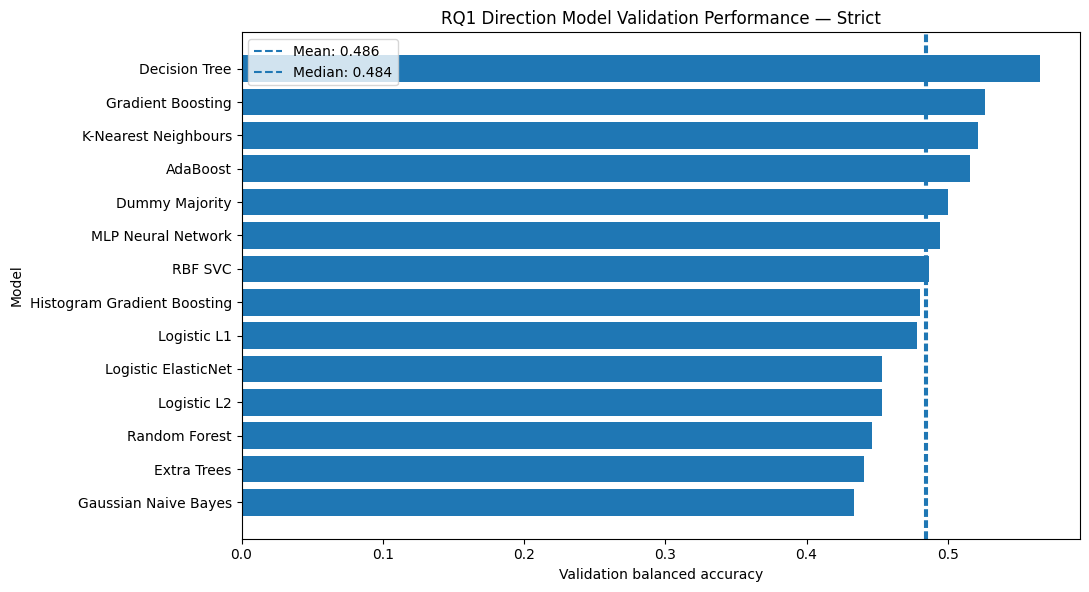

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq1_direction_models_strict.png


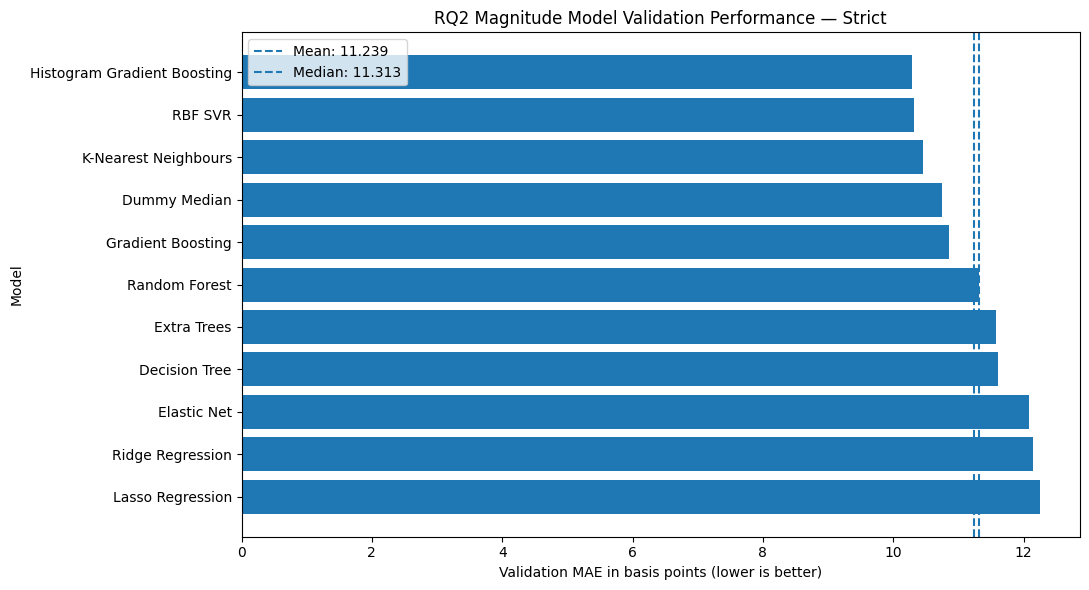

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq2_magnitude_models_strict.png


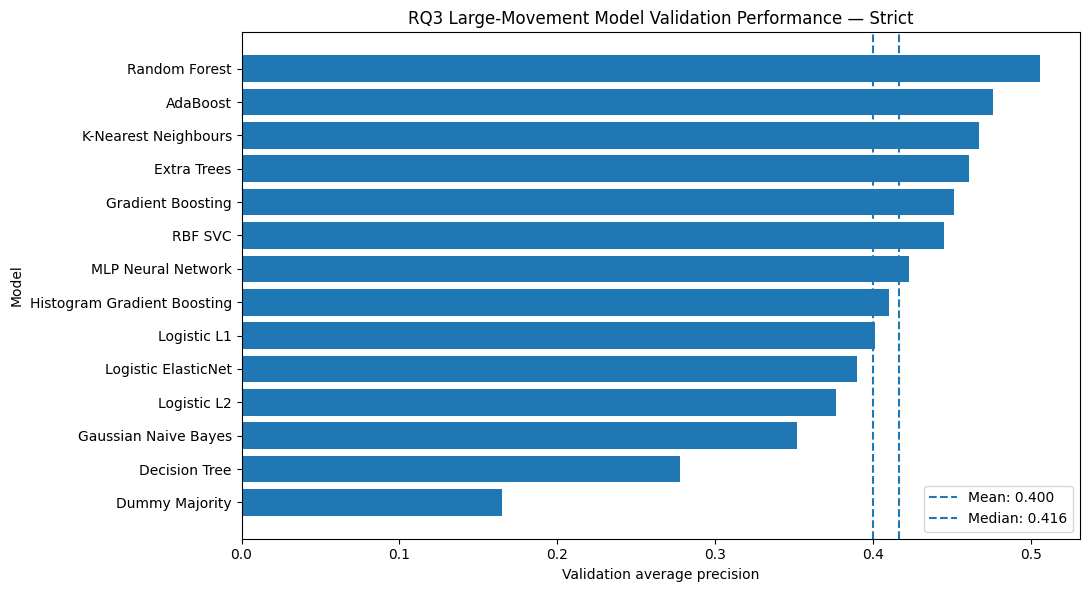

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq3_large_move_models_strict.png


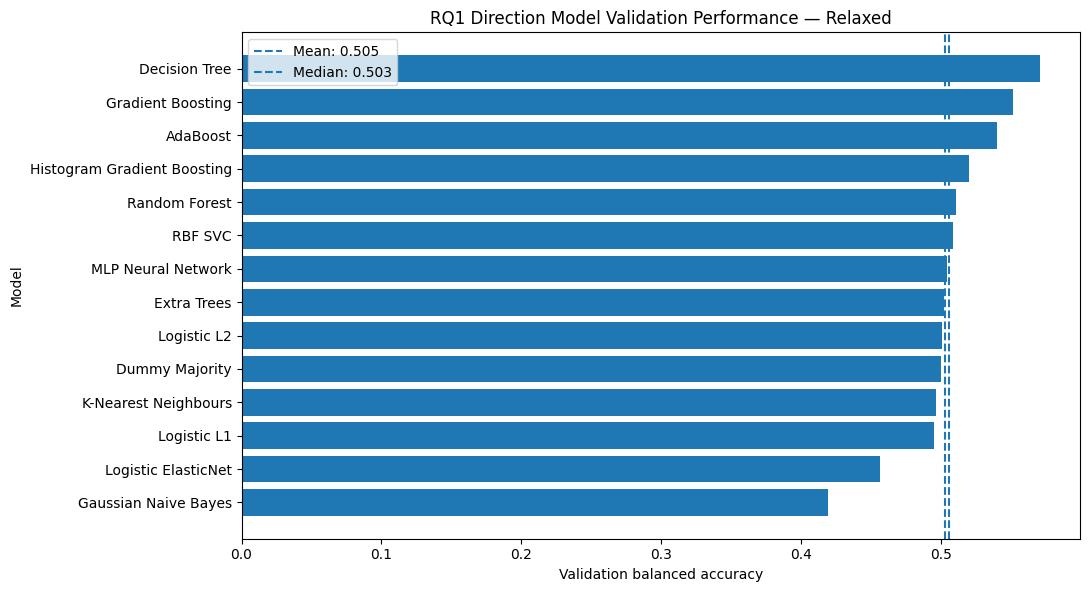

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq1_direction_models_relaxed.png


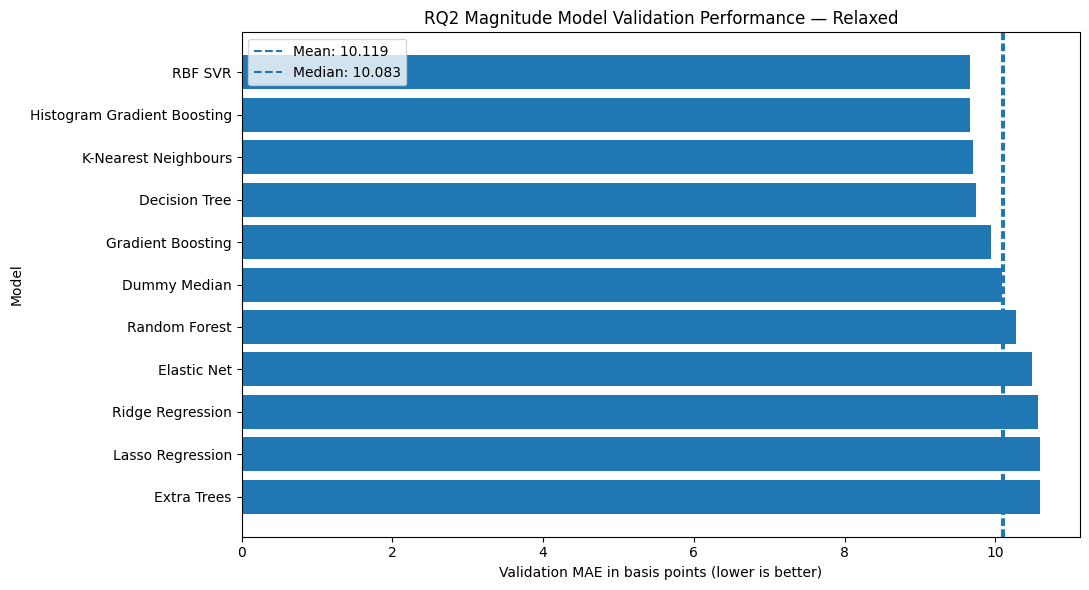

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq2_magnitude_models_relaxed.png


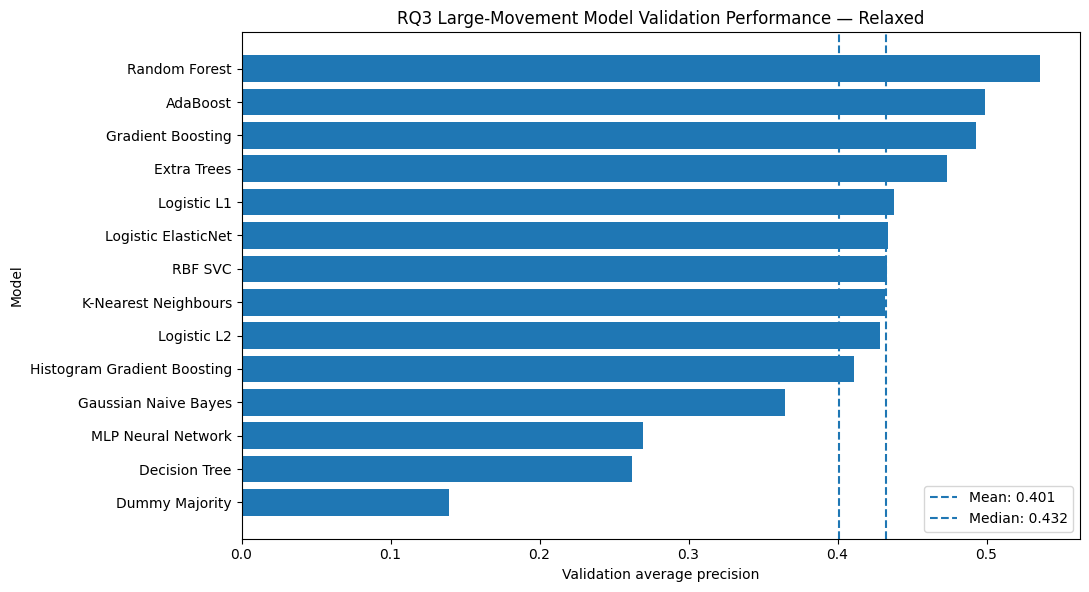

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq3_large_move_models_relaxed.png


In [59]:
# I use this cell for model-ranking charts.
def model_ranking_plot(
    results: pd.DataFrame,
    variant: str,
    metric: str,
    title: str,
    xlabel: str,
    filename: str,
    higher_is_better: bool = True,
):
    plot_data = (
        results[
            results["dataset_variant"].eq(variant)
        ][["model", metric]]
        .dropna()
        .sort_values(
            metric,
            ascending=not higher_is_better,
        )
    )

    mean_value = plot_data[metric].mean()
    median_value = plot_data[metric].median()

    fig, ax = plt.subplots(
        figsize=(11, max(6, len(plot_data) * 0.43))
    )

    ax.barh(
        plot_data["model"],
        plot_data[metric],
    )

    ax.invert_yaxis()
    ax.axvline(
        mean_value,
        linestyle="--",
        label=f"Mean: {mean_value:.3f}",
    )
    ax.axvline(
        median_value,
        linestyle="--",
        label=f"Median: {median_value:.3f}",
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    ax.legend()

    path = save_figure(fig, filename)
    plt.show()

    print("Saved:", path)


for variant in datasets:
    model_ranking_plot(
        rq1_results,
        variant,
        metric="validation_balanced_accuracy",
        title=(
            f"RQ1 Direction Model Validation Performance — {variant}"
        ),
        xlabel="Validation balanced accuracy",
        filename=f"rq1_direction_models_{variant.lower()}.png",
        higher_is_better=True,
    )

    model_ranking_plot(
        rq2_results,
        variant,
        metric="validation_mae_bps",
        title=(
            f"RQ2 Magnitude Model Validation Performance — {variant}"
        ),
        xlabel="Validation MAE in basis points (lower is better)",
        filename=f"rq2_magnitude_models_{variant.lower()}.png",
        higher_is_better=False,
    )

    model_ranking_plot(
        rq3_results,
        variant,
        metric="validation_average_precision",
        title=(
            f"RQ3 Large-Movement Model Validation Performance — {variant}"
        ),
        xlabel="Validation average precision",
        filename=f"rq3_large_move_models_{variant.lower()}.png",
        higher_is_better=True,
    )

## 9. Select provisional validation winners

These selections are provisional. They use validation performance only and do not inspect the test period.

In [60]:
# I use this cell for select provisional validation winners.
rq1_winner = rq1_results.iloc[0].to_dict()
rq2_winner = rq2_results.iloc[0].to_dict()
rq3_winner = rq3_results.iloc[0].to_dict()

provisional_winners = pd.DataFrame(
    [
        {
            "research_question": "RQ1 Direction",
            "dataset_variant": rq1_winner["dataset_variant"],
            "model": rq1_winner["model"],
            "primary_metric": "Balanced accuracy",
            "validation_score": rq1_winner[
                "validation_balanced_accuracy"
            ],
            "cv_score": rq1_winner[
                "cv_balanced_accuracy_mean"
            ],
        },
        {
            "research_question": "RQ2 Magnitude",
            "dataset_variant": rq2_winner["dataset_variant"],
            "model": rq2_winner["model"],
            "primary_metric": "MAE in basis points",
            "validation_score": rq2_winner[
                "validation_mae_bps"
            ],
            "cv_score": rq2_winner[
                "cv_mae_bps_mean"
            ],
        },
        {
            "research_question": "RQ3 Large Movement",
            "dataset_variant": rq3_winner["dataset_variant"],
            "model": rq3_winner["model"],
            "primary_metric": "Average precision",
            "validation_score": rq3_winner[
                "validation_average_precision"
            ],
            "cv_score": rq3_winner[
                "cv_average_precision_mean"
            ],
        },
    ]
)

display(provisional_winners)

WINNERS_PATH = TABLE_ROOT / "provisional_validation_winners.csv"
provisional_winners.to_csv(WINNERS_PATH, index=False)
print("Saved:", WINNERS_PATH)

,research_question,dataset_variant,model,primary_metric,validation_score,cv_score
0,RQ1 Direction,Relaxed,Decision Tree,Balanced accuracy,0.570534,0.513180
1,RQ2 Magnitude,Relaxed,RBF SVR,MAE in basis points,9.658577,12.558747
2,RQ3 Large Movement,Relaxed,Random Forest,Average precision,0.535954,0.512375


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\provisional_validation_winners.csv


## 10. Validation-period feature importance for RQ3

Permutation importance measures how much validation performance decreases when one feature is shuffled. It is model-dependent and may distribute importance across correlated features.

I therefore report both individual features and aggregated economic feature families.

,feature,importance_mean,importance_std,feature_group
0,atr_pct_open_to_1500,0.113215,0.046435,Volatility
1,rv_open_to_1500,0.092194,0.041522,Volatility
2,realized_vol_120m,0.042962,0.032063,Volatility
3,realized_vol_60m,0.033362,0.039904,Volatility
4,ret_last_15m,0.025828,0.012579,Momentum
5,dist_from_day_low_pct,0.021216,0.006632,Price positioning
6,vix_ret_last_15m,0.017970,0.010311,VIX
7,realized_vol_30m,0.015179,0.034164,Volatility
8,spy_cum_volume_to_1500,0.013494,0.012914,Volume and VWAP
9,ret_last_60m,0.012438,0.003858,Momentum


,feature_group,total_positive_importance,mean_importance,maximum_feature_importance
3,Volatility,0.296911,0.059382,0.113215
0,Momentum,0.062655,0.012531,0.025828
2,VIX,0.042901,0.010725,0.017970
1,Price positioning,0.027621,0.009207,0.021216
4,Volume and VWAP,0.019205,0.001450,0.013494


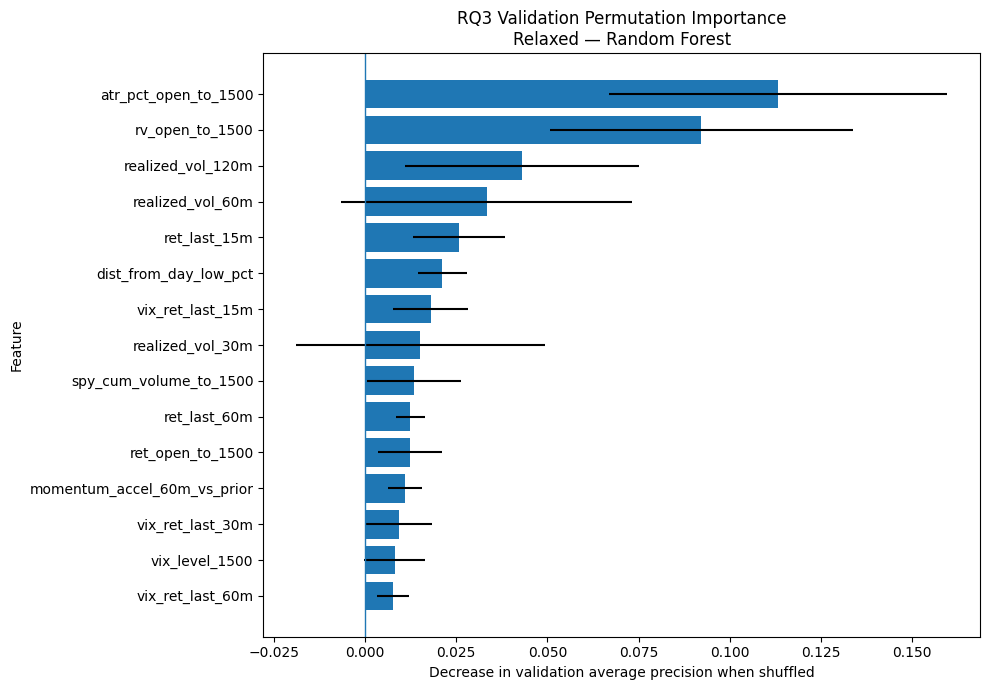

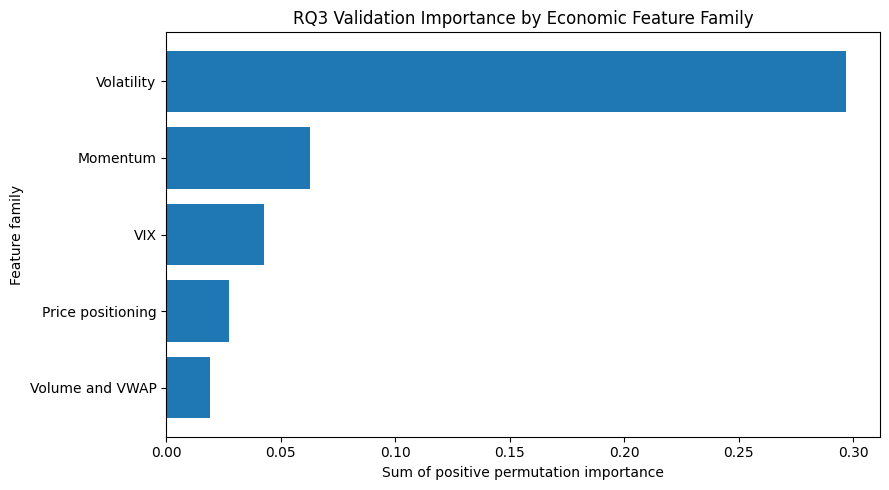

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq3_validation_permutation_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\rq3_validation_group_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq3_validation_feature_importance.png
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\figures\rq3_validation_group_importance.png


In [61]:
# I use this cell for validation-period feature importance for rq3.
def get_model_template(
    task: str,
    model_name: str,
):
    if task in {"RQ1", "RQ3"}:
        return CLASSIFICATION_MODELS[model_name]

    return REGRESSION_MODELS[model_name]


def fit_validation_model(
    frame: pd.DataFrame,
    model_template,
    target_column: str,
):
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    model = clone(model_template)

    model.fit(
        train[BASE_FEATURES],
        train[target_column],
    )

    return model, train, validation


rq3_variant = rq3_winner["dataset_variant"]
rq3_model_name = rq3_winner["model"]
rq3_frame = datasets[rq3_variant]

rq3_model, rq3_train, rq3_validation = fit_validation_model(
    rq3_frame,
    CLASSIFICATION_MODELS[rq3_model_name],
    "target_large_move",
)

rq3_importance = permutation_importance(
    rq3_model,
    rq3_validation[BASE_FEATURES],
    rq3_validation["target_large_move"],
    scoring="average_precision",
    n_repeats=40,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rq3_feature_importance = pd.DataFrame(
    {
        "feature": BASE_FEATURES,
        "importance_mean": rq3_importance.importances_mean,
        "importance_std": rq3_importance.importances_std,
    }
)

rq3_feature_importance["feature_group"] = (
    rq3_feature_importance["feature"].map(
        {
            feature: group
            for group, features in FEATURE_GROUPS.items()
            for feature in features
        }
    )
)

rq3_feature_importance = rq3_feature_importance.sort_values(
    "importance_mean",
    ascending=False,
).reset_index(drop=True)

display(rq3_feature_importance)

group_importance = (
    rq3_feature_importance.assign(
        positive_importance=lambda frame: frame[
            "importance_mean"
        ].clip(lower=0)
    )
    .groupby("feature_group", as_index=False)
    .agg(
        total_positive_importance=(
            "positive_importance",
            "sum",
        ),
        mean_importance=(
            "importance_mean",
            "mean",
        ),
        maximum_feature_importance=(
            "importance_mean",
            "max",
        ),
    )
    .sort_values(
        "total_positive_importance",
        ascending=False,
    )
)

display(group_importance)

RQ3_IMPORTANCE_PATH = (
    TABLE_ROOT
    / "rq3_validation_permutation_importance.csv"
)

RQ3_GROUP_PATH = (
    TABLE_ROOT
    / "rq3_validation_group_importance.csv"
)

rq3_feature_importance.to_csv(
    RQ3_IMPORTANCE_PATH,
    index=False,
)

group_importance.to_csv(
    RQ3_GROUP_PATH,
    index=False,
)

top_features = rq3_feature_importance.head(15).sort_values(
    "importance_mean"
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
)
ax.axvline(0, linewidth=1)
ax.set_title(
    f"RQ3 Validation Permutation Importance\n"
    f"{rq3_variant} — {rq3_model_name}"
)
ax.set_xlabel(
    "Decrease in validation average precision when shuffled"
)
ax.set_ylabel("Feature")
path = save_figure(
    fig,
    "rq3_validation_feature_importance.png",
)
plt.show()

group_plot = group_importance.sort_values(
    "total_positive_importance"
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    group_plot["feature_group"],
    group_plot["total_positive_importance"],
)
ax.set_title(
    "RQ3 Validation Importance by Economic Feature Family"
)
ax.set_xlabel("Sum of positive permutation importance")
ax.set_ylabel("Feature family")
group_path = save_figure(
    fig,
    "rq3_validation_group_importance.png",
)
plt.show()

print("Saved:", RQ3_IMPORTANCE_PATH)
print("Saved:", RQ3_GROUP_PATH)
print("Saved:", path)
print("Saved:", group_path)

## 11. Cross-question feature importance

RQ3 is the primary feature-importance analysis, but feature relevance may differ between predicting direction, magnitude and large movements.

This section computes validation permutation importance for each provisional winner and combines the results.

In [62]:
# I use this cell for cross-question feature importance.
winner_specifications = [
    {
        "research_question": "RQ1 Direction",
        "variant": rq1_winner["dataset_variant"],
        "model_name": rq1_winner["model"],
        "model_template": CLASSIFICATION_MODELS[
            rq1_winner["model"]
        ],
        "target": "target_up",
        "scoring": "balanced_accuracy",
    },
    {
        "research_question": "RQ2 Magnitude",
        "variant": rq2_winner["dataset_variant"],
        "model_name": rq2_winner["model"],
        "model_template": REGRESSION_MODELS[
            rq2_winner["model"]
        ],
        "target": "target_magnitude_bps",
        "scoring": "neg_mean_absolute_error",
    },
    {
        "research_question": "RQ3 Large Movement",
        "variant": rq3_winner["dataset_variant"],
        "model_name": rq3_winner["model"],
        "model_template": CLASSIFICATION_MODELS[
            rq3_winner["model"]
        ],
        "target": "target_large_move",
        "scoring": "average_precision",
    },
]

cross_question_rows = []

for specification in winner_specifications:
    frame = datasets[
        specification["variant"]
    ]

    model, train, validation = fit_validation_model(
        frame,
        specification["model_template"],
        specification["target"],
    )

    importance = permutation_importance(
        model,
        validation[BASE_FEATURES],
        validation[specification["target"]],
        scoring=specification["scoring"],
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    for feature, mean_value, std_value in zip(
        BASE_FEATURES,
        importance.importances_mean,
        importance.importances_std,
    ):
        cross_question_rows.append(
            {
                "research_question": specification[
                    "research_question"
                ],
                "dataset_variant": specification[
                    "variant"
                ],
                "model": specification[
                    "model_name"
                ],
                "feature": feature,
                "feature_group": next(
                    group
                    for group, features in FEATURE_GROUPS.items()
                    if feature in features
                ),
                "importance_mean": mean_value,
                "importance_std": std_value,
            }
        )

cross_question_importance = pd.DataFrame(
    cross_question_rows
)

display(
    cross_question_importance.sort_values(
        [
            "research_question",
            "importance_mean",
        ],
        ascending=[True, False],
    )
)

cross_group_importance = (
    cross_question_importance.assign(
        positive_importance=lambda frame: frame[
            "importance_mean"
        ].clip(lower=0)
    )
    .groupby(
        [
            "research_question",
            "feature_group",
        ],
        as_index=False,
    )
    .agg(
        total_positive_importance=(
            "positive_importance",
            "sum",
        ),
        mean_importance=(
            "importance_mean",
            "mean",
        ),
    )
)

display(cross_group_importance)

CROSS_FEATURE_PATH = (
    TABLE_ROOT
    / "cross_question_validation_feature_importance.csv"
)

CROSS_GROUP_PATH = (
    TABLE_ROOT
    / "cross_question_validation_group_importance.csv"
)

cross_question_importance.to_csv(
    CROSS_FEATURE_PATH,
    index=False,
)

cross_group_importance.to_csv(
    CROSS_GROUP_PATH,
    index=False,
)

print("Saved:", CROSS_FEATURE_PATH)
print("Saved:", CROSS_GROUP_PATH)

,research_question,dataset_variant,model,feature,feature_group,importance_mean,importance_std
19,RQ1 Direction,Relaxed,Decision Tree,dist_from_day_high_pct,Price positioning,0.061329,0.036637
6,RQ1 Direction,Relaxed,Decision Tree,vix_ret_last_15m,VIX,0.016521,0.025048
7,RQ1 Direction,Relaxed,Decision Tree,vix_ret_last_30m,VIX,0.013054,0.003814
21,RQ1 Direction,Relaxed,Decision Tree,atr_pct_open_to_1500,Volatility,0.006863,0.012749
16,RQ1 Direction,Relaxed,Decision Tree,spy_volume_accel_60m_vs_avg,Volume and VWAP,0.002696,0.009300
...,...,...,...,...,...,...,...
62,RQ3 Large Movement,Relaxed,Random Forest,position_in_day_range,Price positioning,0.001735,0.011464
46,RQ3 Large Movement,Relaxed,Random Forest,ret_last_30m,Momentum,0.001222,0.006800
57,RQ3 Large Movement,Relaxed,Random Forest,spy_volume_last_30m,Volume and VWAP,-0.001734,0.006085
61,RQ3 Large Movement,Relaxed,Random Forest,spy_dist_from_vwap_pct,Volume and VWAP,-0.004201,0.004689


,research_question,feature_group,total_positive_importance,mean_importance
0,RQ1 Direction,Momentum,0.000000,-0.000002
1,RQ1 Direction,Price positioning,0.061329,0.020443
2,RQ1 Direction,VIX,0.029575,0.005608
3,RQ1 Direction,Volatility,0.006863,-0.000300
4,RQ1 Direction,Volume and VWAP,0.002696,0.000539
5,RQ2 Magnitude,Momentum,0.138310,0.010636
6,RQ2 Magnitude,Price positioning,0.184262,0.061421
7,RQ2 Magnitude,VIX,0.268478,0.067120
8,RQ2 Magnitude,Volatility,0.597605,0.119521
9,RQ2 Magnitude,Volume and VWAP,0.231193,0.045728


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\cross_question_validation_feature_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\tables\cross_question_validation_group_importance.csv


## 12. Validation-based research-question summary

These statements are provisional and must be confirmed on the untouched test period.

### RQ1 decision logic

Evidence of directional predictability requires the leading model to:

- outperform the training-majority and simple rule baselines;
- exceed approximately 0.50 balanced accuracy;
- show similar performance across expanding folds and validation;
- avoid relying on one isolated validation regime.

### RQ2 decision logic

Evidence of magnitude predictability requires the leading model to:

- achieve lower validation MAE than the dummy median regressor;
- preferably produce positive out-of-sample R²;
- show a positive rank correlation between predicted and realised magnitude.

### RQ3 decision logic

Evidence of large-movement predictability requires the leading model to:

- improve average precision over the validation large-move prevalence;
- retain useful recall without predicting nearly every session as large;
- show feature importance that is reasonably stable across model families or feature groups.

A model ranking alone does not establish that the research question has been answered positively. The relevant benchmark and uncertainty must also be considered.

In [63]:
# I use this cell for validation-based research-question summary.
best_rule = (
    rule_results.sort_values(
        "balanced_accuracy",
        ascending=False,
    )
    .iloc[0]
)

rq1_summary = {
    "best_variant": rq1_winner["dataset_variant"],
    "best_model": rq1_winner["model"],
    "validation_balanced_accuracy": rq1_winner[
        "validation_balanced_accuracy"
    ],
    "best_rule_baseline": best_rule["rule"],
    "best_rule_balanced_accuracy": best_rule[
        "balanced_accuracy"
    ],
}

rq2_dummy = rq2_results[
    rq2_results["model"].eq("Dummy Median")
].sort_values("validation_mae_bps").iloc[0]

rq2_summary = {
    "best_variant": rq2_winner["dataset_variant"],
    "best_model": rq2_winner["model"],
    "validation_mae_bps": rq2_winner[
        "validation_mae_bps"
    ],
    "best_dummy_mae_bps": rq2_dummy[
        "validation_mae_bps"
    ],
    "mae_improvement_bps": (
        rq2_dummy["validation_mae_bps"]
        - rq2_winner["validation_mae_bps"]
    ),
    "validation_r2": rq2_winner[
        "validation_r2"
    ],
    "validation_spearman": rq2_winner[
        "validation_spearman"
    ],
}

rq3_variant_frame = datasets[
    rq3_winner["dataset_variant"]
]

rq3_validation_prevalence = (
    rq3_variant_frame.loc[
        rq3_variant_frame["data_split"].eq(
            "Validation"
        ),
        "target_large_move",
    ].mean()
)

rq3_summary = {
    "large_move_threshold_bps": LARGE_MOVE_THRESHOLD_BPS,
    "best_variant": rq3_winner["dataset_variant"],
    "best_model": rq3_winner["model"],
    "validation_average_precision": rq3_winner[
        "validation_average_precision"
    ],
    "validation_large_move_prevalence": (
        rq3_validation_prevalence
    ),
    "average_precision_improvement": (
        rq3_winner["validation_average_precision"]
        - rq3_validation_prevalence
    ),
    "top_feature_group": (
        group_importance.iloc[0]["feature_group"]
        if len(group_importance)
        else None
    ),
}

validation_rq_summary = {
    "RQ1": rq1_summary,
    "RQ2": rq2_summary,
    "RQ3": rq3_summary,
}

display(
    pd.DataFrame(
        [
            {
                "research_question": key,
                **value,
            }
            for key, value in validation_rq_summary.items()
        ]
    )
)

VALIDATION_SUMMARY_PATH = (
    MODEL_ROOT
    / "validation_research_question_summary.json"
)

with open(
    VALIDATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        validation_rq_summary,
        summary_file,
        indent=2,
        default=float,
    )

print(
    json.dumps(
        validation_rq_summary,
        indent=2,
        default=float,
    )
)
print("Saved:", VALIDATION_SUMMARY_PATH)

,research_question,best_variant,best_model,validation_balanced_accuracy,best_rule_baseline,best_rule_balanced_accuracy,validation_mae_bps,best_dummy_mae_bps,mae_improvement_bps,validation_r2,validation_spearman,large_move_threshold_bps,validation_average_precision,validation_large_move_prevalence,average_precision_improvement,top_feature_group
0,RQ1,Relaxed,Decision Tree,0.570534,60m Mean Reversion,0.642287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RQ2,Relaxed,RBF SVR,NaN,NaN,NaN,9.658577,10.083445,0.424868,0.243618,0.298436,NaN,NaN,NaN,NaN,NaN
2,RQ3,Relaxed,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.575607,0.535954,0.139344,0.396610,Volatility


{
  "RQ1": {
    "best_variant": "Relaxed",
    "best_model": "Decision Tree",
    "validation_balanced_accuracy": 0.5705337690631809,
    "best_rule_baseline": "60m Mean Reversion",
    "best_rule_balanced_accuracy": 0.6422872340425532
  },
  "RQ2": {
    "best_variant": "Relaxed",
    "best_model": "RBF SVR",
    "validation_mae_bps": 9.658576728476245,
    "best_dummy_mae_bps": 10.08344456787935,
    "mae_improvement_bps": 0.424867839403106,
    "validation_r2": 0.24361803717061348,
    "validation_spearman": 0.2984359975018257
  },
  "RQ3": {
    "large_move_threshold_bps": 27.575607227454114,
    "best_variant": "Relaxed",
    "best_model": "Random Forest",
    "validation_average_precision": 0.5359544988036672,
    "validation_large_move_prevalence": 0.13934426229508196,
    "average_precision_improvement": 0.39661023650858523,
    "top_feature_group": "Volatility"
  }
}
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\baseline_models\validat

---
# Part V — Nested hyperparameter tuning and robustness on the longer sample

This section reproduces the expanding-window nested tuning, fold-matched benchmarks, permutation-importance stability, regime analysis and confidence-selective diagnostics from `08_hyperparameters_tuning_extended_robustness.ipynb`.

Results from this extension should be reported as **longer-sample robustness evidence**. They should not retrospectively replace the already-developed RQ5 trading rules merely because a different model or threshold looks better over the expanded sample.

## 1. Environment and reproducibility settings

The default search budget is intentionally moderate. I would increase `N_RANDOM_SEARCH_ITERATIONS` only after confirming that the workflow runs correctly.

The search is computationally heavier than the baseline notebook because every candidate model is tuned inside each outer time-series fold.

In [64]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.special import expit
from scipy.stats import (
    loguniform,
    randint,
    spearmanr,
    uniform,
)

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    ElasticNet,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC, SVR

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

# Moderate defaults. Increase only when the workflow is stable.
OUTER_SPLITS = 3
INNER_SPLITS = 3
N_RANDOM_SEARCH_ITERATIONS = 30

# The existing test set was already inspected in the baseline notebook.
RUN_EXISTING_TEST_AS_SECONDARY_CHECK = False

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data_extended_2023_2026" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data_extended_2023_2026/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "extended_2023_2026"
TUNING_ROOT = OUTPUT_ROOT / "hyperparameter_tuning"
TABLE_ROOT = TUNING_ROOT / "tables"
FIGURE_ROOT = TUNING_ROOT / "figures"

TUNING_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tuning output:", TUNING_ROOT)
print("Outer splits:", OUTER_SPLITS)
print("Inner splits:", INNER_SPLITS)
print("Random-search iterations:", N_RANDOM_SEARCH_ITERATIONS)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Tuning output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning
Outer splits: 3
Inner splits: 3
Random-search iterations: 30


## 2. Load the strict and relaxed datasets

Only Train and Validation rows are used for primary nested tuning. Test rows are loaded so that date boundaries can be audited, but they are not used in search or model selection.

In [65]:
# I use this cell for load the strict and relaxed datasets.
STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

if not STRICT_PATH.exists() or not RELAXED_PATH.exists():
    raise FileNotFoundError(
        "Run notebooks/05_dataset_Splitting.ipynb first."
    )


def load_variant(path: Path, variant_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "data_split",
        "final_hour_return",
        "target_up",
        "spx_at_1500",
        "atr_open_to_1500",
    }

    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"{variant_name} dataset is missing: {sorted(missing)}"
        )

    frame["atr_pct_open_to_1500"] = (
        frame["atr_open_to_1500"]
        / frame["spx_at_1500"]
    )

    frame["target_magnitude_bps"] = (
        frame["final_hour_return"].abs() * 10_000
    )

    return frame


strict_data = load_variant(STRICT_PATH, "Strict")
relaxed_data = load_variant(RELAXED_PATH, "Relaxed")

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

coverage_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        coverage_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": subset["session_date"].min(),
                "last_date": subset["session_date"].max(),
                "up_pct": subset["target_up"].mean() * 100,
            }
        )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

for variant, frame in datasets.items():
    development = frame[
        frame["data_split"].isin(["Train", "Validation"])
    ].sort_values("session_date")

    test = frame[
        frame["data_split"].eq("Test")
    ].sort_values("session_date")

    assert development["session_date"].max() < test["session_date"].min()

print("Development and test date ordering verified.")

,dataset_variant,data_split,sessions,first_date,last_date,up_pct
0,Strict,Train,475,2023-02-15,2025-07-25,49.894737
1,Strict,Validation,103,2025-07-28,2026-01-28,45.631068
2,Strict,Test,102,2026-01-29,2026-07-17,55.882353
3,Relaxed,Train,571,2023-02-15,2025-07-25,49.211909
4,Relaxed,Validation,122,2025-07-28,2026-01-28,44.262295
5,Relaxed,Test,117,2026-01-29,2026-07-17,57.264957


Development and test date ordering verified.


## 3. Feature sets and targets

Two feature sets are compared.

### Full set

The 22 underlying features retained in the baseline notebook.

### Reduced set

A more compact set that removes some overlapping realised-volatility, return-window and volume variables. This tests whether reducing collinearity improves temporal stability.

The large-movement threshold remains fixed using the 75th percentile of the strict original training period, preserving comparability with the baseline analysis.

In [66]:
# I use this cell for feature sets and targets.
FULL_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "atr_pct_open_to_1500",
]

REDUCED_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_60m",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "atr_pct_open_to_1500",
]

FEATURE_SETS = {
    "Full": FULL_FEATURES,
    "Reduced": REDUCED_FEATURES,
}

LARGE_MOVE_QUANTILE = 0.75

strict_original_train = strict_data[
    strict_data["data_split"].eq("Train")
]

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_original_train["final_hour_return"]
    .abs()
    .quantile(LARGE_MOVE_QUANTILE)
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

for variant, frame in datasets.items():
    frame["target_large_move"] = (
        frame["final_hour_return"].abs()
        >= LARGE_MOVE_THRESHOLD_RETURN
    ).astype("int8")

    for feature_set_name, features in FEATURE_SETS.items():
        missing = set(features).difference(frame.columns)

        if missing:
            raise ValueError(
                f"{variant}/{feature_set_name} missing: {sorted(missing)}"
            )

        frame[features] = frame[features].replace(
            [np.inf, -np.inf],
            np.nan,
        )

print(
    f"Large-movement threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.3f} basis points"
)

feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": name,
            "feature_count": len(features),
            "features": ", ".join(features),
        }
        for name, features in FEATURE_SETS.items()
    ]
)

display(feature_set_summary)

Large-movement threshold: 27.576 basis points


,feature_set,feature_count,features
0,Full,22,"ret_open_to_1500, ret_last_15m, ret_last_30m, ..."
1,Reduced,15,"ret_open_to_1500, ret_last_15m, ret_last_60m, ..."


## 4. Tuned model families and search spaces

The search focuses on diverse model families rather than tuning every baseline algorithm.

### Classification

- elastic-net logistic regression;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector classifier.

### Regression

- ridge regression;
- elastic net;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector regression.

The search spaces are deliberately bounded to reduce overfitting and computational cost.

In [67]:
# I use this cell for tuned model families and search spaces.
def scaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


CLASSIFICATION_SEARCH_SPACES = {
    "Logistic ElasticNet": {
        "estimator": scaled_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                class_weight="balanced",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-3, 100),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesClassifier(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__class_weight": [
                "balanced",
                "balanced_subsample",
            ],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVC": {
        "estimator": scaled_pipeline(
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}


REGRESSION_SEARCH_SPACES = {
    "Ridge Regression": {
        "estimator": scaled_pipeline(
            Ridge()
        ),
        "parameters": {
            "model__alpha": loguniform(1e-3, 1_000),
        },
    },
    "Elastic Net": {
        "estimator": scaled_pipeline(
            ElasticNet(
                max_iter=20_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__alpha": loguniform(1e-4, 10),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingRegressor(
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__loss": ["absolute_error", "squared_error"],
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVR": {
        "estimator": scaled_pipeline(
            SVR(kernel="rbf")
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__epsilon": loguniform(0.05, 8),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}

print("Classification families:", len(CLASSIFICATION_SEARCH_SPACES))
print("Regression families:", len(REGRESSION_SEARCH_SPACES))

Classification families: 4
Regression families: 5


## 5. Evaluation and threshold functions

Classification thresholds are selected inside each outer fold.

For every outer training block:

1. the hyperparameters are selected using inner expanding-window search;
2. the selected estimator generates inner time-series out-of-fold scores;
3. a threshold is selected using only those inner historical scores;
4. the estimator and threshold are evaluated on the later outer fold.

RQ1 thresholds maximise balanced accuracy.

RQ3 thresholds maximise F1 to address the very low recall observed at the default threshold in the baseline model.

In [68]:
def model_scores(estimator, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(X))

    return np.asarray(estimator.predict(X), dtype=float)


def safe_auc(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, scores))


def safe_average_precision(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(average_precision_score(y_true, scores))


def classification_metric_bundle(
    y_true,
    predictions,
    scores,
) -> dict:
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "roc_auc": safe_auc(y_true, scores),
        "average_precision": safe_average_precision(
            y_true,
            scores,
        ),
    }


def regression_metric_bundle(
    y_true,
    predictions,
) -> dict:
    rank_correlation = spearmanr(
        y_true,
        predictions,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            predictions,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                predictions,
            )
        ),
        "r2": r2_score(
            y_true,
            predictions,
        ),
        "spearman": rank_correlation,
    }


def inner_time_series_scores(
    estimator,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int,
):
    splitter = TimeSeriesSplit(n_splits=n_splits)

    true_values = []
    scores = []

    for train_index, validation_index in splitter.split(X):
        fold_estimator = clone(estimator)

        fold_estimator.fit(
            X.iloc[train_index],
            y.iloc[train_index],
        )

        fold_scores = model_scores(
            fold_estimator,
            X.iloc[validation_index],
        )

        true_values.extend(
            y.iloc[validation_index].to_numpy()
        )

        scores.extend(fold_scores)

    return (
        np.asarray(true_values, dtype=int),
        np.asarray(scores, dtype=float),
    )


def select_threshold(
    y_true,
    scores,
    objective: str,
):
    if len(np.unique(scores)) < 2:
        return float(scores[0]), np.nan

    quantiles = np.linspace(0.02, 0.98, 97)
    candidates = np.unique(
        np.quantile(scores, quantiles)
    )

    # Include standard probability and decision-function cutoffs.
    candidates = np.unique(
        np.concatenate(
            [
                candidates,
                np.array([0.0, 0.5]),
            ]
        )
    )

    rows = []

    for threshold in candidates:
        predictions = (scores >= threshold).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(
                y_true,
                predictions,
            )
        elif objective == "f1":
            value = f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        else:
            raise ValueError(
                f"Unsupported threshold objective: {objective}"
            )

        rows.append(
            {
                "threshold": threshold,
                "objective_value": value,
            }
        )

    threshold_table = pd.DataFrame(rows).sort_values(
        ["objective_value", "threshold"],
        ascending=[False, True],
    )

    best = threshold_table.iloc[0]

    return (
        float(best["threshold"]),
        float(best["objective_value"]),
    )


def development_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame[
            frame["data_split"].isin(
                ["Train", "Validation"]
            )
        ]
        .sort_values("session_date")
        .reset_index(drop=True)
    )

## 6. Nested classification tuning

This function is used for both RQ1 and RQ3.

The outer-fold metrics represent the main generalisation estimate. The search score itself is not treated as final performance because it is used to choose hyperparameters.

In [69]:
# I use this cell for nested classification tuning.
def nested_classification_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
    target_column: str,
    task_name: str,
    search_scoring: str,
    threshold_objective: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development[target_column].astype(int)

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        CLASSIFICATION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring=search_scoring,
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            best_estimator = search.best_estimator_

            inner_y, inner_scores = inner_time_series_scores(
                best_estimator,
                X_outer_train.reset_index(drop=True),
                y_outer_train.reset_index(drop=True),
                n_splits=INNER_SPLITS,
            )

            threshold, threshold_score = select_threshold(
                inner_y,
                inner_scores,
                objective=threshold_objective,
            )

            outer_scores = model_scores(
                best_estimator,
                X_outer_test,
            )

            outer_predictions = (
                outer_scores >= threshold
            ).astype(int)

            metrics = classification_metric_bundle(
                y_outer_test,
                outer_predictions,
                outer_scores,
            )

            positive_prevalence = float(
                y_outer_test.mean()
            )
            average_precision_lift = (
                metrics["average_precision"]
                - positive_prevalence
            )
            average_precision_lift_ratio = (
                metrics["average_precision"]
                / positive_prevalence
                if positive_prevalence > 0
                else np.nan
            )

            metrics.update(
                {
                    "positive_prevalence": (
                        positive_prevalence
                    ),
                    "average_precision_lift": (
                        average_precision_lift
                    ),
                    "average_precision_lift_ratio": (
                        average_precision_lift_ratio
                    ),
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "threshold": threshold,
                    "inner_threshold_objective": (
                        threshold_score
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": task_name,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": task_name,
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_balanced_accuracy_mean": (
                    fold_frame[
                        "balanced_accuracy"
                    ].mean()
                ),
                "outer_balanced_accuracy_std": (
                    fold_frame[
                        "balanced_accuracy"
                    ].std()
                ),
                "outer_accuracy_mean": (
                    fold_frame["accuracy"].mean()
                ),
                "outer_f1_mean": (
                    fold_frame["f1"].mean()
                ),
                "outer_recall_mean": (
                    fold_frame["recall"].mean()
                ),
                "outer_mcc_mean": (
                    fold_frame["mcc"].mean()
                ),
                "outer_roc_auc_mean": (
                    fold_frame["roc_auc"].mean()
                ),
                "outer_average_precision_mean": (
                    fold_frame[
                        "average_precision"
                    ].mean()
                ),
                "outer_average_precision_std": (
                    fold_frame[
                        "average_precision"
                    ].std()
                ),
                "outer_positive_prevalence_mean": (
                    fold_frame[
                        "positive_prevalence"
                    ].mean()
                ),
                "outer_average_precision_lift_mean": (
                    fold_frame[
                        "average_precision_lift"
                    ].mean()
                ),
                "outer_average_precision_lift_std": (
                    fold_frame[
                        "average_precision_lift"
                    ].std()
                ),
                "outer_average_precision_lift_ratio_mean": (
                    fold_frame[
                        "average_precision_lift_ratio"
                    ].mean()
                ),
                "outer_threshold_mean": (
                    fold_frame["threshold"].mean()
                ),
                "outer_threshold_std": (
                    fold_frame["threshold"].std()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

## 7. Nested regression tuning

RQ2 uses MAE as the search and outer-fold selection metric. R² and Spearman correlation are retained to distinguish small absolute-error improvements from genuine ranking or explanatory ability.

In [70]:
# I use this cell for nested regression tuning.
def nested_regression_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development["target_magnitude_bps"]

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        REGRESSION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring="neg_mean_absolute_error",
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            predictions = search.best_estimator_.predict(
                X_outer_test
            )

            metrics = regression_metric_bundle(
                y_outer_test,
                predictions,
            )

            metrics.update(
                {
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": "RQ2 Magnitude",
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": "RQ2 Magnitude",
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_mae_bps_mean": (
                    fold_frame["mae_bps"].mean()
                ),
                "outer_mae_bps_std": (
                    fold_frame["mae_bps"].std()
                ),
                "outer_rmse_bps_mean": (
                    fold_frame["rmse_bps"].mean()
                ),
                "outer_r2_mean": (
                    fold_frame["r2"].mean()
                ),
                "outer_spearman_mean": (
                    fold_frame["spearman"].mean()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

# 8. Run RQ1 tuning

This is the most difficult research question. A tuned model should not be considered successful merely because it achieves the highest score among the candidates.

A convincing result requires:

- mean outer balanced accuracy materially above 0.50;
- limited fold-to-fold variation;
- improvement over the simple 60-minute mean-reversion rule;
- no collapse when moving from strict to relaxed data or from full to reduced features.

In [71]:
# I use this cell for run rq1 tuning.
rq1_summary_frames = []
rq1_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_up",
            task_name="RQ1 Direction",
            search_scoring="balanced_accuracy",
            threshold_objective="balanced_accuracy",
        )

        rq1_summary_frames.append(summary)
        rq1_fold_frames.append(folds)

rq1_tuning_summary = pd.concat(
    rq1_summary_frames,
    ignore_index=True,
)

rq1_tuning_folds = pd.concat(
    rq1_fold_frames,
    ignore_index=True,
)

rq1_tuning_summary = rq1_tuning_summary.sort_values(
    [
        "outer_balanced_accuracy_mean",
        "outer_balanced_accuracy_std",
    ],
    ascending=[False, True],
).reset_index(drop=True)

display(rq1_tuning_summary)

RQ1_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_summary.csv"
)

RQ1_FOLDS_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_outer_folds.csv"
)

rq1_tuning_summary.to_csv(
    RQ1_SUMMARY_PATH,
    index=False,
)

rq1_tuning_folds.to_csv(
    RQ1_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ1_SUMMARY_PATH)
print("Saved:", RQ1_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_average_precision_std,outer_positive_prevalence_mean,outer_average_precision_lift_mean,outer_average_precision_lift_std,outer_average_precision_lift_ratio_mean,outer_threshold_mean,outer_threshold_std
0,RQ1 Direction,Strict,Full,Extra Trees,0.537304,0.025552,0.537037,0.649682,0.890836,0.130928,0.515719,0.503968,0.072078,0.490741,0.013228,0.046169,1.024430,0.439284,0.062989
1,RQ1 Direction,Relaxed,Reduced,Histogram Gradient Boosting,0.521915,0.026733,0.516378,0.476293,0.513415,0.057077,0.521216,0.505286,0.041038,0.485549,0.019737,0.016003,1.040100,0.423271,0.119079
2,RQ1 Direction,Strict,Reduced,RBF SVC,0.520315,0.012575,0.520833,0.606582,0.801211,0.074942,0.528889,0.523799,0.039602,0.490741,0.033058,0.007421,1.066978,-0.281854,0.557001
3,RQ1 Direction,Strict,Reduced,Histogram Gradient Boosting,0.520166,0.016643,0.513889,0.448075,0.427410,0.045816,0.541919,0.517544,0.068453,0.490741,0.026803,0.036855,1.051715,0.580142,0.017265
4,RQ1 Direction,Strict,Full,Histogram Gradient Boosting,0.519407,0.030371,0.513889,0.486663,0.481401,0.042377,0.539015,0.534136,0.073837,0.490741,0.043395,0.042175,1.085157,0.529456,0.073528
5,RQ1 Direction,Strict,Full,Logistic ElasticNet,0.508588,0.052278,0.513889,0.399816,0.492603,0.018087,0.501807,0.507792,0.074448,0.490741,0.017051,0.041654,1.031173,0.497415,0.004257
6,RQ1 Direction,Strict,Reduced,Extra Trees,0.507510,0.057444,0.513889,0.570786,0.707261,0.041049,0.512674,0.512494,0.054378,0.490741,0.021753,0.026288,1.042894,0.470789,0.051056
7,RQ1 Direction,Relaxed,Full,Extra Trees,0.504724,0.006715,0.481696,0.450038,0.635185,0.030730,0.499985,0.485432,0.024878,0.485549,-0.000117,0.014670,1.000470,0.475751,0.038221
8,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,0.503489,0.006210,0.506744,0.426855,0.389149,0.007172,0.522362,0.523579,0.037652,0.485549,0.038030,0.012990,1.078074,0.510151,0.045790
9,RQ1 Direction,Relaxed,Reduced,Logistic ElasticNet,0.500938,0.000815,0.481696,0.446829,0.565492,0.002421,0.487100,0.489990,0.030061,0.485549,0.004441,0.006188,1.009255,0.510008,0.013952


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq1_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq1_nested_tuning_outer_folds.csv


# 9. Run RQ2 tuning

In [72]:
# I use this cell for run rq2 tuning.
rq2_summary_frames = []
rq2_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_regression_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
        )

        rq2_summary_frames.append(summary)
        rq2_fold_frames.append(folds)

rq2_tuning_summary = pd.concat(
    rq2_summary_frames,
    ignore_index=True,
)

rq2_tuning_folds = pd.concat(
    rq2_fold_frames,
    ignore_index=True,
)

rq2_tuning_summary = rq2_tuning_summary.sort_values(
    [
        "outer_mae_bps_mean",
        "outer_mae_bps_std",
    ],
    ascending=[True, True],
).reset_index(drop=True)

display(rq2_tuning_summary)

RQ2_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_summary.csv"
)

RQ2_FOLDS_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_outer_folds.csv"
)

rq2_tuning_summary.to_csv(
    RQ2_SUMMARY_PATH,
    index=False,
)

rq2_tuning_folds.to_csv(
    RQ2_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ2_SUMMARY_PATH)
print("Saved:", RQ2_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_mae_bps_mean,outer_mae_bps_std,outer_rmse_bps_mean,outer_r2_mean,outer_spearman_mean
0,RQ2 Magnitude,Relaxed,Full,RBF SVR,11.879533,2.619790,19.490107,0.135462,0.409435
1,RQ2 Magnitude,Relaxed,Reduced,RBF SVR,11.923804,2.537059,19.512653,0.127076,0.412970
2,RQ2 Magnitude,Relaxed,Full,Elastic Net,12.058763,2.205776,17.939770,0.231445,0.451038
3,RQ2 Magnitude,Relaxed,Reduced,Elastic Net,12.149433,2.204707,17.937230,0.231058,0.450721
4,RQ2 Magnitude,Relaxed,Reduced,Ridge Regression,12.187584,2.217049,18.021774,0.223786,0.441483
5,RQ2 Magnitude,Relaxed,Full,Histogram Gradient Boosting,12.196308,2.724257,19.924661,0.097300,0.336157
6,RQ2 Magnitude,Relaxed,Full,Ridge Regression,12.295168,2.103506,17.962339,0.228382,0.427083
7,RQ2 Magnitude,Relaxed,Reduced,Histogram Gradient Boosting,12.349385,2.658361,20.068076,0.077839,0.331045
8,RQ2 Magnitude,Relaxed,Reduced,Extra Trees,12.379827,2.522522,18.612779,0.190231,0.389405
9,RQ2 Magnitude,Relaxed,Full,Extra Trees,12.509172,2.367363,18.484450,0.202276,0.376966


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq2_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq2_nested_tuning_outer_folds.csv


# 10. Run RQ3 tuning

Average precision is the primary selection metric because it evaluates large-move ranking without imposing a fixed threshold.

The fold-specific F1 threshold is reported separately to determine whether the poor large-move recall in the baseline was mainly a threshold problem.

In [73]:
# I use this cell for run rq3 tuning.
rq3_summary_frames = []
rq3_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_large_move",
            task_name="RQ3 Large Movement",
            search_scoring="average_precision",
            threshold_objective="f1",
        )

        rq3_summary_frames.append(summary)
        rq3_fold_frames.append(folds)

rq3_tuning_summary = pd.concat(
    rq3_summary_frames,
    ignore_index=True,
)

rq3_tuning_folds = pd.concat(
    rq3_fold_frames,
    ignore_index=True,
)

rq3_tuning_summary = rq3_tuning_summary.sort_values(
    [
        "outer_average_precision_mean",
        "outer_recall_mean",
        "outer_f1_mean",
    ],
    ascending=[False, False, False],
).reset_index(drop=True)

display(rq3_tuning_summary)

RQ3_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_summary.csv"
)

RQ3_FOLDS_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_outer_folds.csv"
)

rq3_tuning_summary.to_csv(
    RQ3_SUMMARY_PATH,
    index=False,
)

rq3_tuning_folds.to_csv(
    RQ3_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ3_SUMMARY_PATH)
print("Saved:", RQ3_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_average_precision_std,outer_positive_prevalence_mean,outer_average_precision_lift_mean,outer_average_precision_lift_std,outer_average_precision_lift_ratio_mean,outer_threshold_mean,outer_threshold_std
0,RQ3 Large Movement,Strict,Reduced,RBF SVC,0.665636,0.054526,0.611111,0.492181,0.818730,0.327892,0.787555,0.538148,0.151081,0.238426,0.299722,0.081766,2.360693,-0.632085,0.440745
1,RQ3 Large Movement,Strict,Reduced,Extra Trees,0.680620,0.062760,0.743056,0.500723,0.595317,0.333238,0.765298,0.527434,0.085710,0.238426,0.289008,0.030588,2.388848,0.486186,0.051401
2,RQ3 Large Movement,Relaxed,Reduced,RBF SVC,0.675965,0.037839,0.728324,0.430597,0.555686,0.324443,0.810566,0.526515,0.170761,0.204239,0.322276,0.096729,2.619066,-0.298496,0.666382
3,RQ3 Large Movement,Relaxed,Full,Logistic ElasticNet,0.680286,0.052753,0.778420,0.480775,0.541438,0.346449,0.801703,0.519352,0.135948,0.204239,0.315114,0.064400,2.622553,0.500065,0.016094
4,RQ3 Large Movement,Relaxed,Full,RBF SVC,0.620383,0.127625,0.747592,0.269395,0.378301,0.226376,0.811785,0.517842,0.131034,0.204239,0.313603,0.065409,2.623402,-0.263583,0.462610
5,RQ3 Large Movement,Strict,Full,Extra Trees,0.683143,0.064666,0.689815,0.494913,0.681349,0.317073,0.766563,0.516652,0.098578,0.238426,0.278226,0.009666,2.327825,0.444418,0.020009
6,RQ3 Large Movement,Strict,Full,RBF SVC,0.673268,0.075077,0.502315,0.479264,0.982917,0.327919,0.780980,0.515595,0.135780,0.238426,0.277169,0.044279,2.265836,-0.875065,0.008173
7,RQ3 Large Movement,Relaxed,Reduced,Extra Trees,0.688176,0.059303,0.741811,0.475203,0.629412,0.342600,0.783339,0.502189,0.136800,0.204239,0.297951,0.057079,2.529593,0.477646,0.035883
8,RQ3 Large Movement,Relaxed,Full,Extra Trees,0.686411,0.048459,0.739884,0.472180,0.614641,0.328537,0.803398,0.495440,0.159098,0.204239,0.291201,0.079446,2.465723,0.485580,0.020691
9,RQ3 Large Movement,Relaxed,Reduced,Logistic ElasticNet,0.659699,0.070697,0.764933,0.446895,0.512549,0.301386,0.768047,0.489684,0.154079,0.204239,0.285445,0.074378,2.441086,0.549587,0.055058


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq3_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\rq3_nested_tuning_outer_folds.csv


## 11. Ranking and stability charts

The error bars show one standard deviation across outer temporal folds. A model with a slightly lower mean but much lower variability may be preferable for the dissertation.

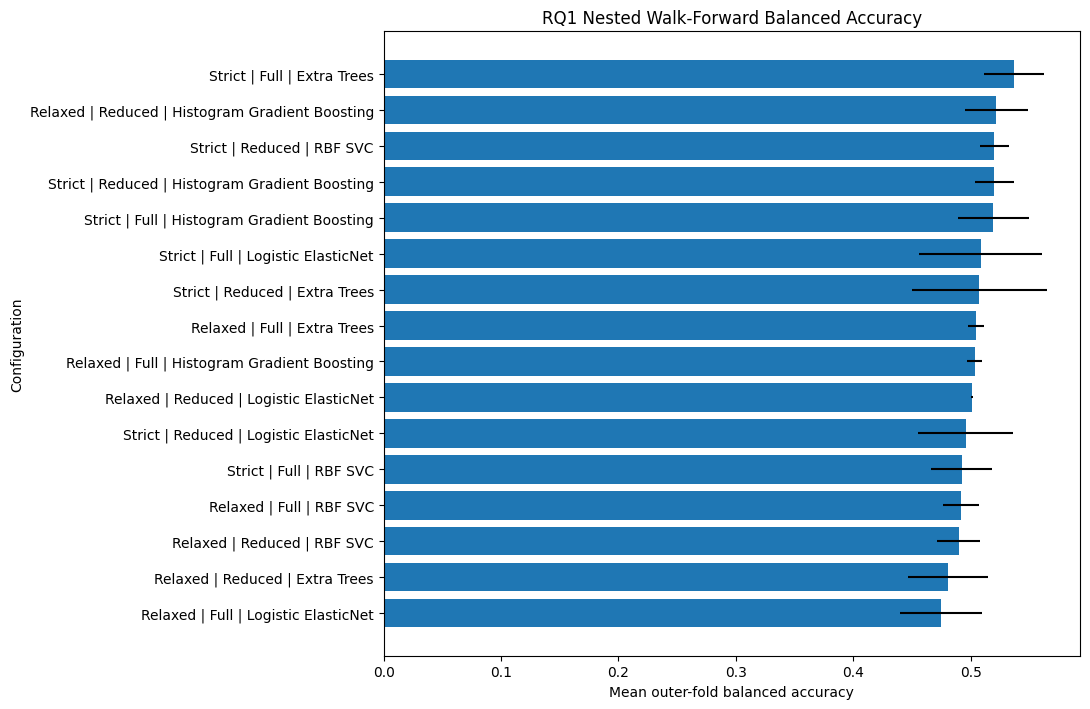

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq1_nested_balanced_accuracy.png


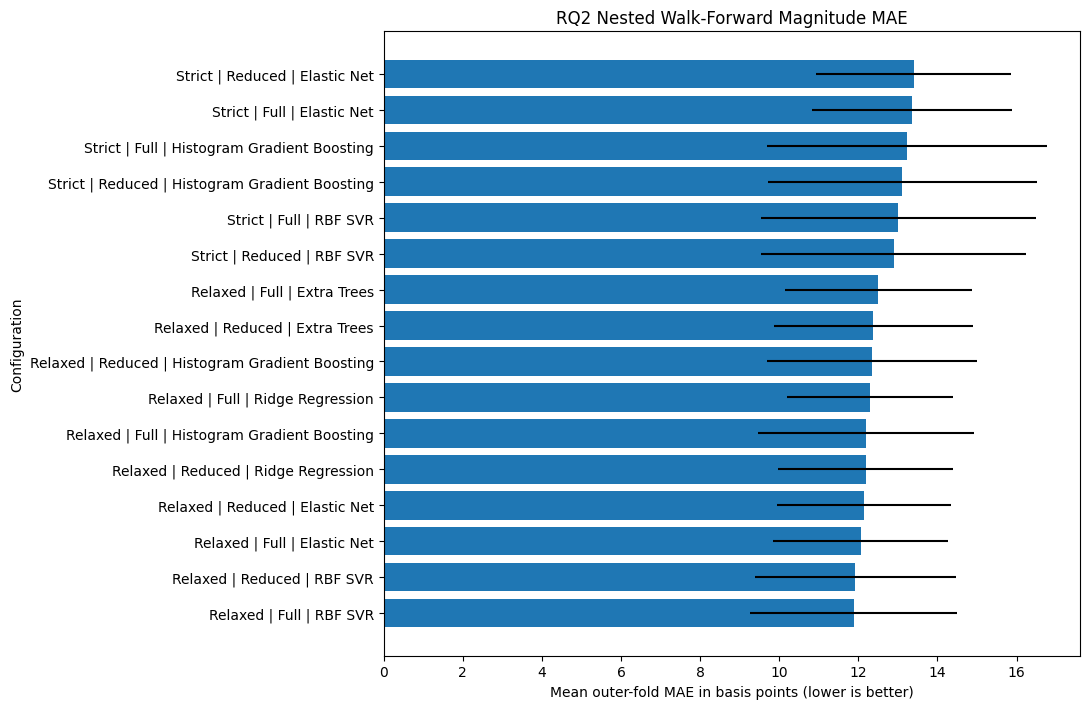

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq2_nested_mae.png


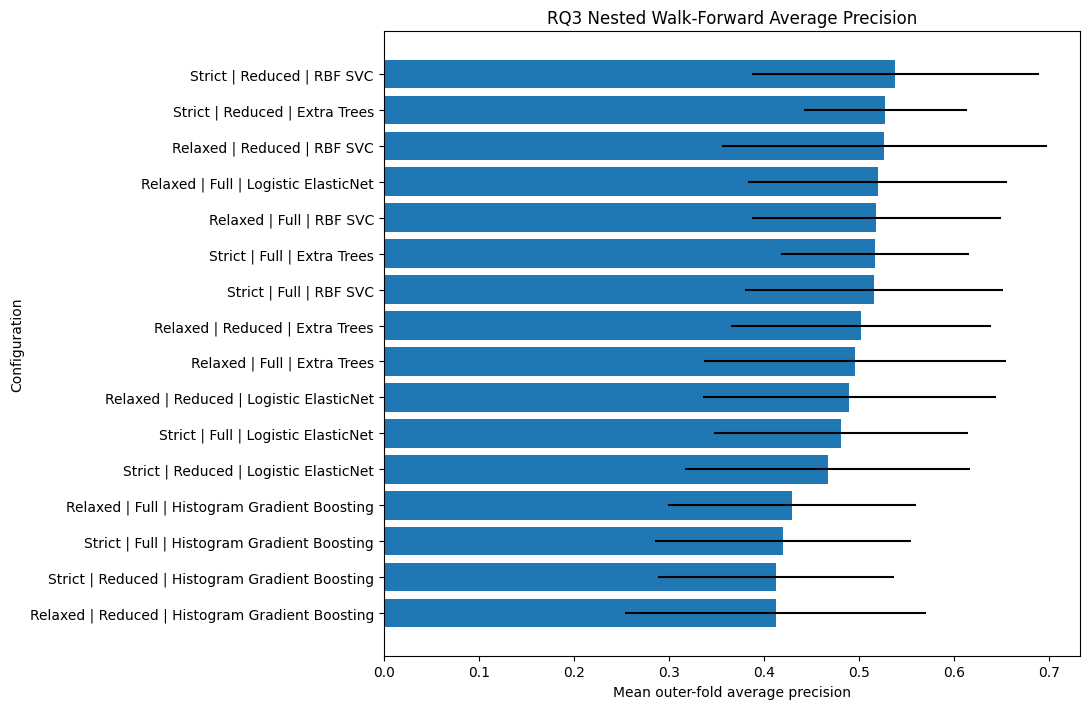

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq3_nested_average_precision.png


In [74]:
# I use this cell for ranking and stability charts.
def nested_ranking_plot(
    results: pd.DataFrame,
    metric: str,
    variability: str,
    title: str,
    xlabel: str,
    filename: str,
    higher_is_better: bool,
    top_n: int = 16,
):
    plot_data = results.copy()

    plot_data["configuration"] = (
        plot_data["dataset_variant"]
        + " | "
        + plot_data["feature_set"]
        + " | "
        + plot_data["model"]
    )

    plot_data = plot_data.sort_values(
        metric,
        ascending=not higher_is_better,
    ).head(top_n)

    plot_data = plot_data.sort_values(metric)

    fig, ax = plt.subplots(
        figsize=(11, max(6, len(plot_data) * 0.45))
    )

    ax.barh(
        plot_data["configuration"],
        plot_data[metric],
        xerr=plot_data[variability],
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Configuration")

    path = save_figure(fig, filename)
    plt.show()

    print("Saved:", path)


nested_ranking_plot(
    rq1_tuning_summary,
    metric="outer_balanced_accuracy_mean",
    variability="outer_balanced_accuracy_std",
    title="RQ1 Nested Walk-Forward Balanced Accuracy",
    xlabel="Mean outer-fold balanced accuracy",
    filename="rq1_nested_balanced_accuracy.png",
    higher_is_better=True,
)

nested_ranking_plot(
    rq2_tuning_summary,
    metric="outer_mae_bps_mean",
    variability="outer_mae_bps_std",
    title="RQ2 Nested Walk-Forward Magnitude MAE",
    xlabel="Mean outer-fold MAE in basis points (lower is better)",
    filename="rq2_nested_mae.png",
    higher_is_better=False,
)

nested_ranking_plot(
    rq3_tuning_summary,
    metric="outer_average_precision_mean",
    variability="outer_average_precision_std",
    title="RQ3 Nested Walk-Forward Average Precision",
    xlabel="Mean outer-fold average precision",
    filename="rq3_nested_average_precision.png",
    higher_is_better=True,
)

## 12. Select tuned development winners

Selection uses nested outer-fold performance only.

The selected configuration is then retuned on the full Train + Validation development period. This produces a final parameter set, but the original test period remains disabled by default.

In [75]:
# I use this cell for select tuned development winners.
rq1_winner = rq1_tuning_summary.iloc[0].to_dict()
rq2_winner = rq2_tuning_summary.iloc[0].to_dict()
rq3_winner = rq3_tuning_summary.iloc[0].to_dict()

tuned_winners = pd.DataFrame(
    [
        {
            "research_question": "RQ1 Direction",
            "dataset_variant": rq1_winner[
                "dataset_variant"
            ],
            "feature_set": rq1_winner["feature_set"],
            "model": rq1_winner["model"],
            "primary_metric": "Balanced accuracy",
            "outer_score": rq1_winner[
                "outer_balanced_accuracy_mean"
            ],
            "outer_standard_deviation": rq1_winner[
                "outer_balanced_accuracy_std"
            ],
        },
        {
            "research_question": "RQ2 Magnitude",
            "dataset_variant": rq2_winner[
                "dataset_variant"
            ],
            "feature_set": rq2_winner["feature_set"],
            "model": rq2_winner["model"],
            "primary_metric": "MAE in basis points",
            "outer_score": rq2_winner[
                "outer_mae_bps_mean"
            ],
            "outer_standard_deviation": rq2_winner[
                "outer_mae_bps_std"
            ],
        },
        {
            "research_question": "RQ3 Large Movement",
            "dataset_variant": rq3_winner[
                "dataset_variant"
            ],
            "feature_set": rq3_winner["feature_set"],
            "model": rq3_winner["model"],
            "primary_metric": "Average precision",
            "outer_score": rq3_winner[
                "outer_average_precision_mean"
            ],
            "outer_standard_deviation": rq3_winner[
                "outer_average_precision_std"
            ],
        },
    ]
)

display(tuned_winners)

TUNED_WINNERS_PATH = (
    TABLE_ROOT
    / "nested_tuned_winners.csv"
)

tuned_winners.to_csv(
    TUNED_WINNERS_PATH,
    index=False,
)

print("Saved:", TUNED_WINNERS_PATH)

,research_question,dataset_variant,feature_set,model,primary_metric,outer_score,outer_standard_deviation
0,RQ1 Direction,Strict,Full,Extra Trees,Balanced accuracy,0.537304,0.025552
1,RQ2 Magnitude,Relaxed,Full,RBF SVR,MAE in basis points,11.879533,2.619790
2,RQ3 Large Movement,Strict,Reduced,RBF SVC,Average precision,0.538148,0.151081


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\tables\nested_tuned_winners.csv


## 13. Final development-period searches

This stage derives a reproducible final parameter configuration for each research question.

It still uses only Train + Validation.

In [76]:
# I use this cell for final development-period searches.
def final_development_search(
    winner: dict,
    task_type: str,
    target_column: str,
    scoring: str,
):
    variant_name = winner["dataset_variant"]
    feature_set_name = winner["feature_set"]
    model_name = winner["model"]

    frame = development_frame(
        datasets[variant_name]
    )

    features = FEATURE_SETS[
        feature_set_name
    ]

    X = frame[features]
    y = frame[target_column]

    if task_type == "classification":
        specification = (
            CLASSIFICATION_SEARCH_SPACES[
                model_name
            ]
        )
    elif task_type == "regression":
        specification = (
            REGRESSION_SEARCH_SPACES[
                model_name
            ]
        )
    else:
        raise ValueError(task_type)

    search = RandomizedSearchCV(
        estimator=clone(
            specification["estimator"]
        ),
        param_distributions=(
            specification["parameters"]
        ),
        n_iter=max(
            N_RANDOM_SEARCH_ITERATIONS * 2,
            12,
        ),
        scoring=scoring,
        cv=TimeSeriesSplit(
            n_splits=max(
                INNER_SPLITS + 1,
                4,
            )
        ),
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=False,
    )

    search.fit(X, y)

    return {
        "dataset_variant": variant_name,
        "feature_set": feature_set_name,
        "features": features,
        "model": model_name,
        "best_parameters": search.best_params_,
        "best_inner_score": search.best_score_,
        "estimator": search.best_estimator_,
    }


rq1_final_development = final_development_search(
    rq1_winner,
    task_type="classification",
    target_column="target_up",
    scoring="balanced_accuracy",
)

rq2_final_development = final_development_search(
    rq2_winner,
    task_type="regression",
    target_column="target_magnitude_bps",
    scoring="neg_mean_absolute_error",
)

rq3_final_development = final_development_search(
    rq3_winner,
    task_type="classification",
    target_column="target_large_move",
    scoring="average_precision",
)

final_configuration_manifest = {
    "RQ1": {
        key: value
        for key, value in rq1_final_development.items()
        if key != "estimator"
    },
    "RQ2": {
        key: value
        for key, value in rq2_final_development.items()
        if key != "estimator"
    },
    "RQ3": {
        key: value
        for key, value in rq3_final_development.items()
        if key != "estimator"
    },
    "large_move_threshold_bps": (
        LARGE_MOVE_THRESHOLD_BPS
    ),
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "random_search_iterations": (
        N_RANDOM_SEARCH_ITERATIONS
    ),
    "primary_evidence": (
        "Nested expanding-window development-period performance"
    ),
    "existing_test_status": (
        "Previously viewed in baseline notebook; not fresh"
    ),
}

CONFIGURATION_PATH = (
    TUNING_ROOT
    / "final_tuned_configuration_manifest.json"
)

with open(
    CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        final_configuration_manifest,
        configuration_file,
        indent=2,
        default=str,
    )

print(
    json.dumps(
        final_configuration_manifest,
        indent=2,
        default=str,
    )
)

print("Saved:", CONFIGURATION_PATH)

{
  "RQ1": {
    "dataset_variant": "Strict",
    "feature_set": "Full",
    "features": [
      "ret_open_to_1500",
      "ret_last_15m",
      "ret_last_30m",
      "ret_last_60m",
      "momentum_accel_60m_vs_prior",
      "vix_level_1500",
      "vix_ret_last_15m",
      "vix_ret_last_30m",
      "vix_ret_last_60m",
      "realized_vol_30m",
      "realized_vol_60m",
      "realized_vol_120m",
      "rv_open_to_1500",
      "spy_volume_last_30m",
      "spy_volume_last_60m",
      "spy_cum_volume_to_1500",
      "spy_volume_accel_60m_vs_avg",
      "spy_dist_from_vwap_pct",
      "position_in_day_range",
      "dist_from_day_high_pct",
      "dist_from_day_low_pct",
      "atr_pct_open_to_1500"
    ],
    "model": "Extra Trees",
    "best_parameters": {
      "model__bootstrap": true,
      "model__class_weight": "balanced",
      "model__max_depth": 8,
      "model__max_features": 0.8,
      "model__min_samples_leaf": 2,
      "model__min_samples_split": 3,
      "model__n_estimat

## 14. Selected-winner robustness diagnostics

This section reruns only the three selected model families inside the same nested outer folds. It adds:

- fold-matched rule and dummy benchmarks;
- the corrected RQ3 prevalence and average-precision lift comparison;
- permutation importance on every outer test fold;
- VIX, realised-volatility, and pre-15:00 trend regime analysis;
- RQ1 confidence-versus-coverage analysis.

Regime thresholds are estimated from each outer training fold and then applied to its later outer test fold. Confidence ranks are also calculated separately within each outer fold so that probability and decision-function scales remain comparable. These analyses are descriptive robustness checks on the selected winners; they do not replace evaluation on the new untouched final holdout.

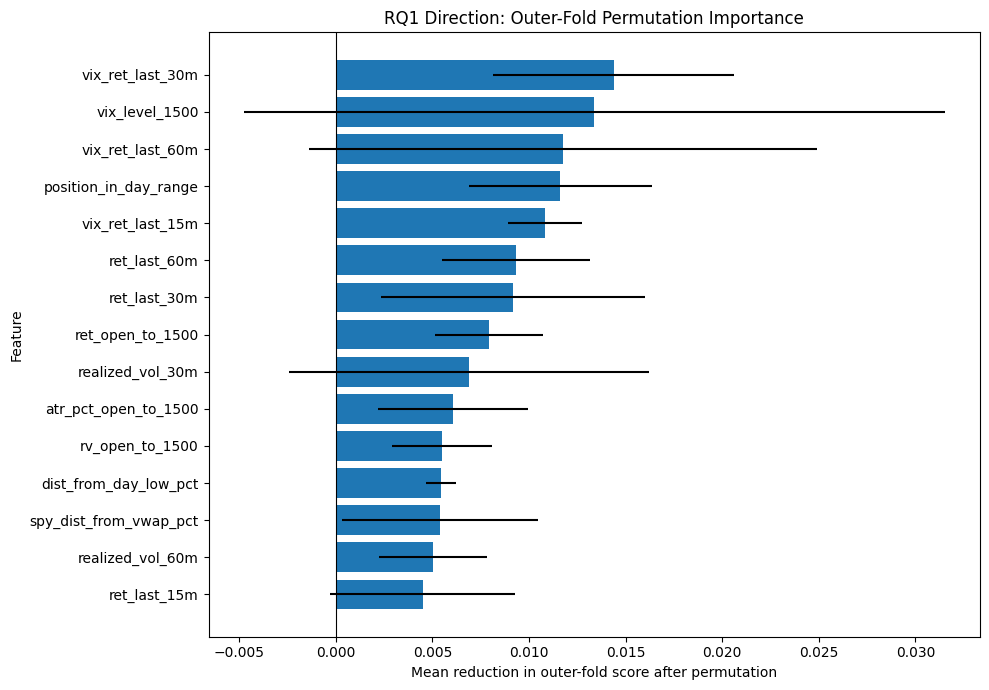

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq1_outer_fold_permutation_importance.png


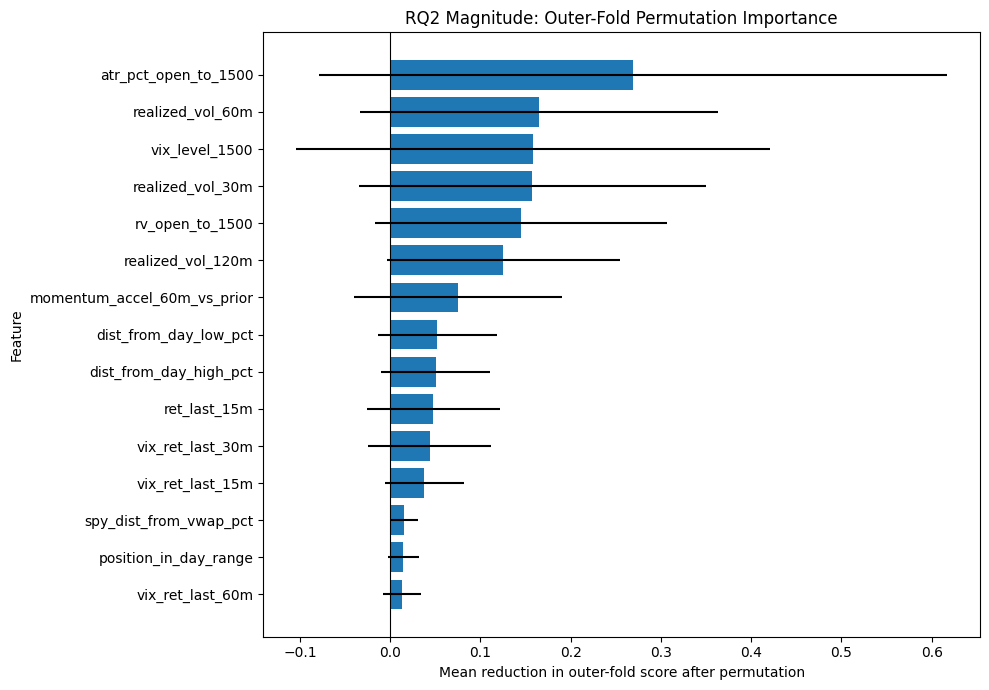

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq2_outer_fold_permutation_importance.png


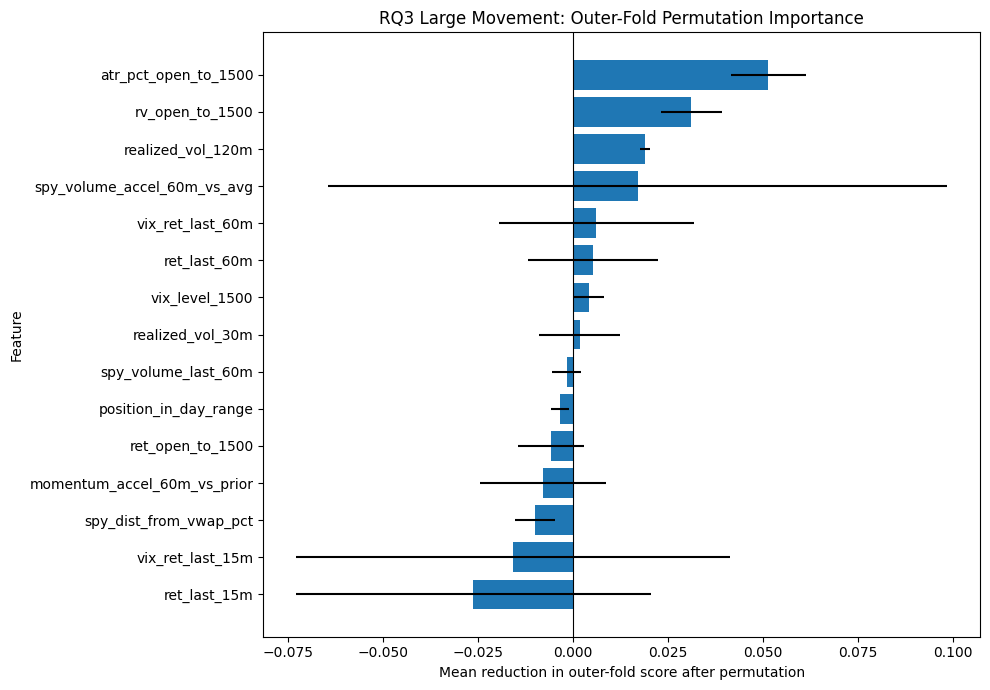

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq3_outer_fold_permutation_importance.png


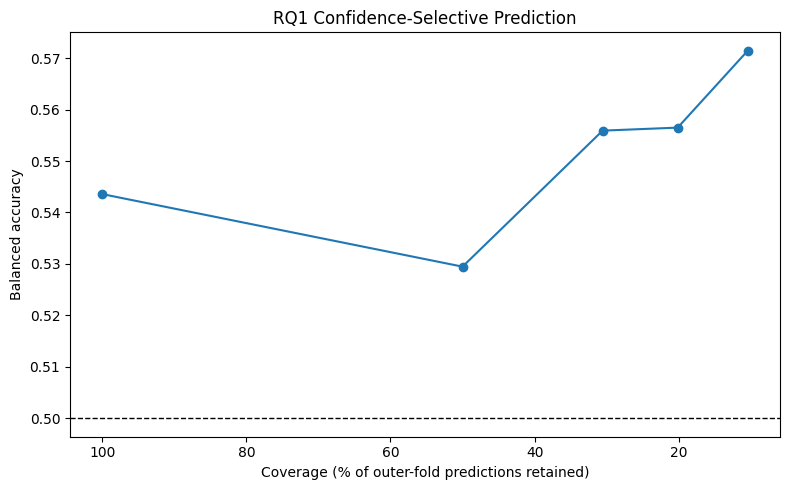

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\hyperparameter_tuning\figures\rq1_selective_prediction_coverage.png
Fold-matched benchmark summary


,research_question,benchmark,metric,outer_folds,model_score_mean,model_score_std,benchmark_score_mean,benchmark_score_std,absolute_improvement_mean,absolute_improvement_std,relative_improvement_mean
0,RQ1 Direction,15-minute mean reversion,Balanced accuracy,3,0.537304,0.025552,0.550448,0.036723,-0.013145,0.017552,-0.022870
1,RQ1 Direction,15-minute momentum,Balanced accuracy,3,0.537304,0.025552,0.449552,0.036723,0.087752,0.060785,0.203753
2,RQ1 Direction,60-minute mean reversion,Balanced accuracy,3,0.537304,0.025552,0.547315,0.041839,-0.010012,0.030080,-0.016052
3,RQ1 Direction,60-minute momentum,Balanced accuracy,3,0.537304,0.025552,0.452685,0.041839,0.084619,0.062466,0.195689
4,RQ1 Direction,Previous-session direction,Balanced accuracy,3,0.537304,0.025552,0.473081,0.052320,0.064223,0.027891,0.140848
5,RQ1 Direction,Training majority,Balanced accuracy,3,0.537304,0.025552,0.500000,0.000000,0.037304,0.025552,0.074608
6,RQ2 Magnitude,Outer-training median,MAE (basis points),3,11.879533,2.619790,13.018164,3.607407,1.138631,1.007778,0.078535
7,RQ3 Large Movement,Outer-test prevalence,Average precision,3,0.538148,0.151081,0.238426,0.101668,0.299722,0.081766,1.360693


Feature-importance stability


,research_question,feature,feature_group,outer_folds,mean_importance,between_fold_std,mean_within_fold_std,positive_fold_share,top_five_fold_count
0,RQ1 Direction,vix_ret_last_30m,VIX,3,0.014384,0.006226,0.007502,1.000000,3
1,RQ1 Direction,vix_level_1500,VIX,3,0.013380,0.018149,0.010426,0.666667,2
2,RQ1 Direction,vix_ret_last_60m,VIX,3,0.011766,0.013147,0.005993,1.000000,1
3,RQ1 Direction,position_in_day_range,Price position,3,0.011628,0.004752,0.012366,1.000000,2
4,RQ1 Direction,vix_ret_last_15m,VIX,3,0.010847,0.001912,0.008835,1.000000,2
5,RQ1 Direction,ret_last_60m,SPX momentum,3,0.009325,0.003810,0.006894,1.000000,1
6,RQ1 Direction,ret_last_30m,SPX momentum,3,0.009178,0.006840,0.005661,1.000000,1
7,RQ1 Direction,ret_open_to_1500,SPX momentum,3,0.007932,0.002790,0.008806,1.000000,1
8,RQ1 Direction,realized_vol_30m,Realised volatility,3,0.006891,0.009309,0.008019,0.666667,1
9,RQ1 Direction,atr_pct_open_to_1500,True range,3,0.006073,0.003867,0.008168,1.000000,1


Feature-group stability


,research_question,feature_group,mean_importance_per_feature,between_fold_std,positive_fold_share
0,RQ1 Direction,VIX,0.012594,0.009159,1.000000
1,RQ1 Direction,SPX momentum,0.007054,0.002503,1.000000
2,RQ1 Direction,Price position,0.006632,0.001478,1.000000
3,RQ1 Direction,True range,0.006073,0.003867,1.000000
4,RQ1 Direction,Realised volatility,0.005336,0.004666,1.000000
5,RQ1 Direction,SPY volume,-0.000870,0.005156,0.333333
6,RQ2 Magnitude,True range,0.269512,0.347843,1.000000
7,RQ2 Magnitude,Realised volatility,0.148316,0.159601,0.666667
8,RQ2 Magnitude,VIX,0.063146,0.096889,1.000000
9,RQ2 Magnitude,Price position,0.033010,0.036495,1.000000


Regime analysis


,research_question,regime_type,regime,sessions,minimum_sample_met,first_date,last_date,balanced_accuracy,accuracy,mcc,positive_rate,mae_bps,rmse_bps,r2,spearman,average_precision,prevalence,average_precision_lift,precision,recall,f1
0,RQ1 Direction,VIX regime,High,149,True,2023-10-19,2026-01-20,0.548551,0.530201,0.111082,0.463087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RQ1 Direction,VIX regime,Low,128,True,2023-11-02,2026-01-23,0.537879,0.523438,0.195414,0.484375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RQ1 Direction,VIX regime,Medium,155,True,2023-10-31,2026-01-28,0.538455,0.554839,0.112248,0.522581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RQ1 Direction,Realised-volatility regime,High,138,True,2023-10-19,2026-01-28,0.607475,0.623188,0.239966,0.536232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RQ1 Direction,Realised-volatility regime,Low,187,True,2023-11-02,2026-01-26,0.523123,0.534759,0.094323,0.513369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,RQ1 Direction,Realised-volatility regime,Medium,107,True,2023-10-30,2026-01-20,0.509707,0.429907,0.028112,0.392523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,RQ1 Direction,Pre-15:00 trend,Negative pre-15:00 return,222,True,2023-10-19,2026-01-28,0.564692,0.567568,0.168313,0.504505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RQ1 Direction,Pre-15:00 trend,Positive pre-15:00 return,210,True,2023-10-23,2026-01-26,0.523182,0.504762,0.072780,0.476190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RQ2 Magnitude,VIX regime,High,167,True,2024-04-15,2026-01-20,NaN,NaN,NaN,NaN,17.794145,28.960335,0.101000,0.407477,NaN,NaN,NaN,NaN,NaN,NaN
9,RQ2 Magnitude,VIX regime,Low,163,True,2023-11-03,2025-12-30,NaN,NaN,NaN,NaN,10.022012,16.921009,0.096240,0.335334,NaN,NaN,NaN,NaN,NaN,NaN


RQ1 selective-prediction analysis


,requested_coverage,realised_coverage,sessions,balanced_accuracy,accuracy,precision,recall,f1,mcc,positive_rate,mean_confidence_percentile
0,1.000000,1.000000,432,0.543568,0.537037,0.516304,0.896226,0.655172,0.122620,0.490741,0.503472
1,0.500000,0.500000,216,0.529472,0.518519,0.502591,0.923810,0.651007,0.095512,0.486111,0.753472
2,0.300000,0.305556,132,0.555901,0.537879,0.508475,0.952381,0.662983,0.181358,0.477273,0.850694
3,0.200000,0.201389,87,0.556486,0.494253,0.455696,0.972973,0.620690,0.193287,0.425287,0.902778
4,0.100000,0.104167,45,0.571429,0.466667,0.414634,1.000000,0.586207,0.243379,0.377778,0.951389


In [77]:
# Configuration for post-selection robustness diagnostics.
PERMUTATION_REPEATS = 20
MIN_REGIME_SESSIONS = 10
SELECTIVE_COVERAGES = [1.00, 0.50, 0.30, 0.20, 0.10]

FEATURE_GROUPS = {
    "ret_open_to_1500": "SPX momentum",
    "ret_last_15m": "SPX momentum",
    "ret_last_30m": "SPX momentum",
    "ret_last_60m": "SPX momentum",
    "momentum_accel_60m_vs_prior": "SPX momentum",
    "vix_level_1500": "VIX",
    "vix_ret_last_15m": "VIX",
    "vix_ret_last_30m": "VIX",
    "vix_ret_last_60m": "VIX",
    "realized_vol_30m": "Realised volatility",
    "realized_vol_60m": "Realised volatility",
    "realized_vol_120m": "Realised volatility",
    "rv_open_to_1500": "Realised volatility",
    "spy_volume_last_30m": "SPY volume",
    "spy_volume_last_60m": "SPY volume",
    "spy_cum_volume_to_1500": "SPY volume",
    "spy_volume_accel_60m_vs_avg": "SPY volume",
    "spy_dist_from_vwap_pct": "Price position",
    "position_in_day_range": "Price position",
    "dist_from_day_high_pct": "Price position",
    "dist_from_day_low_pct": "Price position",
    "atr_pct_open_to_1500": "True range",
}


def _selected_specification(
    winner: dict,
    task_type: str,
):
    model_name = winner["model"]

    if task_type == "classification":
        return CLASSIFICATION_SEARCH_SPACES[model_name]

    if task_type == "regression":
        return REGRESSION_SEARCH_SPACES[model_name]

    raise ValueError(f"Unsupported task type: {task_type}")


def _relative_improvement(
    model_score: float,
    benchmark_score: float,
    higher_is_better: bool,
) -> float:
    if not np.isfinite(benchmark_score) or benchmark_score == 0:
        return np.nan

    if higher_is_better:
        return (model_score - benchmark_score) / abs(benchmark_score)

    return (benchmark_score - model_score) / abs(benchmark_score)


def _three_level_regime(
    values: pd.Series,
    lower_cutoff: float,
    upper_cutoff: float,
) -> pd.Series:
    return pd.Series(
        np.select(
            [
                values <= lower_cutoff,
                values >= upper_cutoff,
            ],
            ["Low", "High"],
            default="Medium",
        ),
        index=values.index,
        dtype="object",
    )


def _rq1_benchmark_predictions(
    development: pd.DataFrame,
    outer_train_index: np.ndarray,
    outer_test_index: np.ndarray,
) -> dict[str, np.ndarray]:
    y_outer_train = development.iloc[outer_train_index][
        "target_up"
    ].astype(int)

    majority_class = int(y_outer_train.mode().iloc[0])

    previous_direction = (
        development["target_up"]
        .shift(1)
        .iloc[outer_test_index]
        .fillna(majority_class)
        .astype(int)
        .to_numpy()
    )

    test_rows = development.iloc[outer_test_index]

    return {
        "Training majority": np.full(
            len(outer_test_index),
            majority_class,
            dtype=int,
        ),
        "Previous-session direction": previous_direction,
        "15-minute momentum": (
            test_rows["ret_last_15m"] >= 0
        ).astype(int).to_numpy(),
        "15-minute mean reversion": (
            test_rows["ret_last_15m"] < 0
        ).astype(int).to_numpy(),
        "60-minute momentum": (
            test_rows["ret_last_60m"] >= 0
        ).astype(int).to_numpy(),
        "60-minute mean reversion": (
            test_rows["ret_last_60m"] < 0
        ).astype(int).to_numpy(),
    }


def selected_winner_outer_diagnostics(
    winner: dict,
    research_question: str,
    task_type: str,
    target_column: str,
    search_scoring: str,
    threshold_objective: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Re-run the selected model family within each outer fold.

    This preserves the original nested structure while collecting
    session-level predictions, fold-matched benchmarks, and permutation
    importance on each outer test fold.
    """
    variant_name = winner["dataset_variant"]
    feature_set_name = winner["feature_set"]
    features = FEATURE_SETS[feature_set_name]

    development = development_frame(
        datasets[variant_name]
    )

    X = development[features]
    y = development[target_column]

    if task_type == "classification":
        y = y.astype(int)

    specification = _selected_specification(
        winner,
        task_type,
    )

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    prediction_rows = []
    benchmark_rows = []
    importance_rows = []

    for outer_fold, (
        outer_train_index,
        outer_test_index,
    ) in enumerate(
        outer_splitter.split(X),
        start=1,
    ):
        X_outer_train = X.iloc[outer_train_index]
        y_outer_train = y.iloc[outer_train_index]
        X_outer_test = X.iloc[outer_test_index]
        y_outer_test = y.iloc[outer_test_index]

        inner_splitter = TimeSeriesSplit(
            n_splits=INNER_SPLITS
        )

        search = RandomizedSearchCV(
            estimator=clone(
                specification["estimator"]
            ),
            param_distributions=(
                specification["parameters"]
            ),
            n_iter=N_RANDOM_SEARCH_ITERATIONS,
            scoring=search_scoring,
            cv=inner_splitter,
            refit=True,
            random_state=RANDOM_STATE + outer_fold,
            n_jobs=-1,
            return_train_score=False,
        )

        search.fit(
            X_outer_train,
            y_outer_train,
        )

        best_estimator = search.best_estimator_
        threshold = np.nan

        if task_type == "classification":
            inner_y, inner_scores = inner_time_series_scores(
                best_estimator,
                X_outer_train.reset_index(drop=True),
                y_outer_train.reset_index(drop=True),
                n_splits=INNER_SPLITS,
            )

            threshold, _ = select_threshold(
                inner_y,
                inner_scores,
                objective=threshold_objective,
            )

            outer_scores = model_scores(
                best_estimator,
                X_outer_test,
            )

            outer_predictions = (
                outer_scores >= threshold
            ).astype(int)

            model_metrics = classification_metric_bundle(
                y_outer_test,
                outer_predictions,
                outer_scores,
            )
        else:
            outer_scores = best_estimator.predict(
                X_outer_test
            )
            outer_predictions = outer_scores
            model_metrics = regression_metric_bundle(
                y_outer_test,
                outer_predictions,
            )

        outer_test_rows = development.iloc[
            outer_test_index
        ].copy()

        vix_lower, vix_upper = (
            development.iloc[outer_train_index][
                "vix_level_1500"
            ].quantile([1 / 3, 2 / 3])
        )

        rv_lower, rv_upper = (
            development.iloc[outer_train_index][
                "realized_vol_60m"
            ].quantile([1 / 3, 2 / 3])
        )

        vix_regime = _three_level_regime(
            outer_test_rows["vix_level_1500"],
            float(vix_lower),
            float(vix_upper),
        )

        realized_vol_regime = _three_level_regime(
            outer_test_rows["realized_vol_60m"],
            float(rv_lower),
            float(rv_upper),
        )

        trend_regime = np.where(
            outer_test_rows["ret_open_to_1500"] >= 0,
            "Positive pre-15:00 return",
            "Negative pre-15:00 return",
        )

        if task_type == "classification":
            confidence_raw = np.abs(
                outer_scores - threshold
            )
            confidence_percentile = (
                pd.Series(confidence_raw)
                .rank(method="average", pct=True)
                .to_numpy()
            )
            score_percentile = (
                pd.Series(outer_scores)
                .rank(method="average", pct=True)
                .to_numpy()
            )
        else:
            confidence_raw = np.full(
                len(outer_test_index),
                np.nan,
            )
            confidence_percentile = np.full(
                len(outer_test_index),
                np.nan,
            )
            score_percentile = (
                pd.Series(outer_scores)
                .rank(method="average", pct=True)
                .to_numpy()
            )

        for row_position, source_index in enumerate(
            outer_test_index
        ):
            prediction_rows.append(
                {
                    "research_question": research_question,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": winner["model"],
                    "outer_fold": outer_fold,
                    "session_date": development.iloc[
                        source_index
                    ]["session_date"],
                    "y_true": float(
                        y_outer_test.iloc[row_position]
                    ),
                    "prediction": float(
                        outer_predictions[row_position]
                    ),
                    "score": float(
                        outer_scores[row_position]
                    ),
                    "threshold": float(threshold)
                    if np.isfinite(threshold)
                    else np.nan,
                    "confidence_raw": float(
                        confidence_raw[row_position]
                    )
                    if np.isfinite(
                        confidence_raw[row_position]
                    )
                    else np.nan,
                    "confidence_percentile": float(
                        confidence_percentile[row_position]
                    )
                    if np.isfinite(
                        confidence_percentile[row_position]
                    )
                    else np.nan,
                    "score_percentile": float(
                        score_percentile[row_position]
                    ),
                    "vix_regime": vix_regime.iloc[
                        row_position
                    ],
                    "realized_vol_regime": (
                        realized_vol_regime.iloc[
                            row_position
                        ]
                    ),
                    "intraday_trend_regime": (
                        trend_regime[row_position]
                    ),
                }
            )

        test_start = outer_test_rows[
            "session_date"
        ].min()
        test_end = outer_test_rows[
            "session_date"
        ].max()

        if research_question == "RQ1 Direction":
            model_score = model_metrics[
                "balanced_accuracy"
            ]

            benchmarks = _rq1_benchmark_predictions(
                development,
                outer_train_index,
                outer_test_index,
            )

            for benchmark_name, benchmark_predictions in (
                benchmarks.items()
            ):
                benchmark_score = balanced_accuracy_score(
                    y_outer_test,
                    benchmark_predictions,
                )

                benchmark_rows.append(
                    {
                        "research_question": research_question,
                        "outer_fold": outer_fold,
                        "outer_test_start": test_start,
                        "outer_test_end": test_end,
                        "benchmark": benchmark_name,
                        "metric": "Balanced accuracy",
                        "model_score": model_score,
                        "benchmark_score": benchmark_score,
                        "absolute_improvement": (
                            model_score - benchmark_score
                        ),
                        "relative_improvement": (
                            _relative_improvement(
                                model_score,
                                benchmark_score,
                                higher_is_better=True,
                            )
                        ),
                    }
                )

        elif research_question == "RQ2 Magnitude":
            model_score = model_metrics["mae_bps"]
            dummy_value = float(
                y_outer_train.median()
            )
            dummy_predictions = np.full(
                len(y_outer_test),
                dummy_value,
            )
            benchmark_score = mean_absolute_error(
                y_outer_test,
                dummy_predictions,
            )

            benchmark_rows.append(
                {
                    "research_question": research_question,
                    "outer_fold": outer_fold,
                    "outer_test_start": test_start,
                    "outer_test_end": test_end,
                    "benchmark": "Outer-training median",
                    "metric": "MAE (basis points)",
                    "model_score": model_score,
                    "benchmark_score": benchmark_score,
                    "absolute_improvement": (
                        benchmark_score - model_score
                    ),
                    "relative_improvement": (
                        _relative_improvement(
                            model_score,
                            benchmark_score,
                            higher_is_better=False,
                        )
                    ),
                }
            )

        elif research_question == "RQ3 Large Movement":
            model_score = model_metrics[
                "average_precision"
            ]
            benchmark_score = float(
                y_outer_test.mean()
            )

            benchmark_rows.append(
                {
                    "research_question": research_question,
                    "outer_fold": outer_fold,
                    "outer_test_start": test_start,
                    "outer_test_end": test_end,
                    "benchmark": "Outer-test prevalence",
                    "metric": "Average precision",
                    "model_score": model_score,
                    "benchmark_score": benchmark_score,
                    "absolute_improvement": (
                        model_score - benchmark_score
                    ),
                    "relative_improvement": (
                        _relative_improvement(
                            model_score,
                            benchmark_score,
                            higher_is_better=True,
                        )
                    ),
                }
            )

        if research_question == "RQ1 Direction":
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_scores = model_scores(
                    fitted_estimator,
                    X_evaluation,
                )
                evaluation_predictions = (
                    evaluation_scores >= threshold
                ).astype(int)
                return balanced_accuracy_score(
                    y_evaluation,
                    evaluation_predictions,
                )

        elif research_question == "RQ3 Large Movement":
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_scores = model_scores(
                    fitted_estimator,
                    X_evaluation,
                )
                return safe_average_precision(
                    y_evaluation,
                    evaluation_scores,
                )

        else:
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_predictions = (
                    fitted_estimator.predict(
                        X_evaluation
                    )
                )
                return -mean_absolute_error(
                    y_evaluation,
                    evaluation_predictions,
                )

        permutation = permutation_importance(
            best_estimator,
            X_outer_test,
            y_outer_test,
            scoring=importance_scorer,
            n_repeats=PERMUTATION_REPEATS,
            random_state=(
                RANDOM_STATE + 1_000 + outer_fold
            ),
            n_jobs=1,
        )

        for feature, mean_importance, std_importance in zip(
            features,
            permutation.importances_mean,
            permutation.importances_std,
        ):
            importance_rows.append(
                {
                    "research_question": research_question,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": winner["model"],
                    "outer_fold": outer_fold,
                    "feature": feature,
                    "feature_group": FEATURE_GROUPS.get(
                        feature,
                        "Other",
                    ),
                    "importance_mean": float(
                        mean_importance
                    ),
                    "importance_std_within_fold": float(
                        std_importance
                    ),
                }
            )

    return (
        pd.DataFrame(prediction_rows),
        pd.DataFrame(benchmark_rows),
        pd.DataFrame(importance_rows),
    )


rq1_oof_predictions, rq1_fold_benchmarks, rq1_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq1_winner,
        research_question="RQ1 Direction",
        task_type="classification",
        target_column="target_up",
        search_scoring="balanced_accuracy",
        threshold_objective="balanced_accuracy",
    )
)

rq2_oof_predictions, rq2_fold_benchmarks, rq2_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq2_winner,
        research_question="RQ2 Magnitude",
        task_type="regression",
        target_column="target_magnitude_bps",
        search_scoring="neg_mean_absolute_error",
    )
)

rq3_oof_predictions, rq3_fold_benchmarks, rq3_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq3_winner,
        research_question="RQ3 Large Movement",
        task_type="classification",
        target_column="target_large_move",
        search_scoring="average_precision",
        threshold_objective="f1",
    )
)

selected_oof_predictions = pd.concat(
    [
        rq1_oof_predictions,
        rq2_oof_predictions,
        rq3_oof_predictions,
    ],
    ignore_index=True,
)

fold_matched_benchmarks = pd.concat(
    [
        rq1_fold_benchmarks,
        rq2_fold_benchmarks,
        rq3_fold_benchmarks,
    ],
    ignore_index=True,
)

outer_fold_feature_importance = pd.concat(
    [
        rq1_fold_importance,
        rq2_fold_importance,
        rq3_fold_importance,
    ],
    ignore_index=True,
)

benchmark_summary = (
    fold_matched_benchmarks
    .groupby(
        [
            "research_question",
            "benchmark",
            "metric",
        ],
        as_index=False,
    )
    .agg(
        outer_folds=("outer_fold", "nunique"),
        model_score_mean=("model_score", "mean"),
        model_score_std=("model_score", "std"),
        benchmark_score_mean=(
            "benchmark_score",
            "mean",
        ),
        benchmark_score_std=(
            "benchmark_score",
            "std",
        ),
        absolute_improvement_mean=(
            "absolute_improvement",
            "mean",
        ),
        absolute_improvement_std=(
            "absolute_improvement",
            "std",
        ),
        relative_improvement_mean=(
            "relative_improvement",
            "mean",
        ),
    )
)

importance_ranked = outer_fold_feature_importance.copy()
importance_ranked["fold_rank"] = (
    importance_ranked
    .groupby(
        ["research_question", "outer_fold"]
    )["importance_mean"]
    .rank(method="min", ascending=False)
)
importance_ranked["top_five"] = (
    importance_ranked["fold_rank"] <= 5
)
importance_ranked["positive_importance"] = (
    importance_ranked["importance_mean"] > 0
)

feature_importance_stability = (
    importance_ranked
    .groupby(
        [
            "research_question",
            "feature",
            "feature_group",
        ],
        as_index=False,
    )
    .agg(
        outer_folds=("outer_fold", "nunique"),
        mean_importance=("importance_mean", "mean"),
        between_fold_std=("importance_mean", "std"),
        mean_within_fold_std=(
            "importance_std_within_fold",
            "mean",
        ),
        positive_fold_share=(
            "positive_importance",
            "mean",
        ),
        top_five_fold_count=("top_five", "sum"),
    )
    .sort_values(
        ["research_question", "mean_importance"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# Average within each feature group first, so groups with more variables
# are not automatically favoured by a simple sum.
group_fold_importance = (
    importance_ranked
    .groupby(
        [
            "research_question",
            "outer_fold",
            "feature_group",
        ],
        as_index=False,
    )["importance_mean"]
    .mean()
)

feature_group_importance = (
    group_fold_importance
    .groupby(
        ["research_question", "feature_group"],
        as_index=False,
    )
    .agg(
        mean_importance_per_feature=(
            "importance_mean",
            "mean",
        ),
        between_fold_std=(
            "importance_mean",
            "std",
        ),
        positive_fold_share=(
            "importance_mean",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
    )
    .sort_values(
        [
            "research_question",
            "mean_importance_per_feature",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


def build_regime_analysis(
    predictions: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    regime_columns = {
        "VIX regime": "vix_regime",
        "Realised-volatility regime": (
            "realized_vol_regime"
        ),
        "Pre-15:00 trend": (
            "intraday_trend_regime"
        ),
    }

    for research_question, rq_frame in predictions.groupby(
        "research_question"
    ):
        for regime_type, regime_column in (
            regime_columns.items()
        ):
            for regime_name, group in rq_frame.groupby(
                regime_column
            ):
                y_true = group["y_true"].to_numpy()
                prediction = group[
                    "prediction"
                ].to_numpy()
                score = group["score"].to_numpy()

                common = {
                    "research_question": research_question,
                    "regime_type": regime_type,
                    "regime": regime_name,
                    "sessions": len(group),
                    "minimum_sample_met": (
                        len(group) >= MIN_REGIME_SESSIONS
                    ),
                    "first_date": group[
                        "session_date"
                    ].min(),
                    "last_date": group[
                        "session_date"
                    ].max(),
                }

                if research_question == "RQ1 Direction":
                    metrics = classification_metric_bundle(
                        y_true.astype(int),
                        prediction.astype(int),
                        score,
                    )
                    rows.append(
                        {
                            **common,
                            "balanced_accuracy": metrics[
                                "balanced_accuracy"
                            ],
                            "accuracy": metrics["accuracy"],
                            "mcc": metrics["mcc"],
                            "positive_rate": float(
                                np.mean(y_true)
                            ),
                        }
                    )

                elif research_question == "RQ2 Magnitude":
                    metrics = regression_metric_bundle(
                        y_true,
                        prediction,
                    )
                    rows.append(
                        {
                            **common,
                            "mae_bps": metrics["mae_bps"],
                            "rmse_bps": metrics[
                                "rmse_bps"
                            ],
                            "r2": metrics["r2"],
                            "spearman": metrics[
                                "spearman"
                            ],
                        }
                    )

                else:
                    metrics = classification_metric_bundle(
                        y_true.astype(int),
                        prediction.astype(int),
                        score,
                    )
                    prevalence = float(
                        np.mean(y_true)
                    )
                    rows.append(
                        {
                            **common,
                            "average_precision": metrics[
                                "average_precision"
                            ],
                            "prevalence": prevalence,
                            "average_precision_lift": (
                                metrics["average_precision"]
                                - prevalence
                            ),
                            "precision": metrics[
                                "precision"
                            ],
                            "recall": metrics["recall"],
                            "f1": metrics["f1"],
                        }
                    )

    return pd.DataFrame(rows)


regime_analysis = build_regime_analysis(
    selected_oof_predictions
)


def build_selective_prediction_analysis(
    rq1_predictions: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for coverage in SELECTIVE_COVERAGES:
        minimum_percentile = 1.0 - coverage
        selected = rq1_predictions[
            rq1_predictions["confidence_percentile"]
            > minimum_percentile
        ].copy()

        if selected.empty:
            continue

        metrics = classification_metric_bundle(
            selected["y_true"].astype(int),
            selected["prediction"].astype(int),
            selected["score"],
        )

        rows.append(
            {
                "requested_coverage": coverage,
                "realised_coverage": (
                    len(selected) / len(rq1_predictions)
                ),
                "sessions": len(selected),
                "balanced_accuracy": metrics[
                    "balanced_accuracy"
                ],
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "mcc": metrics["mcc"],
                "positive_rate": selected[
                    "y_true"
                ].mean(),
                "mean_confidence_percentile": selected[
                    "confidence_percentile"
                ].mean(),
            }
        )

    return pd.DataFrame(rows)


selective_prediction_analysis = (
    build_selective_prediction_analysis(
        rq1_oof_predictions
    )
)


def feature_importance_plot(
    stability: pd.DataFrame,
    research_question: str,
    filename: str,
):
    plot_data = (
        stability[
            stability["research_question"].eq(
                research_question
            )
        ]
        .sort_values("mean_importance")
        .tail(15)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["feature"],
        plot_data["mean_importance"],
        xerr=plot_data["between_fold_std"].fillna(0),
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"{research_question}: Outer-Fold Permutation Importance"
    )
    ax.set_xlabel(
        "Mean reduction in outer-fold score after permutation"
    )
    ax.set_ylabel("Feature")

    path = save_figure(fig, filename)
    plt.show()
    print("Saved:", path)


feature_importance_plot(
    feature_importance_stability,
    "RQ1 Direction",
    "rq1_outer_fold_permutation_importance.png",
)
feature_importance_plot(
    feature_importance_stability,
    "RQ2 Magnitude",
    "rq2_outer_fold_permutation_importance.png",
)
feature_importance_plot(
    feature_importance_stability,
    "RQ3 Large Movement",
    "rq3_outer_fold_permutation_importance.png",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    selective_prediction_analysis[
        "realised_coverage"
    ] * 100,
    selective_prediction_analysis[
        "balanced_accuracy"
    ],
    marker="o",
)
ax.axhline(0.50, color="black", linestyle="--", linewidth=1)
ax.invert_xaxis()
ax.set_title("RQ1 Confidence-Selective Prediction")
ax.set_xlabel("Coverage (% of outer-fold predictions retained)")
ax.set_ylabel("Balanced accuracy")
SELECTIVE_FIGURE_PATH = save_figure(
    fig,
    "rq1_selective_prediction_coverage.png",
)
plt.show()
print("Saved:", SELECTIVE_FIGURE_PATH)

SELECTED_OOF_PATH = (
    TABLE_ROOT / "selected_winner_outer_fold_predictions.csv"
)
FOLD_BENCHMARK_PATH = (
    TABLE_ROOT / "fold_matched_benchmarks.csv"
)
BENCHMARK_SUMMARY_PATH = (
    TABLE_ROOT / "fold_matched_benchmark_summary.csv"
)
OUTER_IMPORTANCE_PATH = (
    TABLE_ROOT / "outer_fold_permutation_importance.csv"
)
FEATURE_STABILITY_PATH = (
    TABLE_ROOT / "feature_importance_stability.csv"
)
FEATURE_GROUP_PATH = (
    TABLE_ROOT / "feature_group_importance_stability.csv"
)
REGIME_ANALYSIS_PATH = (
    TABLE_ROOT / "selected_winner_regime_analysis.csv"
)
SELECTIVE_ANALYSIS_PATH = (
    TABLE_ROOT / "rq1_selective_prediction_analysis.csv"
)

selected_oof_predictions.to_csv(
    SELECTED_OOF_PATH,
    index=False,
)
fold_matched_benchmarks.to_csv(
    FOLD_BENCHMARK_PATH,
    index=False,
)
benchmark_summary.to_csv(
    BENCHMARK_SUMMARY_PATH,
    index=False,
)
outer_fold_feature_importance.to_csv(
    OUTER_IMPORTANCE_PATH,
    index=False,
)
feature_importance_stability.to_csv(
    FEATURE_STABILITY_PATH,
    index=False,
)
feature_group_importance.to_csv(
    FEATURE_GROUP_PATH,
    index=False,
)
regime_analysis.to_csv(
    REGIME_ANALYSIS_PATH,
    index=False,
)
selective_prediction_analysis.to_csv(
    SELECTIVE_ANALYSIS_PATH,
    index=False,
)

print("Fold-matched benchmark summary")
display(benchmark_summary)

print("Feature-importance stability")
display(feature_importance_stability)

print("Feature-group stability")
display(feature_group_importance)

print("Regime analysis")
display(regime_analysis)

print("RQ1 selective-prediction analysis")
display(selective_prediction_analysis)


## 16. Dissertation-ready interpretation generator

I generate a structured draft rather than a substitute for final academic editing.

It explicitly distinguishes:

- prediction from ranking;
- statistical improvement from practical usefulness;
- stable results from validation-specific results;
- negative findings from failed methodology.

In [78]:
rq1_best = rq1_tuning_summary.iloc[0]
rq2_best = rq2_tuning_summary.iloc[0]
rq3_best = rq3_tuning_summary.iloc[0]

rq1_benchmark_rows = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ1 Direction"
    )
].sort_values(
    "benchmark_score_mean",
    ascending=False,
)
rq1_strongest_benchmark = rq1_benchmark_rows.iloc[0]

rq2_dummy_benchmark = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ2 Magnitude"
    )
].iloc[0]

rq3_prevalence_benchmark = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ3 Large Movement"
    )
].iloc[0]

rq1_signal = (
    "limited evidence of directional predictability"
    if rq1_best["outer_balanced_accuracy_mean"] > 0.53
    else "no robust evidence of directional predictability"
)

if (
    rq2_best["outer_r2_mean"] >= 0.05
    and rq2_best["outer_spearman_mean"] >= 0.30
):
    rq2_signal = (
        "modest evidence that intraday features contain "
        "information about movement magnitude"
    )
elif rq2_best["outer_spearman_mean"] >= 0.25:
    rq2_signal = (
        "some evidence that the model can rank relative movement "
        "magnitude, but little evidence that it accurately predicts "
        "the absolute size of the movement"
    )
else:
    rq2_signal = (
        "little robust evidence that the current features predict "
        "movement magnitude"
    )

rq3_signal = (
    "evidence that the features can rank large-movement risk"
    if rq3_best["outer_average_precision_lift_mean"] > 0.10
    else (
        "weak evidence that the current features rank "
        "large-movement risk"
    )
)

rq1_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ1 Direction"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

rq2_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ2 Magnitude"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

rq3_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ3 Large Movement"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

best_selective_row = (
    selective_prediction_analysis
    .sort_values(
        ["balanced_accuracy", "realised_coverage"],
        ascending=[False, False],
    )
    .iloc[0]
)

dissertation_draft = f"""
### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
{rq1_best['model']} model using the
{rq1_best['dataset_variant'].lower()} dataset and
{rq1_best['feature_set'].lower()} feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
{rq1_best['outer_balanced_accuracy_mean']:.3f}, with a standard
deviation of {rq1_best['outer_balanced_accuracy_std']:.3f}. On the
same outer test folds, the strongest simple comparator was
{rq1_strongest_benchmark['benchmark']}, which achieved mean balanced
accuracy of {rq1_strongest_benchmark['benchmark_score_mean']:.3f}.
The model's mean absolute improvement over this comparator was
{rq1_strongest_benchmark['absolute_improvement_mean']:.3f}. Taken
together, these results provide {rq1_signal}. The confidence-selective
analysis achieved its highest balanced accuracy of
{best_selective_row['balanced_accuracy']:.3f} while retaining
{best_selective_row['realised_coverage'] * 100:.1f}% of outer-fold
predictions; this result should be interpreted alongside the retained
sample size of {int(best_selective_row['sessions'])} sessions.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
{rq2_best['model']} using the
{rq2_best['dataset_variant'].lower()} dataset and
{rq2_best['feature_set'].lower()} feature set. The model achieved a
mean outer-fold MAE of {rq2_best['outer_mae_bps_mean']:.2f} basis
points, mean out-of-sample R-squared of
{rq2_best['outer_r2_mean']:.3f}, and mean Spearman correlation of
{rq2_best['outer_spearman_mean']:.3f}. The fold-matched median
benchmark achieved mean MAE of
{rq2_dummy_benchmark['benchmark_score_mean']:.2f} basis points. The
model therefore reduced MAE by an average of
{rq2_dummy_benchmark['absolute_improvement_mean']:.2f} basis points,
or {rq2_dummy_benchmark['relative_improvement_mean'] * 100:.2f}% of
the benchmark error. This provides {rq2_signal}.

### RQ3: Large-movement prediction and feature relevance

The leading large-movement configuration was
{rq3_best['model']} using the
{rq3_best['dataset_variant'].lower()} dataset and
{rq3_best['feature_set'].lower()} feature set. Mean outer-fold average
precision was {rq3_best['outer_average_precision_mean']:.3f}, with a
standard deviation of
{rq3_best['outer_average_precision_std']:.3f}. Mean outer-test
large-movement prevalence was
{rq3_prevalence_benchmark['benchmark_score_mean']:.3f}, giving mean
absolute average-precision lift of
{rq3_prevalence_benchmark['absolute_improvement_mean']:.3f}. Mean
recall after fold-specific threshold optimisation was
{rq3_best['outer_recall_mean']:.3f}. These results provide
{rq3_signal}.

### Feature stability and regimes

The five highest mean outer-fold permutation-importance features were
{', '.join(rq1_top_features)} for RQ1; {', '.join(rq2_top_features)}
for RQ2; and {', '.join(rq3_top_features)} for RQ3. These rankings
should be interpreted together with their between-fold standard
deviations, positive-fold shares, and grouped importance because the
inputs are correlated. The regime tables report performance by VIX,
realised-volatility, and pre-15:00 trend states using thresholds fitted
only on each preceding outer training fold. Regime results with fewer
than {MIN_REGIME_SESSIONS} observations are flagged and should not be
used for strong conclusions.

### Overall conclusion

Hyperparameter tuning can improve model fit and decision thresholds,
but it cannot create genuine information that is absent from the
features. The dissertation should therefore report both positive and
negative findings. A weak or non-significant RQ1 result remains a
valid empirical conclusion, while stronger ranking or event-risk
results may still justify the subsequent options-data extension. The
selected configurations and all robustness analyses remain subject to
confirmation on the new untouched final holdout.
"""

print(dissertation_draft)

DISSERTATION_DRAFT_PATH = (
    TUNING_ROOT
    / "nested_tuning_dissertation_draft.md"
)

DISSERTATION_DRAFT_PATH.write_text(
    dissertation_draft,
    encoding="utf-8",
)

print("Saved:", DISSERTATION_DRAFT_PATH)


### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
Extra Trees model using the
strict dataset and
full feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
0.537, with a standard
deviation of 0.026. On the
same outer test folds, the strongest simple comparator was
15-minute mean reversion, which achieved mean balanced
accuracy of 0.550.
The model's mean absolute improvement over this comparator was
-0.013. Taken
together, these results provide limited evidence of directional predictability. The confidence-selective
analysis achieved its highest balanced accuracy of
0.571 while retaining
10.4% of outer-fold
predictions; this result should be interpreted alongside the retained
sample size of 45 sessions.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
RBF SVR using the
relaxed dataset and
full feature set. The model achieved a
mean outer-fold MAE of 11.88 basis
po

## 17. Improvements I would make after these robustness checks

I now include fold-matched benchmarks, corrected RQ3 uncertainty, outer-fold permutation importance, training-defined regime analysis, and confidence-selective RQ1 analysis. The remaining dissertation work is:

### Fresh untouched holdout

Freeze the selected configurations before evaluating observations collected after 17 July 2026. Do not use the new holdout to revise model family, feature set, threshold, or hyperparameters.

### More observations and uncertainty

Approximately two years of daily sessions remains a small sample. Continue collecting data and consider block-bootstrap confidence intervals around the final holdout and strategy statistics.

### Options-derived information

Add genuinely new information rather than only transforming the same underlying variables, including implied volatility, skew, term structure, option volume and open interest, put-call measures, gamma exposure or proxies, and strike concentration near spot.

### Probability calibration

For RQ1 and RQ3, assess calibration with reliability curves and Brier scores. Calibrate margin-based classifiers using a time-aware calibration procedure rather than treating raw decision scores as probabilities.

### Economic evaluation

After options data are added, translate the frozen predictions into a pre-specified 0DTE strategy with realistic bid-ask spreads, slippage, commissions, fixed contract-selection rules, no same-bar execution, risk-adjusted performance, and drawdown analysis.

### Optional sequential model

An LSTM or GRU remains optional because the number of independent daily sessions is limited. Include it only as a clearly labelled exploratory extension using intraday bar sequences.

---
# Part VI — Extended-sample comparison handoff

After the run completes, my most important comparison is **original sample vs extended 2023–2026 sample**, not simply which extended model has the highest score.

Focus the dissertation robustness discussion on:

- RQ1 balanced accuracy relative to the 60-minute mean-reversion benchmark;
- RQ2 MAE, R² and especially Spearman rank correlation / magnitude ranking;
- RQ3 average precision relative to large-move prevalence;
- stability of the highest-ranked features across outer folds;
- whether the main conclusions persist across more sessions and regimes;
- exact session counts and date coverage in strict and relaxed variants.

The protected post-17-Jul-2026 holdout should remain untouched until the final frozen-model confirmation stage.